# Figure 3 — Novel Route Probe

Reconstructs Figure 3 of the 2S2C manuscript from the rebuilt parquet pipeline. Row 1 holds the
schematic and the accuracy panels; row 2 adds **perseveration** on novel-route trials (previously
learned response) and **latency to first well entry** (group mean ± SEM) for familiar trials, novel
trials and their per-rat difference.

**Panels**
- **A** — session schematic (`figures/images/fig_3a.svg`)
- **B** — familiar-route accuracy: Phase 1 (trials 1+2) | Phase 2 blocks 1–4
- **C** — novel-route accuracy across Phase-2 blocks (chance = 0.25)
- **D** — Novel − Familiar accuracy difference per block
- **E** — novel-route perseveration (proportion of trials on which the rat ran one of the two
  previously learned responses) across Phase-2 blocks (chance = 0.5); knob `PERS_SCORE`
- **F** — familiar-route latency to first well: Phase 1 | Phase 2 blocks 1–4
- **G** — novel-route latency to first well across Phase-2 blocks (shares F's y-axis)
- **H** — Novel − Familiar latency difference per block (per-rat paired difference; positive =
  slower on the novel route), VC-trained (VC_VC, VC_PI+VC) vs PI-trained (PI+VC, PI_PI,
  PI_PI+VC) per block, the same contrast as G

Every data panel B–H carries one row of per-block significance marks (`***`/`**`/`*`/`†`/`n.s.`)
above its blocks; the test behind each row is described in that panel's section.

**Median figure.** Each data panel also has a median build-up (the group median across rats of the
same per-rat values, quartile bars, marks read from each test's rank-based companion; knobs
`MEDIAN_ERR` / `MEDIAN_MARKS` in the median-aggregation cell). The compose cell draws both variants
with one layout: `figures/images/figure3.svg` (mean ± SEM) and `figures/images/figure3_median.svg`
(median [Q1, Q3]).

**Layout.** 2 rows, 7.5 × 3.74 in (two 1.87 in rows, matching `figure2` row height). Row 1 =
A | B | C | D, row 2 = E | F | G | H: Panel A keeps one third of the page width (`A_W`) and E sits
beneath it, ending the same gap before F that F | G | H leave between each other (knob `E_X`). **Trial-block spacing is identical in every panel**: one
`UNIT` (inches per x-unit) sizes every plot axes as its x-span × `UNIT`, so B/F (Phase 1 + break +
4 blocks) are wider than C/D/E/G/H (4 blocks), and F/G/H sit directly under B/C/D.

**Outputs.** `figures/images/figure3.svg` and `figures/images/figure3_median.svg`, each with the vector Panel A
spliced in and hatch patterns expanded to plain strokes (see the export cell at the end).


## Preamble — imports, paths, style


In [1]:
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[1]   # figures/notebooks/ -> repo root
DATA = PROJECT_ROOT / 'data' / 'processed'
CONFIG = PROJECT_ROOT / 'config'
FIG_OUT = PROJECT_ROOT / 'figures' / 'images'
FIG_OUT.mkdir(exist_ok=True)

pd.set_option('display.max_columns', None, 'display.width', 200)


In [2]:
# 5-group palette extends figure2's PI+VC / PI / VC palette to the
# five Novel-Route subgroups. PI subgroups share the blue family;
# VC subgroups share the orange family. Line style + marker shape
# carry the probe condition (cue restored vs same-as-training).
GROUP_ORDER = ['PI+VC', 'PI_PI', 'PI_PI+VC', 'VC_VC', 'VC_PI+VC']
STYLE = {
    'PI+VC':    {'fill': '#8FD4BE', 'base': '#009E73', 'edge': '#00624A',
                 'hatch_color': '#47B998', 'hatch': '',    'line': '-',  'marker': 'o'},
    'PI_PI':    {'fill': '#AADCF4', 'base': '#56B4E9', 'edge': '#2B6F94',
                 'hatch_color': '#80C8EE', 'hatch': '///', 'line': '--', 'marker': 's'},
    'PI_PI+VC': {'fill': '#D4E9F8', 'base': '#7FC4EE', 'edge': '#3F8CBE',
                 'hatch_color': '#A6D5F2', 'hatch': '\\\\\\', 'line': ':',  'marker': 'D'},
    'VC_VC':    {'fill': '#F4CF80', 'base': '#E69F00', 'edge': '#8A5F00',
                 'hatch_color': '#EDB740', 'hatch': '...', 'line': '-.', 'marker': '^'},
    'VC_PI+VC': {'fill': '#FAE2B0', 'base': '#F0B547', 'edge': '#A77B1E',
                 'hatch_color': '#F2C97A', 'hatch': 'xxx', 'line': (0, (3, 1, 1, 1)),
                 'marker': 'D'},
}

STYLE_CFG = {
    'bar_edge_lw':         0.5,
    'legend_frame_lw':     0.5,
    'legend_content_color': '0.3',
    'scatter_edge_lw_b':   0.6,
    'scatter_edge_lw_f':   0.5,
    'marker_edge_lw_d':    0.6,
    'marker_edge_lw_e':    0.5,
    'scatter_s':          10,
    'marker_size':         3.2,
    'pair_line_lw':        0.6,
    'err_lw':              0.9,
    'cap_size':            2,
    'axhline_lw':          0.8,
    'star_fontsize':       6,
    'ns_fontsize':         6,
}

# --- Helvetica bold / oblique faces ------------------------------------------
# macOS ships Helvetica as a .ttc collection and matplotlib's font manager indexes
# only its first face (Regular, weight 400), so fontweight='bold' silently fell back
# to regular (the PDF embedded no Helvetica-Bold; panel letters rendered regular).
# Split the collection into standalone .ttf faces once (user-local, outside the
# repo) and register them so 'bold' resolves to Helvetica-Bold.ttf. Same fix as
# figure2's style cell.
from matplotlib import font_manager as _fm
_HELV_TTC = Path('/System/Library/Fonts/Helvetica.ttc')
_HELV_DIR = Path.home() / '.matplotlib' / 'helvetica_faces'
if _HELV_TTC.exists():
    if not any(_HELV_DIR.glob('*.ttf')):
        from fontTools.ttLib import TTCollection
        _HELV_DIR.mkdir(parents=True, exist_ok=True)
        for _face in TTCollection(str(_HELV_TTC)).fonts:
            _face.save(str(_HELV_DIR / f"{_face['name'].getDebugName(6)}.ttf"))
    for _p in _HELV_DIR.glob('*.ttf'):
        _fm.fontManager.addfont(str(_p))
_bold_face = Path(_fm.findfont(_fm.FontProperties(family='Helvetica', weight='bold'))).name
if 'Bold' not in _bold_face:
    print(f'WARNING: Helvetica bold resolved to {_bold_face}; panel letters/stars will render regular')
else:
    print(f'Helvetica bold face: {_bold_face}')

plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 8,
    'mathtext.default': 'regular',  # math text (subgroup subscripts) uses the figure font
    'axes.labelsize': 7,
    'axes.titlesize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'axes.linewidth': 0.75,
    'xtick.major.width': 0.75,
    'ytick.major.width': 0.75,
    'xtick.minor.width': 0.75,
    'ytick.minor.width': 0.75,
    'lines.linewidth': 0.75,
    'patch.linewidth': 0.75,
    'hatch.linewidth': 0.75,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 200,
    'savefig.dpi': 300,
})


def group_label(group):
    """Legend label for a subgroup key: the probe condition (after the "_")
    is rendered as a subscript, e.g. "VC_PI+VC" -> VC with subscript "PI+VC".
    Groups without an underscore ("PI+VC") are returned unchanged. Relies on
    mathtext.default='regular' so the subscript matches the figure font."""
    if '_' not in group:
        return group
    train, probe = group.split('_', 1)
    probe = probe.replace('+', r'\!+\!')  # tighten the '+' operator spacing
    return rf'${train}_{{{probe}}}$'


Helvetica bold face: Helvetica-Bold.ttf


## Load cohort and parquets


In [3]:
cohort = yaml.safe_load((CONFIG / 'subjects.yaml').read_text())['figure3']
subj_to_group = {sid: g for g, ids in cohort.items() for sid in ids}
cohort_ids = list(subj_to_group)

subjects = pd.read_parquet(DATA / 'subjects.parquet')
sessions = pd.read_parquet(DATA / 'sessions.parquet')
trials   = pd.read_parquet(DATA / 'trials.parquet')

subjects = subjects[subjects['subject_id'].isin(cohort_ids)].copy()
subjects['group'] = subjects['subject_id'].map(subj_to_group)
subjects['group'] = pd.Categorical(subjects['group'], categories=GROUP_ORDER, ordered=True)

# Acquisition trials are needed to derive each rat's "training" start arms
# so we can label novel-route probe trials as familiar vs novel.
sessions_all = sessions.copy()
trials_all = trials.copy()

sessions = sessions[sessions['subject_id'].isin(cohort_ids)].copy()
sessions['group'] = sessions['subject_id'].map(subj_to_group)
trials = trials.merge(
    sessions[['session_id', 'subject_id', 'group', 'session_experiment_phase']],
    on='session_id', how='inner'
)

# Sanity check: cohort counts
counts = subjects.groupby('group', observed=True)['subject_id'].nunique()
print('Cohort:')
for g, n in counts.items():
    print(f'  {g:10s} n={n}')
# Expected counts, from subjects.novel_route_probe. N = 41.
expected = {'PI+VC': 17, 'PI_PI': 6, 'PI_PI+VC': 6, 'VC_VC': 6, 'VC_PI+VC': 6}
for g, n in expected.items():
    assert counts.get(g, 0) == n, f'{g}: got {counts.get(g, 0)}, expected {n}'
print('OK: cohort matches expected counts (17/6/6/6/6 = 41)')


Cohort:
  PI+VC      n=17
  PI_PI      n=6
  PI_PI+VC   n=6
  VC_VC      n=6
  VC_PI+VC   n=6
OK: cohort matches expected counts (17/6/6/6/6 = 41)


## Novel-route trial table

Per-trial labels needed for plotting:
- `phase`: P1 (trial_number ≤ 16) or P2 (trial_number > 16)
- `route`: novel iff the trial's `correct_route` (start→goal turn sequence,
  from stage3b) equals the session's novel turn sequence, else familiar.
  The novel sequence is the most-frequent Phase-2 `correct_route`. Turn
  sequence is frame-invariant, so this works for the rotating-frame VC groups
  too (world-frame start arm is uniform for VC_VC). Phase 2 has 16 novel +
  8 familiar (4 + 4 split), so the novel route is uniquely the most-frequent
  P2 sequence (16 trials).
- `block`: 1–4 within Phase 2 (novel: 4 trials/block; familiar: 2 trials/block)
- `correct`: errors == 0 (per `project_errors_definition.md` — no wrong-well visits)


In [4]:
# 1. Probe trials, restricted to the figure-3 cohort.
probe_sessions = sessions[sessions['session_experiment_phase'] == 'Novel Route'].copy()
probe = trials[trials['session_id'].isin(probe_sessions['session_id'])].copy()
probe = probe[probe['subject_id'].isin(cohort_ids)]

probe['phase'] = np.where(probe['trial_number'] <= 16, 'P1', 'P2')

# 2. Per-session novel route = the most-frequent Phase-2 turn sequence.
#    `correct_route` (stage3b) is the start->goal turn sequence
#    (LL/LR/RL/RR). It depends only on the start-arm-relative-to-goal
#    geometry, so it is frame-invariant: it concentrates 16/4/4
#    (novel/familiar/familiar) for every group, including the rotating-
#    frame VC groups whose world-frame start_arm is uniform across N/E/S/W.
#    Using world-frame start_arm instead would leave VC_VC's novel route
#    unidentifiable (it drops out of Phase-2 blocks 3-4). The novel route
#    is the unique 16-trial sequence; the two familiar arms split 4 + 4.
p2_seq_counts = (
    probe[probe['phase'] == 'P2']
    .groupby(['session_id', 'correct_route']).size()
    .reset_index(name='n')
)
novel_route_seq = (
    p2_seq_counts.sort_values('n', ascending=False)
    .groupby('session_id').first().reset_index()
    [['session_id', 'correct_route']]
    .rename(columns={'correct_route': 'novel_route_seq'})
)
_top_n = p2_seq_counts.sort_values('n', ascending=False).groupby('session_id').first()['n']
print(f'Novel-route detection: identified for {len(novel_route_seq)} of '
      f'{probe["session_id"].nunique()} probe sessions.')
print(f'Sessions with the design 16 novel-route P2 trials: '
      f'{(_top_n == 16).sum()} / {len(_top_n)}')
print('Novel-route turn-sequence distribution (across sessions):')
print(novel_route_seq['novel_route_seq'].value_counts())

probe = probe.merge(novel_route_seq, on='session_id', how='left')
probe['route'] = np.where(
    probe['correct_route'] == probe['novel_route_seq'], 'novel', 'familiar'
)
probe['correct'] = (probe['errors'] == 0).astype(int)


Novel-route detection: identified for 41 of 41 probe sessions.
Sessions with the design 16 novel-route P2 trials: 41 / 41
Novel-route turn-sequence distribution (across sessions):
novel_route_seq
LR    13
RR    10
LL     9
RL     9
Name: count, dtype: int64


In [5]:
# 3. Block index within Phase 2.
#    Within each session × route, number P2 trials in order:
#      novel    → blocks of 4 (4 trials per block)
#      familiar → blocks of 2 (2 trials per block)
#    Cap blocks at 4 (manuscript design: 4 P2 blocks total). Trials that
#    spill into blocks > 4 (e.g. a session where the rat ran extra trials
#    on familiar arms because the novel-arm count was below the design
#    target of 16) are dropped from the block-level analysis.
p2 = probe[probe['phase'] == 'P2'].sort_values(['session_id', 'trial_number'])
p2 = p2.copy()
p2['within_idx'] = p2.groupby(['session_id', 'route']).cumcount()
p2['block'] = np.where(
    p2['route'] == 'novel',
    (p2['within_idx'] // 4) + 1,
    (p2['within_idx'] // 2) + 1,
)
p2 = p2[p2['block'] <= 4]
probe = probe.merge(p2[['trial_id', 'block']], on='trial_id', how='left')
# P1 trials and P2 trials beyond block 4 have block == NaN.

# 4. Sanity check: per session, expect 16 P1 + 16 P2-novel + 8 P2-familiar.
totals = probe.groupby('session_id').size()
print('Per-session trial-count summary:')
print(totals.describe())
breakdown = (
    probe.groupby(['phase', 'route']).size().unstack(fill_value=0)
)
print('\nPhase × route trial counts (across all probe sessions):')
print(breakdown)
odd = totals[totals != 40]
if len(odd):
    print(f'\nNote: {len(odd)} sessions with != 40 trials (expected 40):')
    print(odd.to_string())
print(f'\nTotal probe trials: {len(probe)} across {probe["subject_id"].nunique()} rats')


Per-session trial-count summary:
count    41.0
mean     40.0
std       0.0
min      40.0
25%      40.0
50%      40.0
75%      40.0
max      40.0
dtype: float64

Phase × route trial counts (across all probe sessions):
route  familiar  novel
phase                 
P1          656      0
P2          328    656

Total probe trials: 1640 across 41 rats


## Aggregation — per-rat × group × block accuracy


In [6]:
def per_rat_block_accuracy(probe_df: pd.DataFrame) -> pd.DataFrame:
    '''Return long table with one row per (subject_id, group, phase_or_block, route).

    - Phase-1 collapsed to a single bucket labeled 'P1' (familiar only).
    - Phase-2 split by block (1-4) and route (familiar / novel).
    '''
    out = []
    # P1 — familiar only (no novel trials in Phase 1)
    p1 = probe_df[(probe_df['phase'] == 'P1') & (probe_df['route'] == 'familiar')]
    a = p1.groupby(['subject_id', 'group'], observed=True)['correct'].mean().reset_index()
    a['route'] = 'familiar'
    a['x'] = 'P1'
    a['x_order'] = 0
    out.append(a)
    # P2 — by block × route
    p2 = probe_df[probe_df['phase'] == 'P2']
    a = (p2.groupby(['subject_id', 'group', 'route', 'block'], observed=True)
            ['correct'].mean().reset_index())
    a['x'] = a['block'].astype(int).astype(str)
    a['x_order'] = a['block'].astype(int)
    out.append(a.drop(columns='block'))
    return pd.concat(out, ignore_index=True)

rat_acc = per_rat_block_accuracy(probe)

# Group-level mean and SEM (across rats) per (group, route, x_order, x)
def mean_sem(df, value='correct'):
    g = df.groupby(['group', 'route', 'x_order', 'x'], observed=True)[value]
    return pd.DataFrame({
        'mean': g.mean(),
        'sem':  g.sem(),
        'n':    g.size(),
    }).reset_index()

group_acc = mean_sem(rat_acc)

# Block-1 novel-route table (sanity check vs manuscript Results text:
# PI+VC 17.6±5.1%, PI_PI 12.5±5.6%, PI_PI+VC 25.0±15.8%, VC_VC 29.2±7.7%,
# VC_PI+VC 8.3±8.3%)
blk1_novel = group_acc[(group_acc['route'] == 'novel') & (group_acc['x'] == '1')]
print('Phase-2 block-1 novel-route accuracy by group (manuscript reports values):')
print(blk1_novel[['group', 'mean', 'sem', 'n']].to_string(index=False))


Phase-2 block-1 novel-route accuracy by group (manuscript reports values):
   group     mean      sem  n
   PI+VC 0.176471 0.051471 17
   PI_PI 0.125000 0.055902  6
PI_PI+VC 0.250000 0.158114  6
VC_PI+VC 0.083333 0.083333  6
   VC_VC 0.291667 0.076830  6


## Median aggregation — shared by the median figure

Every data panel gets a second, **median** build-up: the group median across rats of the same
per-rat values (per-rat block means / proportions) with quartile error bars, drawn by the same
panel functions and composed into `figures/images/figure3_median.svg` by the
compose cell at the end. The rat-level data and the tests are unchanged; only the descriptive
drawn and which p-value the marks are read from differ. Knobs:

- `MEDIAN_ERR` — `'quartiles'`: asymmetric bars from Q1 to Q3 (default); `'half_iqr'`: symmetric
  median ± IQR/2.
- `MEDIAN_MARKS` — `'rank'`: each panel's marks come from its rank-based companion test, already
  computed alongside the parametric one (Kruskal–Wallis where the mean figure uses a one-way group
  ANOVA per position, Panels B/F; Mann–Whitney where it uses a two-sample contrast, Panels
  C/D/E/G/H); `'parametric'`: the mean figure's marks.


In [7]:
# Median across rats with quartiles, in the `mean`/`sem` columns the panel
# functions read (`mean` = median, `sem` = IQR/2) plus `err_lo`/`err_hi`, which
# panel_accuracy / panel_d_difference draw as asymmetric bars when present.
MEDIAN_ERR = 'quartiles'    # 'quartiles': bars from Q1 to Q3 | 'half_iqr': symmetric median ± IQR/2
MEDIAN_MARKS = 'rank'       # 'rank': marks from the rank-based companion p (KW / Mann-Whitney) | 'parametric': the mean figure's marks


def median_quartiles(df, value='correct', keys=('group', 'route', 'x_order', 'x')):
    '''Group-level median [Q1, Q3] across rats of `value`, one row per `keys`
    combination (same shape as mean_sem). `err_lo`/`err_hi` follow MEDIAN_ERR.'''
    g = df.dropna(subset=[value]).groupby(list(keys), observed=True)[value]
    med, q1, q3 = g.median(), g.quantile(0.25), g.quantile(0.75)
    half_iqr = (q3 - q1) / 2.0
    lo, hi = (med - q1, q3 - med) if MEDIAN_ERR == 'quartiles' else (half_iqr, half_iqr)
    return pd.DataFrame({'mean': med, 'sem': half_iqr, 'err_lo': lo, 'err_hi': hi,
                         'q1': q1, 'q3': q3, 'n': g.size()}).reset_index()


def median_marks(stats_by_block):
    '''Per-block stats dict for the median figure: `mark` re-read from the
    rank-based companion p (`p_kw` where the mean figure uses a one-way ANOVA,
    `p_mwu` where it uses a two-sample contrast) when MEDIAN_MARKS == 'rank';
    otherwise the dict itself (same marks as the mean figure).'''
    if MEDIAN_MARKS != 'rank':
        return stats_by_block
    out = {}
    for b, s in stats_by_block.items():
        p_rank = s['p_kw'] if 'p_kw' in s else s['p_mwu']
        out[b] = {**s, 'p_rank': p_rank, 'mark': p_to_marks(p_rank)}
    return out


def median_table(agg, route=None):
    '''Group x position table of "median [Q1, Q3]" strings for printing.'''
    a = agg if route is None else agg[agg['route'] == route]
    a = a.assign(s=[f'{m:.2f} [{q1:.2f}, {q3:.2f}]'
                    for m, q1, q3 in zip(a['mean'], a['q1'], a['q3'])])
    t = a.pivot(index='group', columns='x_order', values='s').reindex(GROUP_ORDER)
    t.columns = ['P1 (1+2)' if c == 0 else f'block {int(c)}' for c in t.columns]
    return t


def marks_summary(stats_mean, stats_med):
    '''"P1 *** -> ***, block 1 * -> n.s., ..." (mean-figure mark -> median-figure mark).'''
    return ', '.join(f"{'P1' if x == 0 else f'block {x}'} {stats_mean[x]['mark']} -> {s['mark']}"
                     for x, s in stats_med.items())


group_acc_med = median_quartiles(rat_acc)   # Panels B/C (median variant)
print(f"Median aggregates: MEDIAN_ERR = '{MEDIAN_ERR}', MEDIAN_MARKS = '{MEDIAN_MARKS}'")


Median aggregates: MEDIAN_ERR = 'quartiles', MEDIAN_MARKS = 'rank'


## Mixed-ANOVA helper — afex (Type 3) + sphericity rule

`mixed_anova_afex(df, dv, label=...)` runs every 4 × 5 mixed ANOVA in this notebook through
R's `afex::aov_ez` (Type 3), prints Mauchly's test, the GG/HF epsilons, the uncorrected and
GG-corrected df side by side, and a *Reported* line that follows the knob `GG_RULE`
(`'mauchly'` = Greenhouse–Geisser df only where Mauchly's test rejects at `GG_ALPHA`; `'always'`;
`'never'`). Results accumulate in `MIXED_STATS[label]`. This replaces the earlier pingouin
`mixed_anova` calls: pingouin's ε is estimated from the total covariance (biased low when there
is an interaction) and its within-factor main-effect F is the weighted-means version, which
differs from Type 3 with unequal group sizes. Same engine as figure2's Panels 2D–2G.

In [8]:
# ============================================================================
# Mixed-ANOVA helper: afex::aov_ez (Type 3) + sphericity rule
# ============================================================================
# Every repeated-measures ANOVA in this notebook runs through R's afex::aov_ez
# (Type 3 sums of squares, sum-to-zero contrasts), so all manuscript values
# come from one convention. afex estimates Mauchly's W and the Greenhouse-
# Geisser / Huynh-Feldt epsilons from the covariance pooled WITHIN groups (as
# SPSS and car do). pingouin's mixed_anova is not used for these tests: its
# epsilon comes from the total subject x block covariance (group mean
# differences included), so it runs low whenever there is a block x group
# interaction, and its within-factor main-effect F uses weighted marginal
# means, which differs from Type 3 when group sizes are unequal (the group and
# interaction F agree to the decimal).
#
# Sphericity rule (knob): which df the "Reported" line carries for the within
# factor and its interaction with group.
#   'mauchly' -> Greenhouse-Geisser df when Mauchly's p < GG_ALPHA, else uncorrected
#   'always'  -> Greenhouse-Geisser df for every within term
#   'never'   -> uncorrected df
GG_RULE = 'mauchly'
GG_ALPHA = 0.05
MIXED_STATS = {}   # label -> table returned by mixed_anova_afex (for reports / captions)

from scipy import stats
try:
    from rpy2.robjects import r as _r, pandas2ri as _pandas2ri, globalenv as _globalenv
    from rpy2.robjects import default_converter as _default_converter
    from rpy2.robjects.conversion import localconverter as _localconverter
    from rpy2.robjects.packages import importr as _importr
    _importr('afex')
    HAS_AFEX = True
except Exception as _err:   # R / afex / rpy2 missing in this kernel
    HAS_AFEX = False
    print(f'afex unavailable ({_err!r}); mixed_anova_afex will raise until R + afex + rpy2 are installed.')


def fmt_p(p):
    """Manuscript p format: 'p < .001'; three decimals below .10, two otherwise, no leading zero."""
    if p < .001:
        return 'p < .001'
    s = f'{p:.3f}' if p < .10 else f'{p:.2f}'
    return 'p = ' + s.lstrip('0')


def fmt_F(F, df1, df2):
    """F(df1, df2) = F; integer df print as integers, corrected df as 2 / 1 decimals."""
    if float(df1).is_integer() and float(df2).is_integer():
        return f'F({int(df1)}, {int(df2)}) = {F:.2f}'
    return f'F({df1:.2f}, {df2:.1f}) = {F:.2f}'


def _afex_mixed(d, *, dv, within, between, subject, between_levels, within_levels):
    """Fit afex::aov_ez on `d` (columns subject/between/within/dv, all strings but dv);
    return the uncorrected ANOVA table with Mauchly W/p and the GG/HF epsilons as columns."""
    lv_b = ', '.join(f"'{x}'" for x in between_levels)
    lv_w = ', '.join(f"'{x}'" for x in within_levels)
    code = f"""
    .d${subject} <- factor(.d${subject})
    .d${between} <- factor(.d${between}, levels = c({lv_b}))
    .d${within}  <- factor(.d${within},  levels = c({lv_w}))
    .fit <- afex::aov_ez(id = '{subject}', dv = '{dv}', within = '{within}', between = '{between}',
                         data = .d, anova_table = list(correction = 'none', es = 'pes'))
    .s   <- summary(.fit)
    .tab <- as.data.frame(.fit$anova_table)
    .tab$term <- rownames(.tab)
    .m <- .s$sphericity.tests
    .e <- .s$pval.adjustments
    if (is.null(.m) || nrow(.m) == 0) {{
      .tab$W <- NA_real_; .tab$p_mauchly <- NA_real_; .tab$eps_gg <- 1; .tab$eps_hf <- 1
      .tab$p_gg <- NA_real_; .tab$p_hf <- NA_real_
    }} else {{
      .tab$W <- .m[1, 1]; .tab$p_mauchly <- .m[1, 2]; .tab$eps_gg <- .e[1, 1]; .tab$eps_hf <- .e[1, 3]
      .i <- match(rownames(.tab), rownames(.e))
      .tab$p_gg <- .e[.i, 2]; .tab$p_hf <- .e[.i, 4]
    }}
    .tab
    """
    with _localconverter(_default_converter + _pandas2ri.converter):
        _globalenv['.d'] = d
        tab = _r(code)
    return tab


def mixed_anova_afex(df, dv, *, label, within='block', between='group', subject='subject_id',
                     between_levels=None, quiet=False):
    """Mixed ANOVA (one within factor x one between factor) via afex::aov_ez, Type 3.

    Prints Mauchly's test, the epsilons, the uncorrected table with the GG-corrected df
    and p alongside, and the 'Reported' line that follows GG_RULE. Returns a pingouin-
    style DataFrame (Source = between / within / 'Interaction'; DF1, DF2, F, p_unc, np2)
    with extra columns: eps, W_spher, p_spher, DF1_gg, DF2_gg, p_GG_corr, corrected,
    DF1_rep, DF2_rep, p_rep (the reported version) and `reported` (the sentence).
    The table is also stored in MIXED_STATS[label]."""
    if not HAS_AFEX:
        raise RuntimeError('afex is unavailable in this kernel')
    d = df[[subject, between, within, dv]].dropna(subset=[dv]).copy()
    for c in (subject, between, within):
        d[c] = d[c].astype(str)
    if between_levels is None:
        _present = set(d[between])
        between_levels = [g for g in GROUP_ORDER if g in _present] + sorted(_present - set(GROUP_ORDER))
    within_levels = sorted(d[within].unique(), key=lambda v: (len(v), v))
    tab = _afex_mixed(d, dv=dv, within=within, between=between, subject=subject,
                      between_levels=between_levels, within_levels=within_levels)
    src = [between if t == between else within if t == within else 'Interaction' for t in tab['term']]
    out = pd.DataFrame({'Source': src,
                        'DF1': np.rint(tab['num Df'].astype(float).values).astype(int),
                        'DF2': np.rint(tab['den Df'].astype(float).values).astype(int),
                        'F': tab['F'].astype(float).values,
                        'p_unc': tab['Pr(>F)'].astype(float).values,
                        'np2': tab['pes'].astype(float).values,
                        'MSE': tab['MSE'].astype(float).values})
    eps = float(tab['eps_gg'].iloc[0]); eps_hf = float(tab['eps_hf'].iloc[0])
    W = float(tab['W'].iloc[0]); p_m = float(tab['p_mauchly'].iloc[0])
    is_within = (out['Source'] != between).to_numpy()
    if GG_RULE == 'always':
        use_gg = True
    elif GG_RULE == 'never':
        use_gg = False
    elif GG_RULE == 'mauchly':
        use_gg = (not np.isnan(p_m)) and p_m < GG_ALPHA
    else:
        raise ValueError(f'GG_RULE must be mauchly / always / never, got {GG_RULE!r}')
    out['eps'] = eps; out['eps_hf'] = eps_hf; out['W_spher'] = W; out['p_spher'] = p_m
    _has_sph = is_within & (not np.isnan(p_m))   # no GG df when the within factor has 2 levels
    out['DF1_gg'] = np.where(_has_sph, out['DF1'] * eps, np.nan)
    out['DF2_gg'] = np.where(_has_sph, out['DF2'] * eps, np.nan)
    out['p_GG_corr'] = tab['p_gg'].astype(float).values
    out['corrected'] = is_within & use_gg
    out['DF1_rep'] = np.where(out['corrected'], out['DF1_gg'], out['DF1'])
    out['DF2_rep'] = np.where(out['corrected'], out['DF2_gg'], out['DF2'])
    out['p_rep'] = np.where(out['corrected'], out['p_GG_corr'], out['p_unc'])
    _name = {between: between, within: within, 'Interaction': f'{within} × {between}'}
    reported = '; '.join(f"{_name[s]} {fmt_F(F, d1, d2)}, {fmt_p(p)}"
                         for s, F, d1, d2, p in zip(out['Source'], out['F'], out['DF1_rep'], out['DF2_rep'], out['p_rep']))
    out.attrs['reported'] = reported
    out.attrs['label'] = label
    MIXED_STATS[label] = out
    if not quiet:
        k_w, k_b = len(within_levels), len(between_levels)
        print(f'=== {label}: {k_w} x {k_b} mixed ANOVA ({within} within × {between} between), '
              f'afex::aov_ez Type 3; n = {d[subject].nunique()} ===')
        if np.isnan(p_m):
            print(f"Mauchly's test: not applicable ({k_w} within levels); no sphericity correction")
        else:
            print(f"Mauchly's test on {within}: W = {W:.3f}, p = {p_m:.4g} -> "
                  f"{'sphericity violated' if p_m < GG_ALPHA else 'sphericity not rejected'}; "
                  f"GG eps = {eps:.3f}, HF eps = {eps_hf:.3f}")
        rows = []
        for _, r_ in out.iterrows():
            rows.append({'Source': r_['Source'], 'F': f"{r_['F']:.2f}",
                         'df (unc)': f"{r_['DF1']}, {r_['DF2']}", 'p (unc)': f"{r_['p_unc']:.4g}",
                         'df (GG)': '-' if np.isnan(r_['DF1_gg']) else f"{r_['DF1_gg']:.2f}, {r_['DF2_gg']:.1f}",
                         'p (GG)': '-' if np.isnan(r_['p_GG_corr']) else f"{r_['p_GG_corr']:.4g}",
                         'np2': f"{r_['np2']:.3f}"})
        print(pd.DataFrame(rows).to_string(index=False))
        _rule = f"GG_RULE = '{GG_RULE}' -> {'GG df' if use_gg else 'uncorrected df'}"
        print(f'Reported ({_rule}): {reported}')
    return out

## Statistics — Panel 3B Phase-1 familiar accuracy (manuscript tests)

Assumption checks first (Shapiro–Wilk normality, Brown–Forsythe homogeneity)
with assumption-free companions (Welch ANOVA, Kruskal–Wallis, Welch grouped
contrast, Games–Howell post-hocs); then the manuscript tests: group means,
1-way ANOVA across 5 groups, grouped contrast (trained without vs with the
visual landmark; Scheffé-corrected p also reported so it holds as a post-hoc
contrast), Bonferroni post-hocs over all 10 group pairs, and a Scheffé
pairwise table (pooled error, maximally conservative) as a robustness check.

In [9]:
# Assumption checks + robustness for the Panel-3B Phase-1 tests below.
# DV = per-rat mean over 16 binary trials (values k/16, ceiling at 1): with
# VC_VC at ceiling, per-group normality fails partly by construction, and
# group SDs span a ~4-fold range. Each check is therefore paired with a test
# that drops the assumption (Welch ANOVA, Kruskal-Wallis, Welch contrast,
# Games-Howell post-hocs); conclusions should be read off those when the
# checks fail.
try:
    import pingouin as pg
    HAS_PG = True
except ImportError:
    HAS_PG = False
from scipy import stats

# Phase-1 familiar: per-rat mean accuracy (across the 16 P1 trials).
# Also used by the ANOVA / contrast / post-hoc cell below.
p1_per_rat = (
    probe[(probe['phase'] == 'P1') & (probe['route'] == 'familiar')]
    .groupby(['subject_id', 'group'], observed=True)['correct'].mean()
    .reset_index()
)
_sbg = {g: v['correct'].to_numpy(float)
        for g, v in p1_per_rat.groupby('group', observed=True)}

print('=== Normality: Shapiro-Wilk per group + pooled ANOVA residuals ===')
_rows = []
for _g, _v in _sbg.items():
    _W, _p = stats.shapiro(_v) if len(np.unique(_v)) > 1 else (np.nan, np.nan)
    _rows.append({'group': _g, 'n': len(_v), 'sd_pct': _v.std(ddof=1) * 100,
                  'rats_at_1.0': int((_v == 1).sum()), 'W': _W, 'p': _p})
print(pd.DataFrame(_rows).round(4).to_string(index=False))
_resid = np.concatenate([_v - _v.mean() for _v in _sbg.values()])
_sw = stats.shapiro(_resid)
print(f'pooled residuals: W = {_sw.statistic:.3f}, p = {_sw.pvalue:.4g}')

print('\n=== Homogeneity of variance: Brown-Forsythe (Levene, center=median) ===')
_lv = stats.levene(*_sbg.values(), center='median')
print(f'W = {_lv.statistic:.3f}, p = {_lv.pvalue:.4g} (low power at n = 6)')

print('\n=== Robustness: tests without normality / equal-variance ===')
if HAS_PG:
    _wa = pg.welch_anova(data=p1_per_rat, dv='correct', between='group').iloc[0]
    print(f"Welch ANOVA: F({_wa['ddof1']:.0f}, {_wa['ddof2']:.2f}) = "
          f"{_wa['F']:.2f}, p = {_wa['p_unc']:.3g}")
_kw = stats.kruskal(*_sbg.values())
print(f'Kruskal-Wallis: H = {_kw.statistic:.2f}, p = {_kw.pvalue:.3g}')

# Welch-Satterthwaite version of the grouped contrast run below.
_w = {'PI_PI': 0.5, 'PI_PI+VC': 0.5, 'PI+VC': -1/3, 'VC_VC': -1/3, 'VC_PI+VC': -1/3}
_psi = sum(w * _sbg[g].mean() for g, w in _w.items())
_var_terms = {g: w ** 2 * _sbg[g].var(ddof=1) / len(_sbg[g]) for g, w in _w.items()}
_vp = sum(_var_terms.values())
_df_ws = _vp ** 2 / sum(t ** 2 / (len(_sbg[g]) - 1) for g, t in _var_terms.items())
_t = _psi / np.sqrt(_vp)
print(f'Welch grouped contrast: t({_df_ws:.1f}) = {_t:.2f}, '
      f'p = {2 * stats.t.sf(abs(_t), _df_ws):.3g}')

if HAS_PG:
    print('\nGames-Howell post-hocs (unequal variances):')
    _gh = pg.pairwise_gameshowell(data=p1_per_rat, dv='correct', between='group')
    print(_gh[['A', 'B', 'T', 'df', 'pval', 'hedges']].round(4).to_string(index=False))
else:
    print('\npingouin not installed; skipping Welch ANOVA / Games-Howell.')

=== Normality: Shapiro-Wilk per group + pooled ANOVA residuals ===
   group  n  sd_pct  rats_at_1.0      W      p
   PI+VC 17  8.0032            3 0.8488 0.0103
   PI_PI  6 14.4788            0 0.9575 0.8006
PI_PI+VC  6  5.2291            0 0.7013 0.0064
VC_PI+VC  6  7.3065            0 0.7727 0.0329
   VC_VC  6  3.4233            3 0.6827 0.0040
pooled residuals: W = 0.939, p = 0.02985

=== Homogeneity of variance: Brown-Forsythe (Levene, center=median) ===
W = 2.023, p = 0.1119 (low power at n = 6)

=== Robustness: tests without normality / equal-variance ===
Welch ANOVA: F(4, 13.79) = 16.03, p = 4.36e-05
Kruskal-Wallis: H = 22.90, p = 0.000132
Welch grouped contrast: t(8.4) = -4.69, p = 0.00136

Games-Howell post-hocs (unequal variances):
       A        B       T      df   pval  hedges
   PI+VC    PI_PI  3.3191  6.1143 0.0795  2.0032
   PI+VC PI_PI+VC  4.2686 13.7484 0.0061  1.5962
   PI+VC VC_PI+VC  2.2899  9.5935 0.2275  1.0015
   PI+VC    VC_VC -2.6899 19.8331 0.0915 -0.8634
   

In [10]:
# Uses p1_per_rat, HAS_PG and `stats` from the assumptions cell above.
from itertools import combinations

print('=== Phase-1 familiar accuracy: group means ===')
p1_gm = p1_per_rat.groupby('group', observed=True)['correct'].agg(['mean', 'sem', 'count'])
print((p1_gm[['mean', 'sem']] * 100).round(1).join(p1_gm['count']).to_string())

print('\n=== Phase-1 familiar accuracy: 1-way ANOVA ===')
if HAS_PG:
    p1_aov = pg.anova(data=p1_per_rat, dv='correct', between='group', detailed=True)
    print(p1_aov.to_string(index=False))
    p1_mse = p1_aov.loc[p1_aov['Source'] == 'Within', 'MS'].item()
    p1_df_err = int(p1_aov.loc[p1_aov['Source'] == 'Within', 'DF'].item())
else:
    groups_data = [g['correct'].values for _, g in p1_per_rat.groupby('group', observed=True)]
    f, p = stats.f_oneway(*groups_data)
    print(f'F = {f:.3f}, p = {p:.4g}')
    p1_df_err = sum(len(v) for v in groups_data) - len(groups_data)
    p1_mse = sum(((v - v.mean()) ** 2).sum() for v in groups_data) / p1_df_err

# Grouped contrast (manuscript): groups trained without a distinguishing visual
# landmark (PI_PI, PI_PI+VC) vs groups trained with it (PI+VC, VC_VC, VC_PI+VC),
# tested against the pooled ANOVA error term. The Scheffé-corrected p is valid
# for a contrast chosen post hoc (controls FWER over all possible contrasts
# among the 5 groups), so it needs no a priori / preregistration claim.
print('\n=== Grouped contrast: {PI_PI, PI_PI+VC} vs {PI+VC, VC_VC, VC_PI+VC} ===')
_w = {'PI_PI': 0.5, 'PI_PI+VC': 0.5, 'PI+VC': -1/3, 'VC_VC': -1/3, 'VC_PI+VC': -1/3}
_psi = sum(w * p1_gm.loc[g, 'mean'] for g, w in _w.items())
_se2 = p1_mse * sum(w ** 2 / p1_gm.loc[g, 'count'] for g, w in _w.items())
_F = _psi ** 2 / _se2
print(f'F(1,{p1_df_err}) = {_F:.2f}, p = {stats.f.sf(_F, 1, p1_df_err):.3g}')
_km1 = len(p1_gm) - 1
print(f'Scheffé-corrected (post-hoc contrast): p = {stats.f.sf(_F / _km1, _km1, p1_df_err):.3g}')

if HAS_PG:
    print('\n=== Bonferroni post-hocs: all group pairs (per-pair error) ===')
    p1_ph = pg.pairwise_tests(data=p1_per_rat, dv='correct', between='group', padjust='bonf')
    print(p1_ph[['A', 'B', 'T', 'dof', 'p_unc', 'p_corr']].round(4).to_string(index=False))
else:
    print('\npingouin not installed; skipping Bonferroni post-hocs.')

# Scheffé pairwise comparisons (pooled MSE): robustness companion to the
# Bonferroni table. Most conservative correction (protects every possible
# contrast, not just the 10 pairs), so treat as a lower bound on significance.
print('\n=== Scheffé post-hocs: all group pairs (pooled error) ===')
_rows = []
for _a, _b in combinations(p1_gm.index, 2):
    _d = p1_gm.loc[_a, 'mean'] - p1_gm.loc[_b, 'mean']
    _Fp = _d ** 2 / (p1_mse * (1 / p1_gm.loc[_a, 'count'] + 1 / p1_gm.loc[_b, 'count']))
    _rows.append((_a, _b, _d * 100, _Fp, stats.f.sf(_Fp / _km1, _km1, p1_df_err)))
p1_sch = pd.DataFrame(_rows, columns=['A', 'B', 'diff_pct', 'F', 'p_scheffe'])
print(p1_sch.round(4).to_string(index=False))

=== Phase-1 familiar accuracy: group means ===
          mean  sem  count
group                     
PI+VC     90.4  1.9     17
PI_PI     69.8  5.9      6
PI_PI+VC  78.1  2.1      6
VC_PI+VC  82.3  3.0      6
VC_VC     96.9  1.4      6

=== Phase-1 familiar accuracy: 1-way ANOVA ===
Source       SS  DF       MS         F    p_unc      np2
 group 0.305928   4 0.076482 10.860349 0.000007 0.546836
Within 0.253523  36 0.007042       NaN      NaN      NaN

=== Grouped contrast: {PI_PI, PI_PI+VC} vs {PI+VC, VC_VC, VC_PI+VC} ===
F(1,36) = 28.33, p = 5.59e-06
Scheffé-corrected (post-hoc contrast): p = 0.000259

=== Bonferroni post-hocs: all group pairs (per-pair error) ===
       A        B       T     dof  p_unc  p_corr
   PI+VC    PI_PI  3.3191  6.1143 0.0156  0.1558
   PI+VC PI_PI+VC  4.2686 13.7484 0.0008  0.0081
   PI+VC VC_PI+VC  2.2899  9.5935 0.0461  0.4607
   PI+VC    VC_VC -2.6899 19.8331 0.0142  0.1415
   PI_PI PI_PI+VC -1.3260 10.0000 0.2143  1.0000
   PI_PI VC_PI+VC -1.8880 10.000

### Panel 3B, Phase 2 — familiar-route accuracy 4 × 5 mixed ANOVA (manuscript test)

Results cites this test (no group, block or block × group effect on Phase-2 familiar accuracy).
Familiar Phase-2 blocks hold only 2 trials, so the DV takes the values 0 / .5 / 1 and most
rat-blocks sit at ceiling; per-cell normality fails by construction and the rank refit plus a
Kruskal–Wallis on the block-averaged score are the robustness companions. Mauchly's test rejects
here, so under `GG_RULE = 'mauchly'` the reported within terms carry Greenhouse–Geisser df.

In [11]:
# Assumption checks + robustness for the Panel-3B Phase-2 familiar 4x5 mixed ANOVA below.
fam2 = rat_acc[(rat_acc['route'] == 'familiar') & (rat_acc['x_order'] >= 1)].copy()
fam2['block'] = fam2['x_order'].astype(int)
print(f'{fam2["subject_id"].nunique()} rats x {fam2["block"].nunique()} blocks; '
      f'{(fam2["correct"] == 1).mean() * 100:.0f}% of rat-blocks at ceiling (2/2 correct)')

print('\n=== Normality: Shapiro-Wilk per group x block cell ===')
_rej, _tot, _degen = 0, 0, 0
for (_g, _b), _v in fam2.groupby(['group', 'block'], observed=True)['correct']:
    _v = _v.to_numpy(float)
    if len(np.unique(_v)) < 2:
        _degen += 1
        continue
    _tot += 1
    _rej += stats.shapiro(_v).pvalue < .05
print(f'{_rej}/{_tot} testable cells reject at .05; {_degen} cell(s) with zero variance '
      f'(2-trial blocks: values 0 / .5 / 1, ceiling)')
_cellm = fam2.groupby(['group', 'block'], observed=True)['correct'].transform('mean')
_sww = stats.shapiro((fam2['correct'] - _cellm).to_numpy())
_submeans = fam2.groupby(['subject_id', 'group'], observed=True)['correct'].mean()
_swb = stats.shapiro(
    (_submeans - _submeans.groupby('group', observed=True).transform('mean')).to_numpy())
print(f'within-cell residuals: W = {_sww.statistic:.3f}, p = {_sww.pvalue:.4g}')
print(f'between-subject residuals: W = {_swb.statistic:.3f}, p = {_swb.pvalue:.4g}')

print('\n=== Homogeneity across groups per block: Brown-Forsythe ===')
for _b in sorted(fam2['block'].unique()):
    _vals = [fam2[(fam2['group'] == _g) & (fam2['block'] == _b)]['correct'].to_numpy(float)
             for _g in GROUP_ORDER]
    _lv = stats.levene(*_vals, center='median')
    print(f'block {_b}: W = {_lv.statistic:.3f}, p = {_lv.pvalue:.4g}')

print('\n=== Robustness: rank-transformed 4x5 mixed ANOVA ===')
_aovr = mixed_anova_afex(fam2.assign(rank=fam2['correct'].rank()), 'rank',
                         label='3B Phase-2 familiar accuracy [rank refit]')
_avgf = fam2.groupby(['subject_id', 'group'], observed=True)['correct'].mean().reset_index()
_kw = stats.kruskal(*[v['correct'].to_numpy(float) for _, v in _avgf.groupby('group', observed=True)])
print(f'\nKruskal-Wallis on block-averaged Phase-2 familiar accuracy: H({len(GROUP_ORDER) - 1}) = '
      f'{_kw.statistic:.2f}, p = {_kw.pvalue:.4g}')


R callback write-console: Contrasts set to contr.sum for the following variables: group
  


41 rats x 4 blocks; 88% of rat-blocks at ceiling (2/2 correct)

=== Normality: Shapiro-Wilk per group x block cell ===
12/12 testable cells reject at .05; 8 cell(s) with zero variance (2-trial blocks: values 0 / .5 / 1, ceiling)
within-cell residuals: W = 0.716, p = 1.956e-16
between-subject residuals: W = 0.788, p = 3.038e-06

=== Homogeneity across groups per block: Brown-Forsythe ===
block 1: W = 5.659, p = 0.001221
block 2: W = 0.675, p = 0.6138
block 3: W = 2.126, p = 0.09764
block 4: W = 2.002, p = 0.115

=== Robustness: rank-transformed 4x5 mixed ANOVA ===
=== 3B Phase-2 familiar accuracy [rank refit]: 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.572, p = 0.001628 -> sphericity violated; GG eps = 0.733, HF eps = 0.782
     Source    F df (unc) p (unc)    df (GG) p (GG)   np2
      group 1.79    4, 36  0.1532          -      - 0.166
      block 0.71   3, 108  0.5498 2.20, 79.1 0.5088 0.019
Interaction 1.29  12, 1

In [12]:
# Manuscript test (Results, Panel B Phase 2): 4x5 mixed ANOVA on familiar accuracy, afex Type 3.
# Mauchly rejects (W = .63, p = .007; eps = .81) -> Greenhouse-Geisser df on the within terms under
# GG_RULE = 'mauchly': group F(4, 36) = 2.18, p = .091; block F(2.43, 87.5) = 1.06, p = .36;
# block x group F(9.72, 87.5) = 1.52, p = .15.
aov_b2 = mixed_anova_afex(fam2, 'correct', label='3B Phase-2 familiar accuracy')
print('\nPhase-2 familiar accuracy by group (mean over the four blocks):')
print(fam2.groupby('group', observed=True)['correct'].mean().reindex(GROUP_ORDER).round(3).to_string())


R callback write-console: Contrasts set to contr.sum for the following variables: group
  


=== 3B Phase-2 familiar accuracy: 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.630, p = 0.006723 -> sphericity violated; GG eps = 0.810, HF eps = 0.873
     Source    F df (unc) p (unc)    df (GG) p (GG)   np2
      group 2.18    4, 36 0.09065          -      - 0.195
      block 1.06   3, 108  0.3703 2.43, 87.5 0.3618 0.029
Interaction 1.52  12, 108  0.1288 9.72, 87.5 0.1487 0.144
Reported (GG_RULE = 'mauchly' -> GG df): group F(4, 36) = 2.18, p = .091; block F(2.43, 87.5) = 1.06, p = .36; block × group F(9.72, 87.5) = 1.52, p = .15

Phase-2 familiar accuracy by group (mean over the four blocks):
group
PI+VC       0.956
PI_PI       0.792
PI_PI+VC    0.958
VC_VC       1.000
VC_PI+VC    0.938


## Route-accuracy plotting function (shared by Panels 3B & 3C)

`panel_accuracy(route=...)` draws either panel: **B** = familiar route with the
Phase 1 | Phase 2 split, **C** = novel route across the four Phase-2 blocks.

In [13]:
def panel_accuracy(ax, *, route, include_p1, group_acc=group_acc, rat_acc=rat_acc,
                     line_lw=1.2,
                     marker_size=STYLE_CFG['marker_size'],
                     marker_edge_lw=STYLE_CFG['marker_edge_lw_d'],
                     err_lw=STYLE_CFG['err_lw'],
                     cap_size=STYLE_CFG['cap_size'],
                     group_offset=0.06,
                     show_chance=False, chance_y=0.25,
                     axhline_lw=STYLE_CFG['axhline_lw'],
                     ylim=(-0.025, 1.05),
                     yticks=(0, 0.2, 0.4, 0.6, 0.8, 1.0),
                     ytick_fmt='{:.1f}',  # tick-label format; None = matplotlib default
                     ylabel='% correct trials',
                     xlabel='Phase 2\ntrial block',
                     # --- P1 / Phase-2 split (familiar panel; needs include_p1) ---
                     split_p1=False,        # True: P1 and blocks 1-4 on two axes sharing one y-axis
                     split_at=0.5,          # x (data units) where the axis breaks (the old dashed line)
                     split_gap=0.5,         # width of the break in x-units (0.5 = half a tick spacing)
                     split_xlabels=('Phase 1\ntrial block', 'Phase 2\ntrial block'),  # x-titles of the left / right axes
                     p1_label='1+2',       # x-tick text for the Phase-1 point (x_order 0)
                     split_right_spine=False,  # draw the right axes' left spine
                     title=None,            # e.g. 'Familiar trials' — centred over both axes
                     title_fontsize=None,   # None = rcParams['axes.titlesize']
                     title_pad=3,           # pt between the axes top and the title
                     show_ylabel=True,
                     show_legend=False, legend_loc='lower right',
                     legend_fontsize=5, legend_frameon=True,
                     legend_frame_lw=STYLE_CFG['legend_frame_lw'],
                     legend_top_y=None, legend_x=None,
                     legend_borderaxespad=0.5,    # anchor-to-frame gap, font-size units (matplotlib default 0.5)
                     legend_labelspacing=0.5):    # vertical gap between legend rows, font-size units (matplotlib default 0.5)
    # x_order: P1=0, blocks 1-4=1..4
    sub = group_acc[group_acc['route'] == route].copy()
    if not include_p1:
        sub = sub[sub['x_order'] >= 1]

    x_orders = sorted(sub['x_order'].unique())
    xmin, xmax = min(x_orders) - 0.5, max(x_orders) + 0.5

    do_split = bool(split_p1 and include_p1 and 0 in x_orders)
    if do_split:
        # Two axes sharing the y-axis: P1 on the left, blocks 1-4 on the right.
        # The break is cut OUT of the existing axes footprint (centred on
        # `split_at`), so the x-scale (inches per x-unit) and the panel's overall
        # width are unchanged and block spacing still matches Panels C and D.
        fig = ax.figure
        bx = ax.get_position()
        unit = bx.width / (xmax - xmin)
        l_x1 = split_at - split_gap / 2
        r_x0 = split_at + split_gap / 2
        ax.set_position([bx.x0, bx.y0, (l_x1 - xmin) * unit, bx.height])
        ax_r = fig.add_axes([bx.x0 + (r_x0 - xmin) * unit, bx.y0,
                             (xmax - r_x0) * unit, bx.height])
        panes = [(ax, (xmin, l_x1), split_xlabels[0]),
                 (ax_r, (r_x0, xmax), split_xlabels[1])]
        ax.right_pane = ax_r   # handle for callers (legend/annotation tweaks)
    else:
        panes = [(ax, (xmin, xmax), xlabel)]

    n_groups = len(GROUP_ORDER)
    # Every pane draws the full data set and is clipped by its own xlim
    for pane, (px0, px1), pane_xlabel in panes:
        if show_chance:
            pane.axhline(chance_y, lw=axhline_lw, ls=':', color='0.5', zorder=0)
        for i, group in enumerate(GROUP_ORDER):
            g_sub = sub[sub['group'] == group].sort_values('x_order')
            if g_sub.empty:
                continue
            style = STYLE[group]
            offset = (i - (n_groups - 1) / 2) * group_offset
            xs = np.array(g_sub['x_order'].values, dtype=float) + offset
            means = np.asarray(g_sub['mean'].values, dtype=float)
            sems = g_sub['sem'].fillna(0).values
            # Median aggregates carry err_lo/err_hi (quartile distances) ->
            # asymmetric bars; mean aggregates have neither -> symmetric ± sem.
            asym = {'err_lo', 'err_hi'} <= set(g_sub.columns)
            if asym:
                err_lo = g_sub['err_lo'].fillna(0).values
                err_hi = g_sub['err_hi'].fillna(0).values
            # Break the connecting line between P1 (x_order 0) and Phase-2
            # block 1: P1 is a separate baseline, not the start of the block
            # sequence. A NaN spacer leaves both markers but no joining segment.
            if include_p1 and len(xs) and g_sub['x_order'].iloc[0] == 0:
                xs = np.insert(xs, 1, np.nan)
                means = np.insert(means, 1, np.nan)
                sems = np.insert(sems, 1, 0.0)
                if asym:
                    err_lo = np.insert(err_lo, 1, 0.0)
                    err_hi = np.insert(err_hi, 1, 0.0)
            pane.errorbar(
                xs, means, yerr=[err_lo, err_hi] if asym else sems,
                fmt=style['marker'], ls=style['line'],
                color=style['base'],
                markerfacecolor=style['base'],
                markeredgecolor=style['edge'],
                markeredgewidth=marker_edge_lw,
                markersize=marker_size,
                lw=line_lw, ecolor=style['edge'],
                elinewidth=err_lw, capsize=cap_size, capthick=err_lw,
                label=group_label(group), zorder=3,
            )

        pane_ticks = [o for o in x_orders if px0 <= o <= px1]
        pane.set_xticks(pane_ticks)
        pane.set_xticklabels([p1_label if o == 0 else str(int(o)) for o in pane_ticks])
        if not do_split and include_p1 and 0 in x_orders:
            # Visual gap between P1 and Phase 2 blocks (single-axes layout)
            pane.axvline(0.5, color='0.7', lw=0.5, ls='--', zorder=0)
        pane.set_xlim(px0, px1)
        pane.set_ylim(*ylim)
        pane.set_yticks(yticks)
        if ytick_fmt is not None:
            pane.set_yticklabels([ytick_fmt.format(y) for y in yticks])
        pane.set_xlabel(pane_xlabel)
        for sp in ('top', 'right'):
            pane.spines[sp].set_visible(False)

    if show_ylabel:
        ax.set_ylabel(ylabel)
    if do_split:
        # The right pane shares the left pane's y-axis: no ticks/labels of its own
        ax_r.tick_params(axis='y', left=False, labelleft=False)
        ax_r.spines['left'].set_visible(split_right_spine)
    if title is not None:
        x_mid = (panes[0][0].get_position().x0 + panes[-1][0].get_position().x1) / 2
        y_top = ax.get_position().y1 + title_pad / 72 / ax.figure.get_figheight()
        ax.figure.text(x_mid, y_top, title, ha='center', va='bottom',
                       fontsize=title_fontsize or plt.rcParams['axes.titlesize'])

    if show_legend:
        handles = []
        for group in GROUP_ORDER:
            style = STYLE[group]
            line = plt.Line2D(
                [0], [0],
                color=style['base'], ls=style['line'],
                marker=style['marker'],
                markerfacecolor=style['base'],
                markeredgecolor=style['edge'],
                markeredgewidth=marker_edge_lw,
                markersize=marker_size, lw=line_lw,
                label=group_label(group),
            )
            handles.append(line)
        kwargs = dict(loc=legend_loc, frameon=legend_frameon,
                      handletextpad=0.6, borderpad=0.4,
                      borderaxespad=legend_borderaxespad, labelspacing=legend_labelspacing,
                      fontsize=legend_fontsize)
        if legend_top_y is not None or legend_x is not None:
            # Anchor by axes coords
            ax_x = legend_x if legend_x is not None else 1.0
            ax_y = legend_top_y if legend_top_y is not None else 1.0
            kwargs['bbox_to_anchor'] = (ax_x, ax_y)
        leg = panes[-1][0].legend(handles=handles, **kwargs)
        if legend_frameon:
            frame = leg.get_frame()
            frame.set_linewidth(legend_frame_lw)
            frame.set_edgecolor('0.7')
            frame.set_facecolor('white')
    return ax



# Shared significance-mark helpers (Panels B-H mark rows).
def p_to_stars(p):
    return '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'


def p_to_marks(p):
    """'***'/'**'/'*' (p < .001/.01/.05), dagger (p < .10), else 'n.s.'."""
    return ('***' if p < .001 else '**' if p < .01 else '*' if p < .05
            else '\u2020' if p < .10 else 'n.s.')


def draw_mark(ax, x, y, s, fontsize):
    """Draw a significance mark optically centred on (x, y): the INK bbox
    midline sits on y (va='center' centres the full line box instead, which
    leaves '***' riding high relative to 'n.s.' / dagger). Shared by the
    Panel B-H mark rows so all marks align on one visual centreline."""
    from matplotlib.font_manager import FontProperties
    from matplotlib.textpath import TextPath
    ink = TextPath((0, 0), s, size=fontsize, prop=FontProperties(size=fontsize)).get_extents()
    ax.annotate(s, xy=(x, y), xytext=(0, -(ink.y0 + ink.y1) / 2),
                textcoords='offset points', ha='center', va='baseline',
                fontsize=fontsize, zorder=4, annotation_clip=False)


# Uniform vertical geometry across the data panels: every panel's TOP y-tick
# sits at TOP_TICK_FRAC of the axes height and the significance-mark row at
# MARK_FRAC, so both align physically across panels (all panel boxes share
# one height). Panel ymax values are derived from these via ylim_for().
TOP_TICK_FRAC = 0.78   # top tick (1.0 / 0.0 / 15 s / 10 s) at this axes fraction
MARK_FRAC = 0.93       # significance-mark row at this axes fraction


def ylim_for(ymin, top_tick):
    """(ymin, ymax) placing `top_tick` at TOP_TICK_FRAC of the axes height."""
    return (ymin, ymin + (top_tick - ymin) / TOP_TICK_FRAC)


def mark_row_y(ymin, ymax):
    """Data-y of the significance-mark row (MARK_FRAC of the axes height)."""
    return ymin + MARK_FRAC * (ymax - ymin)


SPINE_TOP_FRAC = 0.90  # left y-spine ends at this axes fraction, just below MARK_FRAC


def trim_left_spine(ax, ylim):
    """Cut the left y-spine just below the significance-mark row (applied by
    each panel's *_block_marks function, so spine + marks stay in sync)."""
    ax.spines['left'].set_bounds(ylim[0], ylim[0] + SPINE_TOP_FRAC * (ylim[1] - ylim[0]))

## Panel 3B — familiar-route accuracy (per-position marks + preview)

One row of significance marks over the Phase-1 point and each Phase-2 block:
a one-way group ANOVA (5 groups) per x position, `***`/`**`/`*`/`†`/`n.s.`
from the pooled F. Kruskal–Wallis is the printed companion (Welch ANOVA is
degenerate here: whole groups sit at ceiling with zero variance in the
2-trial familiar blocks).

In [14]:
# Per-position one-way ANOVAs (5 groups) on familiar accuracy -> the Panel-B
# marks: P1 ('1+2') plus each Phase-2 block. Pooled F drives the mark;
# Kruskal-Wallis printed alongside (Welch ANOVA is degenerate here: whole
# groups sit at ceiling with zero variance in the 2-trial familiar blocks).
B_BLOCK_STATS = {}
print('Per-position one-way ANOVA on familiar accuracy (pooled F / Kruskal-Wallis):')
for _x in sorted(rat_acc.loc[rat_acc['route'] == 'familiar', 'x_order'].unique()):
    _d = (rat_acc[(rat_acc['route'] == 'familiar') & (rat_acc['x_order'] == _x)]
          .dropna(subset=['correct']))
    _sbg = [v['correct'].to_numpy(float) for _, v in _d.groupby('group', observed=True)]
    _F, _p = stats.f_oneway(*_sbg)
    _kw = stats.kruskal(*_sbg)
    _df1, _df2 = len(_sbg) - 1, len(_d) - len(_sbg)
    B_BLOCK_STATS[int(_x)] = {'F': float(_F), 'df1': _df1, 'df2': _df2, 'p': float(_p),
                              'p_kw': float(_kw.pvalue), 'mark': p_to_marks(float(_p))}
    _s = B_BLOCK_STATS[int(_x)]
    _lab = 'P1 (1+2)' if _x == 0 else f'block {int(_x)}'
    print(f"  {_lab}: F({_df1},{_df2}) = {_s['F']:.2f}, p = {_s['p']:.4g} -> "
          f"'{_s['mark']}' | KW p = {_s['p_kw']:.4g}")


# ============================================================================
# Fig 3B per-position mark knobs (one marks row over P1 + the blocks, as C-H)
# ============================================================================
FIG3B_MARK_Y = None              # fixed data-y override (None = MARK_FRAC row)
FIG3B_MARK_FONTSIZE = STYLE_CFG['star_fontsize']
FIG3B_MARK_NS_FONTSIZE = 5
FIG3B_YLIM = ylim_for(-0.025, 1.0)   # top tick 1.0 at TOP_TICK_FRAC (uniform)


def panel_b_block_marks(ax, *, stats_by_block=None, y=None, ylim=None):
    """One row of significance marks over P1 and each Phase-2 block (one-way
    group ANOVA per x position, B_BLOCK_STATS) at MARK_FRAC of the axes
    height (uniform across panels; override with `y` / FIG3B_MARK_Y). With
    the P1|P2 split, x_order 0 draws on `ax`, blocks 1-4 on `ax.right_pane`."""
    sb = B_BLOCK_STATS if stats_by_block is None else stats_by_block
    y_fix = FIG3B_MARK_Y if y is None else y
    _ylim = FIG3B_YLIM if ylim is None else ylim   # the median figure passes its own scale
    y_row = mark_row_y(*_ylim) if y_fix is None else y_fix
    _right = getattr(ax, 'right_pane', ax)
    for x, s in sb.items():
        is_star = s['mark'] not in ('n.s.', '\u2020')
        draw_mark(ax if x == 0 else _right, x, y_row, s['mark'],
                  FIG3B_MARK_FONTSIZE if is_star else FIG3B_MARK_NS_FONTSIZE)
    trim_left_spine(ax, _ylim)
    return ax

Per-position one-way ANOVA on familiar accuracy (pooled F / Kruskal-Wallis):
  P1 (1+2): F(4,36) = 10.86, p = 7.043e-06 -> '***' | KW p = 0.0001323
  block 1: F(4,36) = 3.07, p = 0.02845 -> '*' | KW p = 0.03773
  block 2: F(4,36) = 0.67, p = 0.6138 -> 'n.s.' | KW p = 0.5936
  block 3: F(4,36) = 2.13, p = 0.09764 -> '†' | KW p = 0.3157
  block 4: F(4,36) = 2.00, p = 0.115 -> 'n.s.' | KW p = 0.1219


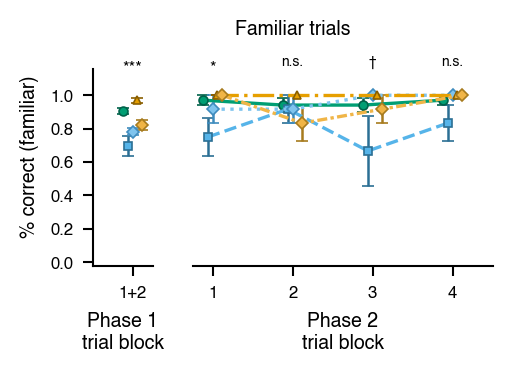

In [15]:
# Preview render: Panel 3B (familiar).
# Fixed rect instead of subplots+tight_layout: tight_layout ignores the extra
# axes the P1/Phase-2 split adds and would misalign the two panes.
fig = plt.figure(figsize=(2.5, 1.87 - 0.1))
ax = fig.add_axes([0.15, 0.24, 0.80, 0.62])
panel_accuracy(ax, route='familiar', include_p1=True,
                 split_p1=True, title='Familiar trials',
                 ylabel='% correct (familiar)', ylim=FIG3B_YLIM,
                 show_legend=False)
panel_b_block_marks(ax)   # per-position one-way-ANOVA marks
plt.show()

Familiar accuracy, median [Q1, Q3] across rats:
                   P1 (1+2)            block 1            block 2            block 3            block 4
group                                                                                                  
PI+VC     0.94 [0.88, 0.94]  1.00 [1.00, 1.00]  1.00 [1.00, 1.00]  1.00 [1.00, 1.00]  1.00 [1.00, 1.00]
PI_PI     0.72 [0.59, 0.80]  0.75 [0.50, 1.00]  1.00 [1.00, 1.00]  1.00 [0.25, 1.00]  1.00 [0.62, 1.00]
PI_PI+VC  0.75 [0.75, 0.80]  1.00 [1.00, 1.00]  1.00 [1.00, 1.00]  1.00 [1.00, 1.00]  1.00 [1.00, 1.00]
VC_VC     0.97 [0.94, 1.00]  1.00 [1.00, 1.00]  1.00 [1.00, 1.00]  1.00 [1.00, 1.00]  1.00 [1.00, 1.00]
VC_PI+VC  0.84 [0.81, 0.88]  1.00 [1.00, 1.00]  1.00 [0.62, 1.00]  1.00 [1.00, 1.00]  1.00 [1.00, 1.00]
marks, mean figure -> median figure: P1 *** -> ***, block 1 * -> *, block 2 n.s. -> n.s., block 3 † -> n.s., block 4 n.s. -> n.s.


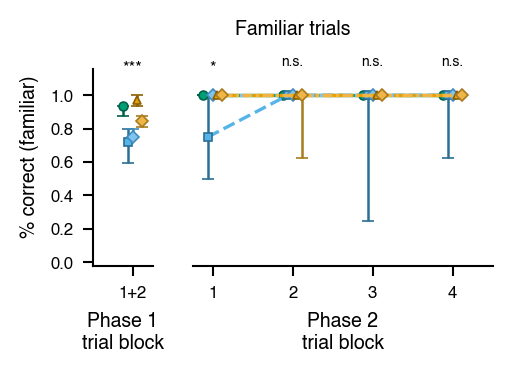

In [16]:
# Median variant of Panel 3B (median figure): group median across rats of the
# per-rat familiar accuracy, quartile bars (MEDIAN_ERR), marks read from the
# Kruskal-Wallis companion of each position's one-way ANOVA (MEDIAN_MARKS).
B_BLOCK_STATS_MED = median_marks(B_BLOCK_STATS)
print('Familiar accuracy, median [Q1, Q3] across rats:')
print(median_table(group_acc_med, route='familiar').to_string())
print('marks, mean figure -> median figure: ' + marks_summary(B_BLOCK_STATS, B_BLOCK_STATS_MED))
fig = plt.figure(figsize=(2.5, 1.87 - 0.1))
ax = fig.add_axes([0.15, 0.24, 0.80, 0.62])
panel_accuracy(ax, route='familiar', include_p1=True, group_acc=group_acc_med,
                 split_p1=True, title='Familiar trials',
                 ylabel='% correct (familiar)', ylim=FIG3B_YLIM,
                 show_legend=False)
panel_b_block_marks(ax, stats_by_block=B_BLOCK_STATS_MED)   # rank-based marks
plt.show()


## Statistics — Panel 3C Phase-2 novel accuracy (exploratory)

Assumption checks first (per-cell normality, mixed-model residuals,
Brown–Forsythe homogeneity per block, rank-transformed refit as the robustness
companion), then the 4 × 5 mixed ANOVA (block within, group between; afex, with
Mauchly's test and the `GG_RULE` decision printed by the helper) with Bonferroni post-hocs,
and a grouped contrast on block-averaged novel accuracy (knob
`C3_CONTRAST_GROUP`, default `VC_VC` — the dissociation group — vs the rest). The manuscript reports only descriptives for
Panel C; the tests here are exploratory and not cited in the manuscript text.

In [17]:
# Assumption checks + robustness for the Panel-3C 4x5 mixed ANOVA below.
# DV = per-rat novel accuracy per block (4 trials -> values k/4, floored at 0
# in block 1): per-cell normality fails largely by construction. Sphericity
# (Mauchly, afex) and the GG_RULE decision are printed by mixed_anova_afex in
# the tests cell. The rank-transformed refit of the same design is the
# robustness companion: conclusions should be read off it when checks fail.
p2_novel = rat_acc[(rat_acc['x_order'] >= 1) & (rat_acc['route'] == 'novel')].copy()
p2_novel['block'] = p2_novel['x_order'].astype(int)

print('=== Normality: Shapiro-Wilk per group x block cell ===')
_rej, _tot, _degen = 0, 0, 0
for (_g, _b), _v in p2_novel.groupby(['group', 'block'], observed=True)['correct']:
    _v = _v.to_numpy(float)
    if len(np.unique(_v)) < 2:
        _degen += 1
        continue
    _tot += 1
    _rej += stats.shapiro(_v).pvalue < .05
print(f'{_rej}/{_tot} testable cells reject at .05; {_degen} cell(s) with zero '
      f'variance (values are k/4 with floor/ceiling)')

_cellm = p2_novel.groupby(['group', 'block'], observed=True)['correct'].transform('mean')
_sww = stats.shapiro((p2_novel['correct'] - _cellm).to_numpy())
_submeans = p2_novel.groupby(['subject_id', 'group'], observed=True)['correct'].mean()
_swb = stats.shapiro(
    (_submeans - _submeans.groupby('group', observed=True).transform('mean')).to_numpy())
print(f'within-cell residuals: W = {_sww.statistic:.3f}, p = {_sww.pvalue:.4g}')
print(f'between-subject residuals: W = {_swb.statistic:.3f}, p = {_swb.pvalue:.4g}')

print('\n=== Homogeneity across groups per block: Brown-Forsythe ===')
for _b in sorted(p2_novel['block'].unique()):
    _vals = [p2_novel[(p2_novel['group'] == _g) & (p2_novel['block'] == _b)]
             ['correct'].to_numpy(float) for _g in GROUP_ORDER]
    _lv = stats.levene(*_vals, center='median')
    print(f'block {_b}: W = {_lv.statistic:.3f}, p = {_lv.pvalue:.4g}')

print('\n=== Robustness: rank-transformed 4x5 mixed ANOVA ===')
_aovr = mixed_anova_afex(p2_novel.assign(rank=p2_novel['correct'].rank()), 'rank',
                         label='3C novel accuracy [rank refit]')

=== Normality: Shapiro-Wilk per group x block cell ===
13/19 testable cells reject at .05; 1 cell(s) with zero variance (values are k/4 with floor/ceiling)
within-cell residuals: W = 0.961, p = 0.0001497
between-subject residuals: W = 0.957, p = 0.1192

=== Homogeneity across groups per block: Brown-Forsythe ===
block 1: W = 0.761, p = 0.5575
block 2: W = 0.439, p = 0.7797
block 3: W = 0.580, p = 0.6793
block 4: W = 0.660, p = 0.6237

=== Robustness: rank-transformed 4x5 mixed ANOVA ===


R callback write-console: Contrasts set to contr.sum for the following variables: group
  


=== 3C novel accuracy [rank refit]: 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.709, p = 0.03602 -> sphericity violated; GG eps = 0.858, HF eps = 0.930
     Source     F df (unc)   p (unc)     df (GG)    p (GG)   np2
      group  3.40    4, 36   0.01843           -         - 0.274
      block 36.48   3, 108 2.325e-16  2.57, 92.7 2.311e-14 0.503
Interaction  4.10  12, 108 2.881e-05 10.30, 92.7 9.237e-05 0.313
Reported (GG_RULE = 'mauchly' -> GG df): group F(4, 36) = 3.40, p = .018; block F(2.57, 92.7) = 36.48, p < .001; block × group F(10.30, 92.7) = 4.10, p < .001


In [18]:
# Uses p2_novel (and HAS_PG / `stats`) from the assumptions cell above.
# Per-rat block-averaged novel accuracy (all 16 novel trials).
avg = p2_novel.groupby(['subject_id', 'group'], observed=True)['correct'].mean().reset_index()

# Exploratory (not cited): 4x5 mixed ANOVA via afex; Mauchly rejects (W = .68, p = .021),
# so the reported within terms carry GG df under GG_RULE = 'mauchly'.
aov = mixed_anova_afex(p2_novel, 'correct', label='3C novel accuracy')
if HAS_PG:
    print('\n=== Bonferroni post-hocs: VC_VC vs other groups (avg over blocks) ===')
    ph = pg.pairwise_tests(data=avg, dv='correct', between='group', padjust='bonf')
    print(ph[ph['A'].eq('VC_VC') | ph['B'].eq('VC_VC')].to_string(index=False))
else:
    print('pingouin not installed; skipping the Bonferroni post-hocs.')

# Grouped contrast on block-averaged novel accuracy: VC_VC (the manuscript's
# dissociation group - the only one that never acquires the novel route) vs
# the other four groups. Knob: set to any other group name to flip the target.
C3_CONTRAST_GROUP = 'VC_VC'
_gm = avg.groupby('group', observed=True)['correct'].agg(['mean', 'count'])
_dfe = len(avg) - len(_gm)
_mse = sum(((v['correct'] - v['correct'].mean()) ** 2).sum()
           for _, v in avg.groupby('group', observed=True)) / _dfe
_others = [g for g in _gm.index if g != C3_CONTRAST_GROUP]
_w = {C3_CONTRAST_GROUP: 1.0, **{g: -1 / len(_others) for g in _others}}
_psi = sum(wi * _gm.loc[g, 'mean'] for g, wi in _w.items())
_F = _psi ** 2 / (_mse * sum(wi ** 2 / _gm.loc[g, 'count'] for g, wi in _w.items()))
_a = avg.loc[avg['group'] == C3_CONTRAST_GROUP, 'correct'].to_numpy(float)
_b = avg.loc[avg['group'] != C3_CONTRAST_GROUP, 'correct'].to_numpy(float)
_tw = stats.ttest_ind(_a, _b, equal_var=False)
_mw = stats.mannwhitneyu(_a, _b, alternative='two-sided')
_km1 = len(_gm) - 1
print(f'\n=== Grouped contrast: {C3_CONTRAST_GROUP} ({_a.mean() * 100:.1f}%) vs rest '
      f'({_b.mean() * 100:.1f}%), block-averaged novel accuracy ===')
print(f'pooled: F(1,{_dfe}) = {_F:.2f}, p = {stats.f.sf(_F, 1, _dfe):.3g}; '
      f'Scheffé p = {stats.f.sf(_F / _km1, _km1, _dfe):.3g}')
print(f'Welch: t({_tw.df:.1f}) = {_tw.statistic:.2f}, p = {_tw.pvalue:.3g}; '
      f'Mann-Whitney U = {_mw.statistic:.0f}, p = {_mw.pvalue:.3g}')

R callback write-console: Contrasts set to contr.sum for the following variables: group
  


=== 3C novel accuracy: 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.683, p = 0.02124 -> sphericity violated; GG eps = 0.848, HF eps = 0.917
     Source     F df (unc)   p (unc)     df (GG)    p (GG)   np2
      group  3.30    4, 36   0.02104           -         - 0.268
      block 37.97   3, 108 7.815e-17  2.54, 91.5 1.281e-14 0.513
Interaction  3.66  12, 108 0.0001295 10.17, 91.5  0.000365 0.289
Reported (GG_RULE = 'mauchly' -> GG df): group F(4, 36) = 3.30, p = .021; block F(2.54, 91.5) = 37.97, p < .001; block × group F(10.17, 91.5) = 3.66, p < .001

=== Bonferroni post-hocs: VC_VC vs other groups (avg over blocks) ===
Contrast        A     B  Paired  Parametric        T       dof alternative    p_unc   p_corr p_adjust   BF10   hedges
   group    PI+VC VC_VC   False        True 3.373552  9.611679   two-sided 0.007481 0.074812     bonf 12.613 1.474050
   group    PI_PI VC_VC   False        True 1.877937 10.000000   t

## Panel 3C — novel-route accuracy (per-block marks + preview)

One row of per-block significance marks above the blocks (`***`/`**`/`*`/`†`/
`n.s.`, pooled-F VC_VC-vs-rest within each block, as in Panels D/E). Block 1
is two-sided: VC_VC is numerically the HIGHEST group there.

In [19]:
# Per-block VC_VC-vs-rest grouped contrasts on novel-route accuracy -> the
# Panel-C per-block marks. Pooled F(1,36) drives the mark, as in Panels D/E
# (Mann-Whitney agrees; Welch dips to '*' at block 4 where its df collapses).
# Two-sided: at block 1 VC_VC is numerically the highest group.
C_BLOCK_STATS = {}
print('Per-block VC_VC vs rest on novel accuracy (pooled F / Welch / Mann-Whitney):')
for _b in sorted(p2_novel['block'].unique()):
    _d = p2_novel[p2_novel['block'] == _b].dropna(subset=['correct'])
    _vcb = _d.loc[_d['group'] == 'VC_VC', 'correct'].to_numpy(float)
    _restb = _d.loc[_d['group'] != 'VC_VC', 'correct'].to_numpy(float)
    _gm = _d.groupby('group', observed=True)['correct'].agg(['mean', 'count'])
    _dfe = len(_d) - len(_gm)
    _mse = sum(((v['correct'] - v['correct'].mean()) ** 2).sum()
               for _, v in _d.groupby('group', observed=True)) / _dfe
    _others = [g for g in _gm.index if g != 'VC_VC']
    _w = {'VC_VC': 1.0, **{g: -1 / len(_others) for g in _others}}
    _psi = sum(wi * _gm.loc[g, 'mean'] for g, wi in _w.items())
    _Fb = _psi ** 2 / (_mse * sum(wi ** 2 / _gm.loc[g, 'count'] for g, wi in _w.items()))
    _pp = float(stats.f.sf(_Fb, 1, _dfe))
    _tw = stats.ttest_ind(_vcb, _restb, equal_var=False)
    _mw = stats.mannwhitneyu(_vcb, _restb, alternative='two-sided')
    C_BLOCK_STATS[int(_b)] = {'F': float(_Fb), 'dfe': int(_dfe), 'p': _pp,
                              'p_welch': float(_tw.pvalue), 'p_mwu': float(_mw.pvalue),
                              'mark': p_to_marks(_pp),
                              'mean_vc': float(_vcb.mean()), 'mean_rest': float(_restb.mean())}
    _s = C_BLOCK_STATS[int(_b)]
    print(f"  block {int(_b)}: VC_VC {_s['mean_vc']:.2f} vs rest {_s['mean_rest']:.2f} | "
          f"F(1,{_s['dfe']}) = {_s['F']:.2f}, p = {_s['p']:.4g} -> '{_s['mark']}' | "
          f"Welch p = {_s['p_welch']:.4g} | MW p = {_s['p_mwu']:.4g}")


# ============================================================================
# Fig 3C per-block mark knobs (one marks row above the blocks, like D-H)
# ============================================================================
FIG3C_MARK_Y = None              # fixed data-y override (None = MARK_FRAC row)
FIG3C_MARK_FONTSIZE = STYLE_CFG['star_fontsize']
FIG3C_MARK_NS_FONTSIZE = 5
FIG3C_YLIM = ylim_for(-0.025, 1.0)   # top tick 1.0 at TOP_TICK_FRAC (uniform)


def panel_c_block_marks(ax, *, stats_by_block=None, y=None, ylim=None):
    """One row of per-block significance marks (C_BLOCK_STATS: pooled-F
    VC_VC-vs-rest novel accuracy within each block) at MARK_FRAC of the axes
    height (uniform across panels; override with `y` / FIG3C_MARK_Y)."""
    sb = C_BLOCK_STATS if stats_by_block is None else stats_by_block
    y_fix = FIG3C_MARK_Y if y is None else y
    _ylim = FIG3C_YLIM if ylim is None else ylim   # the median figure passes its own scale
    y_row = mark_row_y(*_ylim) if y_fix is None else y_fix
    for b, s in sb.items():
        is_star = s['mark'] not in ('n.s.', '\u2020')
        draw_mark(ax, b, y_row, s['mark'],
                  FIG3C_MARK_FONTSIZE if is_star else FIG3C_MARK_NS_FONTSIZE)
    trim_left_spine(ax, _ylim)
    return ax

Per-block VC_VC vs rest on novel accuracy (pooled F / Welch / Mann-Whitney):
  block 1: VC_VC 0.29 vs rest 0.16 | F(1,36) = 1.62, p = 0.2113 -> 'n.s.' | Welch p = 0.1791 | MW p = 0.08252


  block 2: VC_VC 0.12 vs rest 0.58 | F(1,36) = 5.41, p = 0.02576 -> '*' | Welch p = 0.0123 | MW p = 0.01442
  block 3: VC_VC 0.17 vs rest 0.76 | F(1,36) = 14.41, p = 0.0005441 -> '***' | Welch p = 0.0001133 | MW p = 0.001027
  block 4: VC_VC 0.25 vs rest 0.85 | F(1,36) = 15.35, p = 0.0003827 -> '***' | Welch p = 0.01521 | MW p = 0.000912


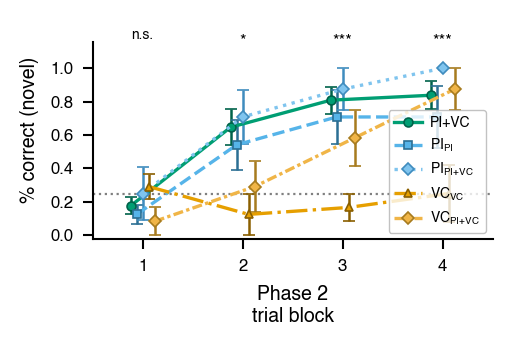

In [20]:
# Preview render: Panel 3C (novel). Standalone preview keeps the composed-figure
# kwargs except that it shows its own y-label (in the figure it shares B's axis).
fig = plt.figure(figsize=(2.5, 1.87 - 0.1))
ax = fig.add_axes([0.17, 0.24, 0.80, 0.62])
panel_accuracy(ax, route='novel', include_p1=False,
                 xlabel='Phase 2\ntrial block',
                 ylabel='% correct (novel)',
                 show_chance=True, chance_y=0.25, ylim=FIG3C_YLIM,
                 show_legend=True, legend_loc='lower right')
panel_c_block_marks(ax)   # per-block VC_VC-vs-rest marks
plt.show()

Novel accuracy, median [Q1, Q3] across rats:
                    block 1            block 2            block 3            block 4
group                                                                               
PI+VC     0.25 [0.00, 0.25]  1.00 [0.25, 1.00]  1.00 [0.75, 1.00]  1.00 [1.00, 1.00]
PI_PI     0.12 [0.00, 0.25]  0.62 [0.31, 0.75]  0.88 [0.56, 1.00]  1.00 [0.44, 1.00]
PI_PI+VC  0.12 [0.00, 0.25]  0.88 [0.56, 1.00]  1.00 [1.00, 1.00]  1.00 [1.00, 1.00]
VC_VC     0.25 [0.25, 0.44]  0.00 [0.00, 0.00]  0.12 [0.00, 0.25]  0.00 [0.00, 0.38]
VC_PI+VC  0.00 [0.00, 0.00]  0.12 [0.00, 0.62]  0.62 [0.31, 0.94]  1.00 [1.00, 1.00]
marks, mean figure -> median figure: block 1 n.s. -> †, block 2 * -> *, block 3 *** -> **, block 4 *** -> ***


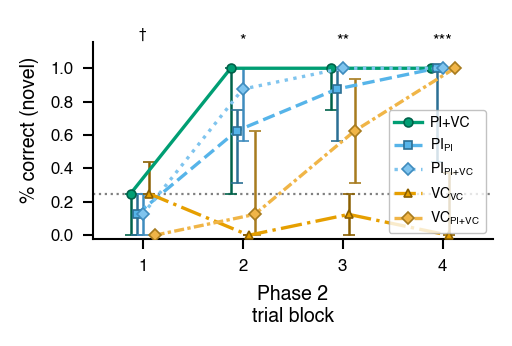

In [21]:
# Median variant of Panel 3C (median figure): median novel accuracy across
# rats, quartile bars, marks from the Mann-Whitney companion of the per-block
# VC_VC-vs-rest contrast.
C_BLOCK_STATS_MED = median_marks(C_BLOCK_STATS)
print('Novel accuracy, median [Q1, Q3] across rats:')
print(median_table(group_acc_med, route='novel').to_string())
print('marks, mean figure -> median figure: ' + marks_summary(C_BLOCK_STATS, C_BLOCK_STATS_MED))
fig = plt.figure(figsize=(2.5, 1.87 - 0.1))
ax = fig.add_axes([0.17, 0.24, 0.80, 0.62])
panel_accuracy(ax, route='novel', include_p1=False, group_acc=group_acc_med,
                 xlabel='Phase 2\ntrial block',
                 ylabel='% correct (novel)',
                 show_chance=True, chance_y=0.25, ylim=FIG3C_YLIM,
                 show_legend=True, legend_loc='lower right')
panel_c_block_marks(ax, stats_by_block=C_BLOCK_STATS_MED)   # rank-based marks
plt.show()


## Statistics — Panel 3D Novel − Familiar difference (manuscript tests)

Assumption checks first (per-cell normality, mixed-model residuals,
Brown–Forsythe homogeneity per block, rank-transformed refit as the robustness
companion), then the manuscript's 4 × 5 mixed ANOVA on the per-block
novel − familiar difference (afex Type 3: block F(3, 108) = 30.69, group
F(4, 36) = 6.50, block × group F(12, 108) = 3.15, all p < .001; Mauchly does not
reject, so the df stay uncorrected under `GG_RULE = 'mauchly'`), and a
grouped contrast on the block-averaged difference (knob `C3D_CONTRAST_GROUP`,
default `VC_VC` vs the rest).

In [22]:
# Assumption checks + robustness for the Panel-3D 4x5 mixed ANOVA below.
# DV = per-rat (novel - familiar) accuracy per block: novel is k/4 and
# familiar k/2, so the difference lives on a coarse grid and per-cell
# normality fails largely by construction. Sphericity (Mauchly, afex) and the
# GG_RULE decision are printed by mixed_anova_afex in the tests cell. The
# rank-transformed refit of the same design is the robustness companion.
def per_rat_diff(rat_acc: pd.DataFrame) -> pd.DataFrame:
    '''Return per-rat × block: novel - familiar.'''
    p2 = rat_acc[rat_acc['x_order'] >= 1].copy()
    wide = p2.pivot_table(
        index=['subject_id', 'group', 'x_order'],
        columns='route', values='correct',
    ).reset_index()
    wide['diff'] = wide['novel'] - wide['familiar']
    return wide

rat_diff = per_rat_diff(rat_acc)
rat_diff['block'] = rat_diff['x_order'].astype(int)
grp_diff = (
    rat_diff.groupby(['group', 'x_order'], observed=True)['diff']
    .agg(['mean', 'sem', 'count']).reset_index()
    .rename(columns={'count': 'n'})
)

print('=== Normality: Shapiro-Wilk per group x block cell ===')
_rej, _tot, _degen = 0, 0, 0
for (_g, _b), _v in rat_diff.groupby(['group', 'block'], observed=True)['diff']:
    _v = _v.to_numpy(float)
    if len(np.unique(_v)) < 2:
        _degen += 1
        continue
    _tot += 1
    _rej += stats.shapiro(_v).pvalue < .05
print(f'{_rej}/{_tot} testable cells reject at .05; {_degen} cell(s) with zero '
      f'variance (novel k/4 minus familiar k/2 -> coarse grid)')

_cellm = rat_diff.groupby(['group', 'block'], observed=True)['diff'].transform('mean')
_sww = stats.shapiro((rat_diff['diff'] - _cellm).to_numpy())
_submeans = rat_diff.groupby(['subject_id', 'group'], observed=True)['diff'].mean()
_swb = stats.shapiro(
    (_submeans - _submeans.groupby('group', observed=True).transform('mean')).to_numpy())
print(f'within-cell residuals: W = {_sww.statistic:.3f}, p = {_sww.pvalue:.4g}')
print(f'between-subject residuals: W = {_swb.statistic:.3f}, p = {_swb.pvalue:.4g}')

print('\n=== Homogeneity across groups per block: Brown-Forsythe ===')
for _b in sorted(rat_diff['block'].unique()):
    _vals = [rat_diff[(rat_diff['group'] == _g) & (rat_diff['block'] == _b)]
             ['diff'].to_numpy(float) for _g in GROUP_ORDER]
    _lv = stats.levene(*_vals, center='median')
    print(f'block {_b}: W = {_lv.statistic:.3f}, p = {_lv.pvalue:.4g}')

print('\n=== Robustness: rank-transformed 4x5 mixed ANOVA ===')
_aovr = mixed_anova_afex(rat_diff.assign(rank=rat_diff['diff'].rank()), 'rank',
                         label='3D novel − familiar accuracy [rank refit]')

=== Normality: Shapiro-Wilk per group x block cell ===
12/19 testable cells reject at .05; 1 cell(s) with zero variance (novel k/4 minus familiar k/2 -> coarse grid)


R callback write-console: Contrasts set to contr.sum for the following variables: group
  


R callback write-console: In addition:   


R callback write-console: Warning message:
  


R callback write-console: In summary.Anova.mlm(object$Anova, multivariate = FALSE) :  


R callback write-console: 
   


R callback write-console:  HF eps > 1 treated as 1
  


within-cell residuals: W = 0.961, p = 0.0001432
between-subject residuals: W = 0.953, p = 0.09095

=== Homogeneity across groups per block: Brown-Forsythe ===
block 1: W = 1.634, p = 0.187
block 2: W = 0.543, p = 0.7053
block 3: W = 0.768, p = 0.5534
block 4: W = 0.599, p = 0.666

=== Robustness: rank-transformed 4x5 mixed ANOVA ===


=== 3D novel − familiar accuracy [rank refit]: 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.881, p = 0.4936 -> sphericity not rejected; GG eps = 0.927, HF eps = 1.012
     Source     F df (unc)   p (unc)      df (GG)    p (GG)   np2
      group  6.71    4, 36 0.0003837            -         - 0.427
      block 33.02   3, 108  3.18e-15  2.78, 100.1 2.832e-14 0.478
Interaction  3.48  12, 108 0.0002349 11.12, 100.1 0.0003711 0.279
Reported (GG_RULE = 'mauchly' -> uncorrected df): group F(4, 36) = 6.71, p < .001; block F(3, 108) = 33.02, p < .001; block × group F(12, 108) = 3.48, p < .001


In [23]:
# Uses rat_diff (and HAS_PG / `stats`) from the assumptions cell above.
# Manuscript test (Results, Panel D), afex Type 3: block F(3, 108) = 30.69, group
# F(4, 36) = 6.50, block x group F(12, 108) = 3.15 (all p < .001). Mauchly does not
# reject (W = .81, p = .20), so the df stay uncorrected under GG_RULE = 'mauchly'.
# (pingouin's weighted-means version of the block term is F = 43.14; group and
# interaction F are identical in both.)
aov_d = mixed_anova_afex(rat_diff, 'diff', label='3D novel − familiar accuracy')

# Grouped contrast on the block-averaged difference: VC_VC (improves least;
# the bracket group) vs the other four groups. Knob: set to any other group
# name to flip the target.
C3D_CONTRAST_GROUP = 'VC_VC'
avg_d = rat_diff.groupby(['subject_id', 'group'], observed=True)['diff'].mean().reset_index()
_gm = avg_d.groupby('group', observed=True)['diff'].agg(['mean', 'count'])
_dfe = len(avg_d) - len(_gm)
_mse = sum(((v['diff'] - v['diff'].mean()) ** 2).sum()
           for _, v in avg_d.groupby('group', observed=True)) / _dfe
_others = [g for g in _gm.index if g != C3D_CONTRAST_GROUP]
_w = {C3D_CONTRAST_GROUP: 1.0, **{g: -1 / len(_others) for g in _others}}
_psi = sum(wi * _gm.loc[g, 'mean'] for g, wi in _w.items())
_F = _psi ** 2 / (_mse * sum(wi ** 2 / _gm.loc[g, 'count'] for g, wi in _w.items()))
_a = avg_d.loc[avg_d['group'] == C3D_CONTRAST_GROUP, 'diff'].to_numpy(float)
_b = avg_d.loc[avg_d['group'] != C3D_CONTRAST_GROUP, 'diff'].to_numpy(float)
_tw = stats.ttest_ind(_a, _b, equal_var=False)
_mw = stats.mannwhitneyu(_a, _b, alternative='two-sided')
_km1 = len(_gm) - 1
print(f'\n=== Grouped contrast: {C3D_CONTRAST_GROUP} ({_a.mean():+.3f}) vs rest '
      f'({_b.mean():+.3f}), block-averaged novel − familiar ===')
print(f'pooled: F(1,{_dfe}) = {_F:.2f}, p = {stats.f.sf(_F, 1, _dfe):.3g}; '
      f'Scheffé p = {stats.f.sf(_F / _km1, _km1, _dfe):.3g}')
print(f'Welch: t({_tw.df:.1f}) = {_tw.statistic:.2f}, p = {_tw.pvalue:.3g}; '
      f'Mann-Whitney U = {_mw.statistic:.0f}, p = {_mw.pvalue:.3g}')

R callback write-console: Contrasts set to contr.sum for the following variables: group
  


=== 3D novel − familiar accuracy: 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.809, p = 0.1952 -> sphericity not rejected; GG eps = 0.880, HF eps = 0.956
     Source     F df (unc)   p (unc)     df (GG)    p (GG)   np2
      group  6.50    4, 36 0.0004834           -         - 0.419
      block 30.69   3, 108 1.988e-14  2.64, 95.0 5.799e-13 0.460
Interaction  3.15  12, 108 0.0007057 10.55, 95.0  0.001324 0.259
Reported (GG_RULE = 'mauchly' -> uncorrected df): group F(4, 36) = 6.50, p < .001; block F(3, 108) = 30.69, p < .001; block × group F(12, 108) = 3.15, p < .001

=== Grouped contrast: VC_VC (-0.792) vs rest (-0.336), block-averaged novel − familiar ===
pooled: F(1,36) = 21.41, p = 4.66e-05; Scheffé p = 0.00173
Welch: t(6.4) = -4.22, p = 0.00485; Mann-Whitney U = 20, p = 0.00163


## Panel 3D — Novel − Familiar difference per Phase-2 block

Negative values = worse on novel than familiar. Errorbars = SEM of the per-rat paired
difference (`novel − familiar` within each rat × block).


The comparison bracket (slope-ANOVA star) is replaced by one row
of per-block significance marks above the blocks (`***`/`**`/`*`/`†`/`n.s.`,
pooled-F VC_VC-vs-rest within each block, as in Panels C/E); the bracket code
and knobs remain for reverting.

In [24]:
# Uses rat_diff / grp_diff from the Panel-3D statistics section above.
# Per-rat slope of (Novel - Familiar) improvement across Phase-2 blocks, then a
# one-way ANOVA across groups (retained for reference; the manuscript cites the
# 4x5 mixed ANOVA computed above instead). The bracket and its slope-ANOVA star
# are superseded by the per-block VC_VC-vs-rest marks
# (D_BLOCK_STATS below, drawn by panel_d_block_marks); revert with
# show_bracket=True + the FIG3D_* bracket knobs.
def _rat_slope(g):
    g = g.dropna(subset=['diff'])
    if g['x_order'].nunique() < 2:
        return np.nan
    return np.polyfit(g['x_order'], g['diff'], 1)[0]

rat_slope = (rat_diff.groupby(['subject_id', 'group'], observed=True)
             .apply(_rat_slope, include_groups=False)
             .reset_index(name='slope').dropna(subset=['slope']))

# p_to_stars / p_to_marks / draw_mark now live in the shared
# route-accuracy plotting cell (they are also used by Panel C).

try:
    import pingouin as pg
    _aov = pg.anova(data=rat_slope, dv='slope', between='group')
    _F, _p = float(_aov['F'].iloc[0]), float(_aov['p_unc'].iloc[0])
    _df1, _df2 = int(_aov['ddof1'].iloc[0]), int(_aov['ddof2'].iloc[0])
    _ph = pg.pairwise_tests(data=rat_slope, dv='slope', between='group',
                            padjust='bonf')
    _ph = _ph[(_ph['A'] == 'VC_VC') | (_ph['B'] == 'VC_VC')]
except ImportError:
    from scipy import stats as _stats
    _grps = [d['slope'].values for _, d in rat_slope.groupby('group', observed=True)]
    _F, _p = _stats.f_oneway(*_grps)
    _df1, _df2 = len(_grps) - 1, len(rat_slope) - len(_grps)
    _ph = None

SLOPE_STATS = {'F': _F, 'p': _p, 'df1': _df1, 'df2': _df2, 'star': p_to_stars(_p)}
print(f"Fig 3D slope one-way ANOVA: F({_df1},{_df2}) = {_F:.2f}, p = {_p:.4g} "
      f"-> bracket '{SLOPE_STATS['star']}'")
if _ph is not None:
    print('VC_VC vs other groups (Bonferroni):')
    print(_ph[['A', 'B', 'T', 'dof', 'p_unc', 'p_corr']].to_string(index=False))



# Per-block VC_VC-vs-rest grouped contrasts on the novel - familiar difference
# -> the Panel-D per-block marks. Pooled F(1,36) drives the mark, as in Panel
# E (Mann-Whitney agrees at every block; Welch dips to '*' at block 4 where
# its df collapses to ~6).
D_BLOCK_STATS = {}
print('\nPer-block VC_VC vs rest on novel - familiar (pooled F / Welch / Mann-Whitney):')
for _b in sorted(rat_diff['block'].unique()):
    _d = rat_diff[rat_diff['block'] == _b].dropna(subset=['diff'])
    _vcb = _d.loc[_d['group'] == 'VC_VC', 'diff'].to_numpy(float)
    _restb = _d.loc[_d['group'] != 'VC_VC', 'diff'].to_numpy(float)
    _gm = _d.groupby('group', observed=True)['diff'].agg(['mean', 'count'])
    _dfe = len(_d) - len(_gm)
    _mse = sum(((v['diff'] - v['diff'].mean()) ** 2).sum()
               for _, v in _d.groupby('group', observed=True)) / _dfe
    _others = [g for g in _gm.index if g != 'VC_VC']
    _w = {'VC_VC': 1.0, **{g: -1 / len(_others) for g in _others}}
    _psi = sum(wi * _gm.loc[g, 'mean'] for g, wi in _w.items())
    _Fb = _psi ** 2 / (_mse * sum(wi ** 2 / _gm.loc[g, 'count'] for g, wi in _w.items()))
    _pp = float(stats.f.sf(_Fb, 1, _dfe))
    _tw = stats.ttest_ind(_vcb, _restb, equal_var=False)
    _mw = stats.mannwhitneyu(_vcb, _restb, alternative='two-sided')
    D_BLOCK_STATS[int(_b)] = {'F': float(_Fb), 'dfe': int(_dfe), 'p': _pp,
                              'p_welch': float(_tw.pvalue), 'p_mwu': float(_mw.pvalue),
                              'mark': p_to_marks(_pp),
                              'mean_vc': float(_vcb.mean()), 'mean_rest': float(_restb.mean())}
    _s = D_BLOCK_STATS[int(_b)]
    print(f"  block {int(_b)}: VC_VC {_s['mean_vc']:+.2f} vs rest {_s['mean_rest']:+.2f} | "
          f"F(1,{_s['dfe']}) = {_s['F']:.2f}, p = {_s['p']:.4g} -> '{_s['mark']}' | "
          f"Welch p = {_s['p_welch']:.4g} | MW p = {_s['p_mwu']:.4g}")


def fmt_no_lead_zero(y, decimals=2):
    """Tick label without the ones-place zero: -0.75 -> '\u2212.75', -1.0 -> '\u22121.00';
    exact zero -> '0'. Honours axes.unicode_minus like matplotlib's default formatter."""
    if abs(y) < 1e-9:
        return '0'
    s = f'{abs(y):.{decimals}f}'
    if s.startswith('0.'):
        s = s[1:]
    minus = '\u2212' if plt.rcParams['axes.unicode_minus'] else '-'
    return (minus if y < 0 else '') + s


def panel_d_difference(ax, *, grp_diff=grp_diff,
                       line_lw=1.2,
                       marker_size=STYLE_CFG['marker_size'],
                       marker_edge_lw=STYLE_CFG['marker_edge_lw_d'],
                       err_lw=STYLE_CFG['err_lw'],
                       cap_size=STYLE_CFG['cap_size'],
                       group_offset=0.06,
                       ylim=None,   # None -> FIG3D_YLIM (marks headroom)
                       yticks=(-1.0, -0.75, -0.5, -0.25, 0.0),
                       ytick_fmt=fmt_no_lead_zero,  # callable y -> label; None = matplotlib default
                       ylabel='Novel − familiar',
                       ylabel_pad=-0.5,  # pt (matplotlib default 4). Negative so the label sits ~4.8 pt from the −.75/−.50/−.25 numbers, matching Panel B, instead of from the wider −1.00 (whose row the label does not reach)
                       xlabel='Phase 2\ntrial block',
                       show_bracket=False, bracket_group='VC_VC',
                       bracket_star=None, bracket_x_pad=0.42,
                       bracket_cap=0.12, bracket_lw=0.8,
                       bracket_star_dx=0.24,
                       main_bar_len=None, little_bar_len=None,
                       bracket_y_offset=0.0,
                       little_bar_dx=0.0, little_bar_dy=0.0,
                       star_fontsize=STYLE_CFG['star_fontsize'],
                       show_legend=False):
    if ylim is None:
        ylim = FIG3D_YLIM
    x_orders = sorted(grp_diff['x_order'].unique())
    n_groups = len(GROUP_ORDER)
    for i, group in enumerate(GROUP_ORDER):
        g_sub = grp_diff[grp_diff['group'] == group].sort_values('x_order')
        if g_sub.empty:
            continue
        style = STYLE[group]
        offset = (i - (n_groups - 1) / 2) * group_offset
        xs = g_sub['x_order'].values.astype(float) + offset
        means = g_sub['mean'].values
        sems = g_sub['sem'].fillna(0).values
        # Median aggregates carry err_lo/err_hi (quartile distances) ->
        # asymmetric bars; mean aggregates have neither -> symmetric ± sem.
        yerr = ([g_sub['err_lo'].fillna(0).values, g_sub['err_hi'].fillna(0).values]
                if {'err_lo', 'err_hi'} <= set(g_sub.columns) else sems)
        ax.errorbar(
            xs, means, yerr=yerr,
            fmt=style['marker'], ls=style['line'],
            color=style['base'],
            markerfacecolor=style['base'],
            markeredgecolor=style['edge'],
            markeredgewidth=marker_edge_lw,
            markersize=marker_size, lw=line_lw,
            ecolor=style['edge'], elinewidth=err_lw,
            capsize=cap_size, capthick=err_lw,
            label=group_label(group), zorder=3,
        )
    ax.set_xticks(x_orders)
    ax.set_xticklabels([str(int(x)) for x in x_orders])
    ax.set_xlim(x_orders[0] - 0.5,
                x_orders[-1] + (0.85 if show_bracket else 0.5))
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)
    if ytick_fmt is not None:
        ax.set_yticklabels([ytick_fmt(y) for y in yticks])
    ax.set_ylabel(ylabel, labelpad=ylabel_pad)
    ax.set_xlabel(xlabel)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)

    # Comparison bracket marking VC_VC (improves least) vs the top group.
    # A little vertical bar near the data spans the top-group cluster
    # (best..worst of the other groups at the last block); a top cap joins it
    # to the main spine at the right edge, which drops to VC_VC with a bottom
    # cap. Star = per-rat slope one-way ANOVA (SLOPE_STATS).
    if show_bracket:
        b4 = (grp_diff[grp_diff['x_order'] == max(x_orders)]
              .set_index('group')['mean'])
        others = [g for g in GROUP_ORDER
                  if g != bracket_group and g in list(b4.index)]
        y_lo = float(b4.reindex([bracket_group]).iloc[0])   # VC_VC (bottom)
        ov = b4.reindex(others)
        y_top = float(ov.max())       # top cap level (top of the top cluster)
        y_hi_bot = float(ov.min())    # bottom of the top-group cluster
        # Both bars hang DOWN from the top cap (y_top). Their vertical extents
        # default to the data — main spine reaches VC_VC, little bar spans the
        # top-cluster spread — but `main_bar_len` / `little_bar_len` (y-axis
        # units) override the sizes independently.
        main_len = (y_top - y_lo) if main_bar_len is None else main_bar_len
        little_len = (y_top - y_hi_bot) if little_bar_len is None else little_bar_len
        y_main_bot = y_top - main_len
        # slide the whole bracket (both bars, caps, star) up (+) / down (-)
        y_top += bracket_y_offset
        y_main_bot += bracket_y_offset
        xb = max(x_orders) + bracket_x_pad                  # main spine (right)
        xc = xb - bracket_cap                               # bottom cap / little-bar home
        # little bar (marks the top-group cluster). Move it with little_bar_dx
        # (+ = right) and little_bar_dy (+ = up); the top cap stretches to reach
        # it and a short connector keeps it joined when moved vertically.
        x_little = xc + little_bar_dx
        yl_top = y_top + little_bar_dy
        yl_bot = yl_top - little_len
        ax.plot([x_little, xb], [y_top, y_top], color='0.15', lw=bracket_lw,
                solid_capstyle='butt', zorder=4, clip_on=False)   # top cap
        ax.plot([x_little, x_little], [yl_bot, yl_top], color='0.15', lw=bracket_lw,
                solid_capstyle='butt', zorder=4, clip_on=False)   # little bar
        if abs(yl_top - y_top) > 1e-9:
            ax.plot([x_little, x_little], [y_top, yl_top], color='0.15',
                    lw=bracket_lw, solid_capstyle='butt', zorder=4,
                    clip_on=False)                                 # dy connector
        ax.plot([xb, xb], [y_main_bot, y_top], color='0.15', lw=bracket_lw,
                solid_capstyle='butt', zorder=4, clip_on=False)   # main spine
        ax.plot([xc, xb], [y_main_bot, y_main_bot], color='0.15', lw=bracket_lw,
                solid_capstyle='butt', zorder=4, clip_on=False)   # bottom cap
        star = bracket_star if bracket_star is not None else SLOPE_STATS['star']
        ax.text(xb + bracket_star_dx, (y_top + y_main_bot) / 2, star, rotation=90,
                ha='center', va='center', fontsize=star_fontsize,
                zorder=4, clip_on=False)

    if show_legend:
        ax.legend(loc='lower right', frameon=False,
                  fontsize=plt.rcParams['legend.fontsize'])
    return ax


# ============================================================================
# Fig 3D significance-bracket size knobs  (edit these to resize the two bars)
# Units = y-axis (novel-familiar) units.  None = auto-fit to the data:
#   main bar   -> top group down to VC_VC          (auto ~ 0.75)
#   little bar -> the top-group cluster spread      (auto ~ 0.13)
# Both bars hang from the top cap, so a larger number drops the bottom lower;
# the *** recenters on the main bar automatically.  e.g. set MAIN=0.6, LITTLE=0.10.
# ============================================================================
FIG3D_MAIN_BAR_LEN = 0.65
FIG3D_LITTLE_BAR_LEN = 0.3
FIG3D_BAR_YOFFSET = -0.11        # slide the whole bracket up (+) / down (-)
FIG3D_LITTLE_BAR_DX = 0.0      # move the little bar left (-) / right (+)
FIG3D_LITTLE_BAR_DY = 0.15      # move the little bar down (-) / up (+)


# ============================================================================
# Fig 3D per-block mark knobs (one marks row above the blocks, like Panels
# C/E; the marks supersede the bracket)
# ============================================================================
FIG3D_MARK_Y = None              # fixed data-y override (None = MARK_FRAC row)
FIG3D_MARK_FONTSIZE = STYLE_CFG['star_fontsize']
FIG3D_MARK_NS_FONTSIZE = 5
FIG3D_YLIM = ylim_for(-1.05, 0.0)    # top tick 0.0 at TOP_TICK_FRAC (uniform)


def panel_d_block_marks(ax, *, stats_by_block=None, y=None, ylim=None):
    """One row of per-block significance marks (D_BLOCK_STATS: pooled-F
    VC_VC-vs-rest on the novel - familiar difference within each block) at
    MARK_FRAC of the axes height (uniform across panels; override with `y` /
    FIG3D_MARK_Y). Supersedes the bracket."""
    sb = D_BLOCK_STATS if stats_by_block is None else stats_by_block
    y_fix = FIG3D_MARK_Y if y is None else y
    _ylim = FIG3D_YLIM if ylim is None else ylim   # the median figure passes its own scale
    y_row = mark_row_y(*_ylim) if y_fix is None else y_fix
    for b, s in sb.items():
        is_star = s['mark'] not in ('n.s.', '\u2020')
        draw_mark(ax, b, y_row, s['mark'],
                  FIG3D_MARK_FONTSIZE if is_star else FIG3D_MARK_NS_FONTSIZE)
    trim_left_spine(ax, _ylim)
    return ax

Fig 3D slope one-way ANOVA: F(4,36) = 6.01, p = 0.0008274 -> bracket '***'
VC_VC vs other groups (Bonferroni):
       A     B        T       dof    p_unc   p_corr
   PI+VC VC_VC 4.424190  8.950429 0.001684 0.016836
   PI_PI VC_VC 4.022409 10.000000 0.002429 0.024290
PI_PI+VC VC_VC 3.098753 10.000000 0.011275 0.112746
VC_PI+VC VC_VC 4.253454 10.000000 0.001680 0.016803

Per-block VC_VC vs rest on novel - familiar (pooled F / Welch / Mann-Whitney):
  block 1: VC_VC -0.71 vs rest -0.76 | F(1,36) = 0.13, p = 0.7212 -> 'n.s.' | Welch p = 0.5492 | MW p = 0.3795
  block 2: VC_VC -0.88 vs rest -0.34 | F(1,36) = 9.30, p = 0.00428 -> '**' | Welch p = 0.005037 | MW p = 0.00496
  block 3: VC_VC -0.83 vs rest -0.14 | F(1,36) = 28.12, p = 5.942e-06 -> '***' | Welch p = 4.274e-05 | MW p = 0.0001189
  block 4: VC_VC -0.75 vs rest -0.11 | F(1,36) = 27.05, p = 8.119e-06 -> '***' | Welch p = 0.01197 | MW p = 0.0003356


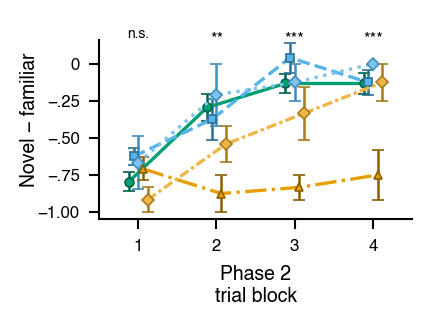

In [25]:
# Preview render: Panel 3D
fig, ax = plt.subplots(figsize=(2.2, 1.87 - 0.2))
panel_d_difference(ax)
panel_d_block_marks(ax)   # per-block VC_VC-vs-rest marks
fig.tight_layout()
plt.show()

Novel − familiar accuracy, median [Q1, Q3] across rats:
                       block 1               block 2               block 3               block 4
group                                                                                           
PI+VC     -0.75 [-1.00, -0.75]    0.00 [-0.50, 0.00]     0.00 [0.00, 0.00]     0.00 [0.00, 0.00]
PI_PI     -0.62 [-0.75, -0.50]  -0.25 [-0.44, -0.25]     0.00 [0.00, 0.00]    0.00 [-0.19, 0.00]
PI_PI+VC  -0.88 [-1.00, -0.38]   -0.12 [-0.44, 0.00]     0.00 [0.00, 0.00]     0.00 [0.00, 0.00]
VC_VC     -0.75 [-0.75, -0.56]  -1.00 [-1.00, -1.00]  -0.88 [-1.00, -0.75]  -1.00 [-1.00, -0.62]
VC_PI+VC  -1.00 [-1.00, -1.00]  -0.50 [-0.69, -0.31]   -0.12 [-0.62, 0.00]     0.00 [0.00, 0.00]
marks, mean figure -> median figure: block 1 n.s. -> n.s., block 2 ** -> **, block 3 *** -> ***, block 4 *** -> ***


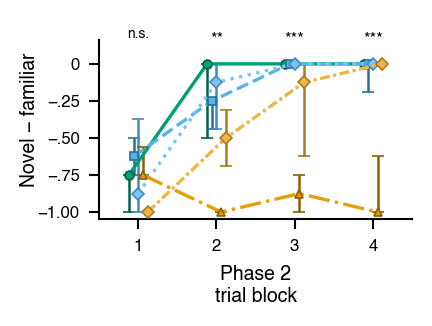

In [26]:
# Median variant of Panel 3D (median figure): median across rats of the per-rat
# novel - familiar difference (a coarse grid: novel k/4 minus familiar k/2, so
# many cells sit exactly at 0 or -1 with zero-length bars), quartile bars,
# marks from the Mann-Whitney companion of the per-block VC_VC-vs-rest contrast.
grp_diff_med = median_quartiles(rat_diff, 'diff', keys=('group', 'x_order'))
D_BLOCK_STATS_MED = median_marks(D_BLOCK_STATS)
print('Novel − familiar accuracy, median [Q1, Q3] across rats:')
print(median_table(grp_diff_med).to_string())
print('marks, mean figure -> median figure: ' + marks_summary(D_BLOCK_STATS, D_BLOCK_STATS_MED))
fig, ax = plt.subplots(figsize=(2.2, 1.87 - 0.2))
panel_d_difference(ax, grp_diff=grp_diff_med)
panel_d_block_marks(ax, stats_by_block=D_BLOCK_STATS_MED)   # rank-based marks
fig.tight_layout()
plt.show()


## Statistics — Panel 3E novel-route perseveration (manuscript tests)

Perseveration = the rat ran one of the two trained responses on a novel-route
trial (knob `PERS_SCORE`: 'initiated' = coord_route is a trained route;
'error' = also errors > 0). Assumption checks first (per-cell normality,
mixed-model residuals, Brown–Forsythe per block, rank-transformed refit), then
the manuscript tests: pooled k/N binomials vs chance 0.5 (block 1 / all 16),
per-rat vs-chance t-tests, block-1 and all-16 one-way ANOVAs, the VC_VC-vs-rest grouped contrast, and the 4 × 5 mixed ANOVA on the per-rat block proportions (afex
Type 3; Mauchly does not reject, so the df stay uncorrected: block F(3, 108) = 33.56,
group F(4, 36) = 3.43, p = .018, block × group F(12, 108) = 2.19, p = .017). The
rank-transformed refit in the assumptions cell is a robustness check only.

In [27]:
# Panel-3E data + assumption checks for the perseveration tests below.
from corner_maze.features.perseveration import (trained_responses, compute_perseveration,
                                                assert_trained_share_second_turn)

PERS_SCORE = 'initiated'   # 'initiated': coord_route is a trained route (turn-based; 24 self-corrected trials count as perseverative)
                           # 'error':     trained route AND errors > 0 (committed the perseverative error)

trained = trained_responses(probe, route_label=probe['route'])   # session_id -> the two trained responses
assert_trained_share_second_turn(trained)                         # 2S2C invariant: both share their 2nd turn
probe['pers_initiated'] = compute_perseveration(probe, trained)   # nullable bool per trial
probe['pers_error'] = probe['pers_initiated'] & (probe['errors'] > 0)
probe['pers'] = probe[f'pers_{PERS_SCORE}'].astype('Float64').astype(float)   # NA -> nan

novp = probe[(probe['route'] == 'novel') & probe['block'].notna()].copy()
novp['block'] = novp['block'].astype(int)
_na = novp['pers'].isna()
_self_corr = novp['pers_initiated'].eq(True) & (novp['errors'] == 0)
print(f"Panel E score = '{PERS_SCORE}'. Novel trials (blocks 1-4): {len(novp)}; NA (no coord_route): {int(_na.sum())} "
      f"({100*_na.mean():.1f}%); initiated-but-self-corrected (trained turns, correct well first): {int(_self_corr.sum())}")

# Rat-level unit: per-rat proportion per block; same columns as group_acc / lat_mean so panel_accuracy draws it.
rat_pers = (novp.groupby(['subject_id', 'group', 'block'], observed=True)['pers'].mean()
            .reset_index())
rat_pers['route'] = 'novel'
rat_pers['x'] = rat_pers['block'].astype(str)
rat_pers['x_order'] = rat_pers['block']
pers_mean = mean_sem(rat_pers, 'pers')
rat_pers16 = novp.groupby(['subject_id', 'group'], observed=True)['pers'].mean().reset_index()
pers_complete = rat_pers.groupby('subject_id').filter(lambda d: d['pers'].notna().sum() == 4)

# Assumption checks (DV = per-rat block proportion over ~4 trials -> coarse grid
# with floor/ceiling; per-cell normality fails largely by construction).
_rp = rat_pers.dropna(subset=['pers'])
print('\n=== Normality: Shapiro-Wilk per group x block cell ===')
_rej, _tot, _degen = 0, 0, 0
for (_g, _b), _v in _rp.groupby(['group', 'block'], observed=True)['pers']:
    _v = _v.to_numpy(float)
    if len(np.unique(_v)) < 2:
        _degen += 1
        continue
    _tot += 1
    _rej += stats.shapiro(_v).pvalue < .05
print(f'{_rej}/{_tot} testable cells reject at .05; {_degen} cell(s) with zero variance')
_cellm = _rp.groupby(['group', 'block'], observed=True)['pers'].transform('mean')
_sww = stats.shapiro((_rp['pers'] - _cellm).to_numpy())
_submeans = _rp.groupby(['subject_id', 'group'], observed=True)['pers'].mean()
_swb = stats.shapiro(
    (_submeans - _submeans.groupby('group', observed=True).transform('mean')).to_numpy())
print(f'within-cell residuals: W = {_sww.statistic:.3f}, p = {_sww.pvalue:.4g}')
print(f'between-subject residuals: W = {_swb.statistic:.3f}, p = {_swb.pvalue:.4g}')

print('\n=== Homogeneity across groups per block: Brown-Forsythe ===')
for _b in sorted(_rp['block'].unique()):
    _vals = [_rp[(_rp['group'] == _g) & (_rp['block'] == _b)]['pers'].to_numpy(float)
             for _g in GROUP_ORDER]
    _lv = stats.levene(*_vals, center='median')
    print(f'block {_b}: W = {_lv.statistic:.3f}, p = {_lv.pvalue:.4g}')

print('\n=== Robustness: rank-transformed 4x5 mixed ANOVA ===')
_aovr = mixed_anova_afex(pers_complete.assign(rank=pers_complete['pers'].rank()), 'rank',
                         label='3E perseveration [rank refit]')

R callback write-console: Contrasts set to contr.sum for the following variables: group
  


R callback write-console: In addition:   


R callback write-console: Warning message:
  


R callback write-console: In summary.Anova.mlm(object$Anova, multivariate = FALSE) :  


R callback write-console: 
   


R callback write-console:  HF eps > 1 treated as 1
  


Panel E score = 'initiated'. Novel trials (blocks 1-4): 656; NA (no coord_route): 24 (3.7%); initiated-but-self-corrected (trained turns, correct well first): 24

=== Normality: Shapiro-Wilk per group x block cell ===
10/19 testable cells reject at .05; 1 cell(s) with zero variance
within-cell residuals: W = 0.976, p = 0.006003
between-subject residuals: W = 0.976, p = 0.5273

=== Homogeneity across groups per block: Brown-Forsythe ===
block 1: W = 0.971, p = 0.4354
block 2: W = 2.517, p = 0.05824
block 3: W = 0.732, p = 0.5762
block 4: W = 1.516, p = 0.218

=== Robustness: rank-transformed 4x5 mixed ANOVA ===
=== 3E perseveration [rank refit]: 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.879, p = 0.4835 -> sphericity not rejected; GG eps = 0.930, HF eps = 1.016
     Source     F df (unc)   p (unc)      df (GG)    p (GG)   np2
      group  3.50    4, 36   0.01623            -         - 0.280
      block 32.19   3, 108 

In [28]:
# Uses novp / rat_pers / rat_pers16 / pers_complete from the assumptions cell above.
print('Perseverative trials pooled over rats (k/N), by group x block:')
_pt = novp.groupby(['group', 'block'], observed=True)['pers'].agg(['sum', 'count'])
print(pd.DataFrame({b: [f'{int(_pt.loc[(g, b), "sum"])}/{int(_pt.loc[(g, b), "count"])}' for g in GROUP_ORDER]
                    for b in (1, 2, 3, 4)}, index=GROUP_ORDER).to_string())

# Pooled binomials vs chance 0.5 (the manuscript's per-group tests).
print('\nPooled binomial vs 0.5 (k/N, p):')
for _lab, _d in (('block 1', novp[novp['block'] == 1]), ('all 16', novp)):
    _row = []
    for _g in GROUP_ORDER:
        _v = _d.loc[_d['group'] == _g, 'pers'].dropna()
        _bt = stats.binomtest(int(_v.sum()), len(_v), 0.5)
        _row.append(f'{_g} {int(_v.sum())}/{len(_v)} (p={_bt.pvalue:.3g})')
    print(f'  {_lab}: ' + '; '.join(_row))

print('\nGroup mean perseveration (per-rat block proportions):')
print(pers_mean.pivot(index='group', columns='x', values='mean')[['1', '2', '3', '4']].round(2).to_string())

_b1 = rat_pers[rat_pers['block'] == 1]
print('\nVs chance 0.5, per-rat proportions (t-test):')
for _lab, _d in (('block 1', _b1), ('all 16', rat_pers16)):
    _row = []
    for _g in GROUP_ORDER + ['ALL']:
        _v = (_d if _g == 'ALL' else _d[_d['group'] == _g])['pers'].dropna().to_numpy(float)
        _t = stats.ttest_1samp(_v, 0.5)
        _row.append(f'{_g} {_v.mean():.2f} (p={_t.pvalue:.3f})')
    print(f'  {_lab}: ' + '; '.join(_row))

PERS_STATS = {}
if HAS_PG:
    _aov1 = pg.anova(data=_b1.dropna(subset=['pers']), dv='pers', between='group')
    print(f"\nBlock-1 one-way ANOVA: "
          f"F({int(_aov1['ddof1'].iloc[0])},{int(_aov1['ddof2'].iloc[0])}) = "
          f"{float(_aov1['F'].iloc[0]):.2f}, p = {float(_aov1['p_unc'].iloc[0]):.4g}")
    _aov = pg.anova(data=rat_pers16, dv='pers', between='group')
    vc = rat_pers16.loc[rat_pers16['group'] == 'VC_VC', 'pers'].to_numpy(float)
    rest = rat_pers16.loc[rat_pers16['group'] != 'VC_VC', 'pers'].to_numpy(float)
    # Grouped contrast VC_VC vs rest: pooled ANOVA error (the manuscript's F(1,36)) +
    # Scheffé, with Welch and Mann-Whitney as variance-robust companions.
    _gm = rat_pers16.groupby('group', observed=True)['pers'].agg(['mean', 'count'])
    _dfe = len(rat_pers16) - len(_gm)
    _mse = sum(((v['pers'] - v['pers'].mean()) ** 2).sum()
               for _, v in rat_pers16.groupby('group', observed=True)) / _dfe
    _others = [g for g in _gm.index if g != 'VC_VC']
    _w = {'VC_VC': 1.0, **{g: -1 / len(_others) for g in _others}}
    _psi = sum(wi * _gm.loc[g, 'mean'] for g, wi in _w.items())
    _Fc = _psi ** 2 / (_mse * sum(wi ** 2 / _gm.loc[g, 'count'] for g, wi in _w.items()))
    _tt = pg.ttest(vc, rest, correction=True).iloc[0]
    PERS_STATS = {'F': float(_aov['F'].iloc[0]), 'p': float(_aov['p_unc'].iloc[0]),
                  'df1': int(_aov['ddof1'].iloc[0]), 'df2': int(_aov['ddof2'].iloc[0]),
                  'F_vc': float(_Fc), 'p_vc_pool': float(stats.f.sf(_Fc, 1, _dfe)),
                  'p_vc_scheffe': float(stats.f.sf(_Fc / (len(_gm) - 1), len(_gm) - 1, _dfe)),
                  't_vc': float(_tt['T']), 'df_vc': float(_tt['dof']), 'p_vc': float(_tt['p_val']),
                  'p_vc_mwu': float(pg.mwu(vc, rest)['p_val'].iloc[0])}
    PERS_STATS['star'] = p_to_stars(PERS_STATS['p_vc'])
    print(f"All-16 one-way ANOVA: "
          f"F({PERS_STATS['df1']},{PERS_STATS['df2']}) = {PERS_STATS['F']:.2f}, p = {PERS_STATS['p']:.4g}")
    print(f"VC_VC ({vc.mean():.2f}) vs rest ({rest.mean():.2f}), grouped contrast "
          f"pooled F(1,{_dfe}) = {_Fc:.2f}, "
          f"p = {PERS_STATS['p_vc_pool']:.4g}; Scheffé p = {PERS_STATS['p_vc_scheffe']:.4g}; "
          f"Welch t({PERS_STATS['df_vc']:.1f}) = {PERS_STATS['t_vc']:.2f}, p = {PERS_STATS['p_vc']:.4g}; "
          f"Mann-Whitney p = {PERS_STATS['p_vc_mwu']:.4g} -> '{PERS_STATS['star']}'")
else:
    print('\npingouin not installed; skipping the one-way ANOVAs and the contrast.')

# Manuscript test: 4x5 mixed ANOVA on the per-rat block proportions, afex Type 3.
# Mauchly does not reject (W = .89, p = .54) -> uncorrected df under GG_RULE =
# 'mauchly': block F(3, 108) = 33.56, group F(4, 36) = 3.43 (p = .018),
# block x group F(12, 108) = 2.19 (p = .017). This raw analysis is the one to
# cite; the rank refit printed in the assumptions cell (42.3 / 3.50 / 2.36) is a
# robustness companion only.
print()
aov_e = mixed_anova_afex(pers_complete, 'pers', label='3E perseveration (per-rat proportions)')

# Per-block VC_VC-vs-rest grouped contrasts -> the Panel-E per-block marks.
# The pooled F(1,36) drives the mark (the manuscript's contrast style; Mann-Whitney
# agrees at every block, while Welch collapses to df ~ 6 at block 4).
PERS_BLOCK_STATS = {}
print('\nPer-block VC_VC vs rest (pooled F / Welch / Mann-Whitney):')
for _b in sorted(rat_pers['block'].unique()):
    _d = rat_pers[rat_pers['block'] == _b].dropna(subset=['pers'])
    _vcb = _d.loc[_d['group'] == 'VC_VC', 'pers'].to_numpy(float)
    _restb = _d.loc[_d['group'] != 'VC_VC', 'pers'].to_numpy(float)
    _gm = _d.groupby('group', observed=True)['pers'].agg(['mean', 'count'])
    _dfe = len(_d) - len(_gm)
    _mse = sum(((v['pers'] - v['pers'].mean()) ** 2).sum()
               for _, v in _d.groupby('group', observed=True)) / _dfe
    _others = [g for g in _gm.index if g != 'VC_VC']
    _w = {'VC_VC': 1.0, **{g: -1 / len(_others) for g in _others}}
    _psi = sum(wi * _gm.loc[g, 'mean'] for g, wi in _w.items())
    _Fb = _psi ** 2 / (_mse * sum(wi ** 2 / _gm.loc[g, 'count'] for g, wi in _w.items()))
    _pp = float(stats.f.sf(_Fb, 1, _dfe))
    _tw = stats.ttest_ind(_vcb, _restb, equal_var=False)
    _mw = stats.mannwhitneyu(_vcb, _restb, alternative='two-sided')
    PERS_BLOCK_STATS[int(_b)] = {'F': float(_Fb), 'dfe': int(_dfe), 'p': _pp,
                                 'p_welch': float(_tw.pvalue), 'p_mwu': float(_mw.pvalue),
                                 'mark': p_to_marks(_pp),
                                 'mean_vc': float(_vcb.mean()), 'mean_rest': float(_restb.mean())}
    _s = PERS_BLOCK_STATS[int(_b)]
    print(f"  block {int(_b)}: VC_VC {_s['mean_vc']:.2f} vs rest {_s['mean_rest']:.2f} | "
          f"F(1,{_s['dfe']}) = {_s['F']:.2f}, p = {_s['p']:.4g} -> '{_s['mark']}' | "
          f"Welch p = {_s['p_welch']:.4g} | MW p = {_s['p_mwu']:.4g}")

Perseverative trials pooled over rats (k/N), by group x block:


              1      2      3      4
PI+VC     50/62  29/61  12/67   8/66
PI_PI     18/23  16/24   8/22   5/22
PI_PI+VC  17/23   7/23   3/24   0/24
VC_VC     17/24  21/24  19/24  16/24
VC_PI+VC  21/23  14/24   8/24   3/24

Pooled binomial vs 0.5 (k/N, p):
  block 1: PI+VC 50/62 (p=1.21e-06); PI_PI 18/23 (p=0.0106); PI_PI+VC 17/23 (p=0.0347); VC_VC 17/24 (p=0.0639); VC_PI+VC 21/23 (p=6.6e-05)
  all 16: PI+VC 99/256 (p=0.000348); PI_PI 47/91 (p=0.834); PI_PI+VC 27/94 (p=4.5e-05); VC_VC 73/96 (p=3.11e-07); VC_PI+VC 46/95 (p=0.838)

Group mean perseveration (per-rat block proportions):
x            1     2     3     4
group                           
PI+VC     0.77  0.45  0.19  0.12
PI_PI     0.79  0.67  0.42  0.21
PI_PI+VC  0.71  0.33  0.12  0.00
VC_PI+VC  0.92  0.58  0.33  0.12
VC_VC     0.71  0.88  0.79  0.67

Vs chance 0.5, per-rat proportions (t-test):
  block 1: PI+VC 0.77 (p=0.001); PI_PI 0.79 (p=0.013); PI_PI+VC 0.71 (p=0.259); VC_VC 0.71 (p=0.042); VC_PI+VC 0.92 (p=0.004); ALL 0.7

R callback write-console: Contrasts set to contr.sum for the following variables: group
  


R callback write-console: In addition:   


R callback write-console: Warning message:
  


R callback write-console: In summary.Anova.mlm(object$Anova, multivariate = FALSE) :  


R callback write-console: 
   


R callback write-console:  HF eps > 1 treated as 1
  


=== 3E perseveration (per-rat proportions): 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.889, p = 0.5389 -> sphericity not rejected; GG eps = 0.935, HF eps = 1.022
     Source     F df (unc)   p (unc)      df (GG)    p (GG)   np2
      group  3.43    4, 36   0.01791            -         - 0.276
      block 33.56   3, 108 2.091e-15  2.80, 101.0 1.497e-14 0.482
Interaction  2.19  12, 108   0.01698 11.22, 101.0   0.01984 0.196
Reported (GG_RULE = 'mauchly' -> uncorrected df): group F(4, 36) = 3.43, p = .018; block F(3, 108) = 33.56, p < .001; block × group F(12, 108) = 2.19, p = .017

Per-block VC_VC vs rest (pooled F / Welch / Mann-Whitney):
  block 1: VC_VC 0.71 vs rest 0.79 | F(1,36) = 0.56, p = 0.4582 -> 'n.s.' | Welch p = 0.3825 | MW p = 0.2387
  block 2: VC_VC 0.88 vs rest 0.49 | F(1,36) = 4.30, p = 0.04541 -> '*' | Welch p = 0.02614 | MW p = 0.02327


  block 3: VC_VC 0.79 vs rest 0.24 | F(1,36) = 11.20, p = 0.001924 -> '**' | Welch p = 9.269e-05 | MW p = 0.002358
  block 4: VC_VC 0.67 vs rest 0.11 | F(1,36) = 19.10, p = 0.000101 -> '***' | Welch p = 0.01984 | MW p = 0.0006206


## Panel 3E — perseveration (preview)

In [29]:
# Uses pers_mean from the Panel-3E statistics section above.
def panel_e_perseveration(ax, *, group_acc=None, title='Novel trials',
                          ylabel='Perseveration (prop. trials)',   # one line: the shared left pad (0.44 in) clears a single-line y-label only
                          chance_y=0.5, ylim=None,   # None -> FIG3E_YLIM (marks headroom)
                          yticks=(0, 0.2, 0.4, 0.6, 0.8, 1.0),
                          show_legend=False, **kw):
    """Panel E: novel-route perseveration per Phase-2 block, group mean ± SEM
    (same drawing code as Panels C/G; dotted line = chance 0.5)."""
    if ylim is None:
        ylim = FIG3E_YLIM
    return panel_accuracy(ax, route='novel', include_p1=False,
                          group_acc=pers_mean if group_acc is None else group_acc,
                          title=title, xlabel='Phase 2\ntrial block', ylabel=ylabel,
                          show_chance=True, chance_y=chance_y, ylim=ylim, yticks=yticks,
                          show_legend=show_legend, **kw)



# ============================================================================
# Fig 3E per-block mark knobs (one marks row above the blocks, like Panel C's)
# ============================================================================
FIG3E_MARK_Y = None              # fixed data-y override (None = MARK_FRAC row)
FIG3E_MARK_FONTSIZE = STYLE_CFG['star_fontsize']
FIG3E_MARK_NS_FONTSIZE = 5
FIG3E_YLIM = ylim_for(-0.025, 1.0)   # top tick 1.0 at TOP_TICK_FRAC (uniform)


def panel_e_block_marks(ax, *, stats_by_block=None, y=None, ylim=None):
    """One row of per-block significance marks (PERS_BLOCK_STATS: pooled-F
    VC_VC-vs-rest within each block) at MARK_FRAC of the axes height
    (uniform across panels; override with `y` / FIG3E_MARK_Y)."""
    sb = PERS_BLOCK_STATS if stats_by_block is None else stats_by_block
    y_fix = FIG3E_MARK_Y if y is None else y
    _ylim = FIG3E_YLIM if ylim is None else ylim   # the median figure passes its own scale
    y_row = mark_row_y(*_ylim) if y_fix is None else y_fix
    for b, s in sb.items():
        is_star = s['mark'] not in ('n.s.', '\u2020')
        draw_mark(ax, b, y_row, s['mark'],
                  FIG3E_MARK_FONTSIZE if is_star else FIG3E_MARK_NS_FONTSIZE)
    trim_left_spine(ax, _ylim)
    return ax

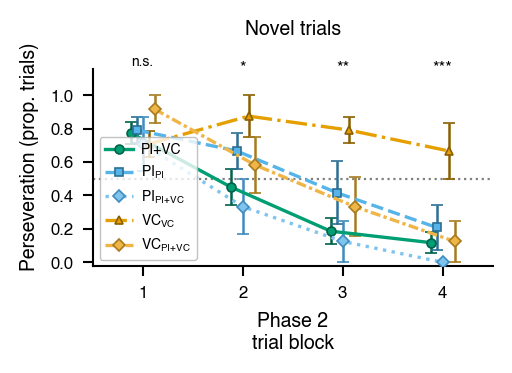

In [30]:
# Preview render: Panel E (novel-route perseveration), same rect as the Panel C/G previews
fig = plt.figure(figsize=(2.5, 1.87 - 0.1))
ax = fig.add_axes([0.17, 0.24, 0.80, 0.62])
panel_e_perseveration(ax, show_legend=True, legend_loc='lower left', legend_fontsize=5, legend_frameon=True)
panel_e_block_marks(ax)   # per-block VC_VC-vs-rest marks
plt.show()


Perseveration, median [Q1, Q3] across rats:
                    block 1            block 2            block 3            block 4
group                                                                               
PI+VC     0.75 [0.75, 1.00]  0.50 [0.00, 1.00]  0.00 [0.00, 0.25]  0.00 [0.00, 0.00]
PI_PI     0.75 [0.75, 0.94]  0.75 [0.56, 0.75]  0.25 [0.06, 0.81]  0.00 [0.00, 0.38]
PI_PI+VC  0.88 [0.56, 1.00]  0.25 [0.00, 0.50]  0.00 [0.00, 0.00]  0.00 [0.00, 0.00]
VC_VC     0.75 [0.56, 0.75]  1.00 [1.00, 1.00]  0.75 [0.75, 0.94]  0.75 [0.50, 1.00]
VC_PI+VC  1.00 [1.00, 1.00]  0.62 [0.31, 0.94]  0.12 [0.00, 0.62]  0.00 [0.00, 0.00]
marks, mean figure -> median figure: block 1 n.s. -> n.s., block 2 * -> *, block 3 ** -> **, block 4 *** -> ***


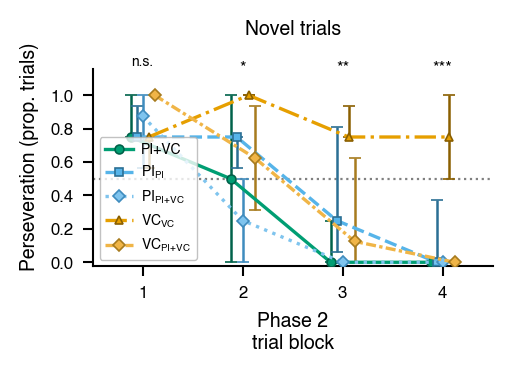

In [31]:
# Median variant of Panel 3E (median figure): median across rats of the per-rat
# block perseveration proportion, quartile bars, marks from the Mann-Whitney
# companion of the per-block VC_VC-vs-rest contrast.
pers_med = median_quartiles(rat_pers, 'pers')
PERS_BLOCK_STATS_MED = median_marks(PERS_BLOCK_STATS)
print('Perseveration, median [Q1, Q3] across rats:')
print(median_table(pers_med).to_string())
print('marks, mean figure -> median figure: ' + marks_summary(PERS_BLOCK_STATS, PERS_BLOCK_STATS_MED))
fig = plt.figure(figsize=(2.5, 1.87 - 0.1))
ax = fig.add_axes([0.17, 0.24, 0.80, 0.62])
panel_e_perseveration(ax, group_acc=pers_med, show_legend=True, legend_loc='lower left',
                      legend_fontsize=5, legend_frameon=True)
panel_e_block_marks(ax, stats_by_block=PERS_BLOCK_STATS_MED)   # rank-based marks
plt.show()


## Latency to first well entry — data

**Metric.** `trials.first_choice_latency_s` (seconds): time from trial onset (doors open) to the
**first well visited, reward or error** (`stage3c_well_visits.py`; the column name says "choice"
but it is first-*well* latency). Aggregated per rat × Phase-1 / Phase-2 block × route, then group
mean ± SEM across rats (Panels F, G; Panel H takes their per-rat paired difference). Latency is right-skewed; `lat_med` (median with quartiles, via `median_quartiles`) feeds
the same panels in the median figure, on its own y-scale (`LAT_YLIM_MED`).


In [32]:
# --- Metric: latency to first well entry (reward or error), seconds ---------
probe['latency_s'] = probe['first_choice_latency_s'].astype('float64')
print(f"\nlatency_s: NA = {probe['latency_s'].isna().mean()*100:.2f}% of {len(probe)} probe trials; "
      f"median = {probe['latency_s'].median():.2f} s, "
      f"IQR = {probe['latency_s'].quantile(0.25):.2f}–{probe['latency_s'].quantile(0.75):.2f} s, "
      f"max = {probe['latency_s'].max():.1f} s")
print('\nLatency (s) by phase × route, trial-level median [IQR]:')
_q = probe.groupby(['phase', 'route'])['latency_s'].quantile([0.25, 0.5, 0.75]).unstack()
_q.columns = ['q25', 'median', 'q75']
print(_q.round(2).to_string())



latency_s: NA = 0.00% of 1640 probe trials; median = 4.66 s, IQR = 4.13–5.80 s, max = 122.4 s

Latency (s) by phase × route, trial-level median [IQR]:
                 q25  median   q75
phase route                       
P1    familiar  4.00    4.37  5.17
P2    familiar  4.03    4.43  4.95
      novel     4.47    5.23  6.71


## Aggregation — per-rat × group × block latency

Same shape as figure3's `per_rat_block_accuracy`: Phase-1 familiar trials
collapse to one bucket (`x_order` 0, tick "1+2"); Phase-2 split by
route × block (`x_order` 1–4). Per-rat **mean** latency within each bucket,
then across rats: mean ± SEM (`lat_mean`) and median with quartiles (`lat_med`, via
`median_quartiles`; drawn in the median figure).
The `mean`/`sem` column names are kept so `panel_accuracy` can plot either.

In [33]:
def per_rat_block_latency(probe_df: pd.DataFrame, value='latency_s') -> pd.DataFrame:
    out = []
    p1 = probe_df[(probe_df['phase'] == 'P1') & (probe_df['route'] == 'familiar')]
    a = p1.groupby(['subject_id', 'group'], observed=True)[value].mean().reset_index()
    a['route'] = 'familiar'
    a['x'] = 'P1'
    a['x_order'] = 0
    out.append(a)
    p2 = probe_df[(probe_df['phase'] == 'P2') & probe_df['block'].notna()]
    a = (p2.groupby(['subject_id', 'group', 'route', 'block'], observed=True)
            [value].mean().reset_index())
    a['x'] = a['block'].astype(int).astype(str)
    a['x_order'] = a['block'].astype(int)
    out.append(a.drop(columns='block'))
    return pd.concat(out, ignore_index=True)

rat_lat = per_rat_block_latency(probe)

def mean_sem(df, value='latency_s'):
    g = df.groupby(['group', 'route', 'x_order', 'x'], observed=True)[value]
    return pd.DataFrame({'mean': g.mean(), 'sem': g.sem(), 'n': g.size()}).reset_index()

lat_mean = mean_sem(rat_lat)
lat_med = median_quartiles(rat_lat, 'latency_s')   # median figure (Panels F/G; H takes the per-rat difference)

# Rats contributing per (group | route.x_order). Familiar P2 blocks have only
# 2 trials each, so a block can be lost to latency NA; check the dropoff here.
n_tab = (rat_lat.dropna(subset=['latency_s'])
                .groupby(['group', 'route', 'x_order'], observed=True)['subject_id']
                .nunique().unstack(['route', 'x_order']).fillna(0).astype(int))
print('Rats contributing per (group | route.x_order); x_order 0 = Phase 1 "1+2", 1-4 = Phase-2 blocks:')
print(n_tab.to_string())

print('\nGroup mean latency (s), familiar route:')
print(lat_mean[lat_mean['route'] == 'familiar']
      .pivot(index='group', columns='x', values='mean')[['P1', '1', '2', '3', '4']]
      .round(2).to_string())
print('\nGroup mean latency (s), novel route:')
print(lat_mean[lat_mean['route'] == 'novel']
      .pivot(index='group', columns='x', values='mean')[['1', '2', '3', '4']]
      .round(2).to_string())


# Shared y-scale for the latency panels (F & G)
def _ylims(*accs, pad=1.15):
    """Shared y-range across the given aggregates: 0 .. pad × max(mean + sem)
    (mean + err_hi, the upper quartile, for the median aggregates)."""
    top = max(float((a['mean'] + (a['err_hi'] if 'err_hi' in a else a['sem']).fillna(0)).max())
              for a in accs) * pad
    step = 1.0 if top <= 6 else 2.0 if top <= 14 else 5.0
    return (0, top), np.arange(0, top + 1e-9, step)

LAT_YLIM, LAT_YTICKS = _ylims(lat_mean)
# Uniform top-tick geometry: rescale so the top tick sits at TOP_TICK_FRAC,
# like every other panel (marks row at MARK_FRAC via mark_row_y).
LAT_YLIM = ylim_for(LAT_YLIM[0], float(LAT_YTICKS[-1]))
LAT_YLABEL = 'Latency to first well (s)'
print(f'Latency panels: ylim = (0, {LAT_YLIM[1]:.1f}) s, ticks = {LAT_YTICKS.tolist()}')

# Median figure: the same rule on the median aggregate. Its upper quartiles
# reach higher than mean + SEM (PI+VC novel block 1: Q3 = 18.1 s), so the top
# tick becomes 20 s; to force the mean figure's scale instead set
# LAT_YLIM_MED, LAT_YTICKS_MED = LAT_YLIM, LAT_YTICKS.
LAT_YLIM_MED, LAT_YTICKS_MED = _ylims(lat_med)
LAT_YLIM_MED = ylim_for(LAT_YLIM_MED[0], float(LAT_YTICKS_MED[-1]))
print(f'Median latency panels: ylim = (0, {LAT_YLIM_MED[1]:.1f}) s, ticks = {LAT_YTICKS_MED.tolist()}')

Rats contributing per (group | route.x_order); x_order 0 = Phase 1 "1+2", 1-4 = Phase-2 blocks:
route    familiar                 novel            
x_order         0   1   2   3   4     1   2   3   4
group                                              
PI+VC          17  17  17  17  17    17  17  17  17
PI_PI           6   6   6   6   6     6   6   6   6
PI_PI+VC        6   6   6   6   6     6   6   6   6
VC_PI+VC        6   6   6   6   6     6   6   6   6
VC_VC           6   6   6   6   6     6   6   6   6

Group mean latency (s), familiar route:
x           P1     1     2     3      4
group                                  
PI+VC     4.95  5.11  4.75  4.92   4.30
PI_PI     5.42  5.56  6.49  6.76  10.38
PI_PI+VC  6.09  7.11  5.25  4.98   4.79
VC_PI+VC  4.72  4.48  4.40  5.38   4.55
VC_VC     4.16  4.14  4.31  3.94   4.04

Group mean latency (s), novel route:
x             1     2     3     4
group                            
PI+VC     13.01  7.96  5.30  7.15
PI_PI     12.91  8.18  6.49

## Statistics — Panel 3F familiar-route latency

Phase-1 latency: assumption checks, then a one-way ANOVA across the 5 groups
with robust companions (Welch, Kruskal–Wallis, log-scale ANOVA — latency is
right-skewed, so log is the natural analysis scale). Phase-2 familiar latency:
assumption checks, then the 4 × 5 mixed ANOVA (afex Type 3 with Mauchly's test
and the `GG_RULE` decision; raw, with log- and rank-refits as robustness), and a
grouped contrast on block-averaged latency (knob `C3F_CONTRAST_GROUP`, default
`PI_PI` vs the rest).

The manuscript reports the group main effect, which is robust to the analysis
scale (raw p = .0008, log p = .002, rank p = .03). The apparent PI_PI elevation
behind it does not survive variance-robust or nonparametric contrasts at n = 6
(Welch p = .069, Mann–Whitney p = .087), so it is not reported.

In [34]:
# Assumption checks for the Phase-1 familiar-latency one-way ANOVA below.
# Latency is right-skewed: raw residuals are expected to fail Shapiro while
# log residuals pass, so read conclusions off the log/robust tests when they
# disagree. Uses rat_lat (x_order 0 = Phase-1 mean over the 16 P1 trials).
p1_lat = (rat_lat[(rat_lat['route'] == 'familiar') & (rat_lat['x_order'] == 0)]
          .dropna(subset=['latency_s'])[['subject_id', 'group', 'latency_s']].copy())
_sbg = {g: v['latency_s'].to_numpy(float)
        for g, v in p1_lat.groupby('group', observed=True)}

print('=== Phase-1 familiar latency (s): group descriptives ===')
print(p1_lat.groupby('group', observed=True)['latency_s']
      .agg(['count', 'mean', 'sem', 'median']).round(2).to_string())

print('\n=== Normality: Shapiro-Wilk per group + pooled residuals (raw and log) ===')
for _g, _v in _sbg.items():
    print(f'{_g:10s} W = {stats.shapiro(_v).statistic:.3f}, p = {stats.shapiro(_v).pvalue:.4g}')
_res = np.concatenate([_v - _v.mean() for _v in _sbg.values()])
_lres = np.concatenate([np.log(_v) - np.log(_v).mean() for _v in _sbg.values()])
_sw, _swl = stats.shapiro(_res), stats.shapiro(_lres)
print(f'pooled residuals raw: W = {_sw.statistic:.3f}, p = {_sw.pvalue:.4g}; '
      f'log: W = {_swl.statistic:.3f}, p = {_swl.pvalue:.4g}')

print('\n=== Homogeneity: Brown-Forsythe (Levene, center=median) ===')
_lv = stats.levene(*_sbg.values(), center='median')
print(f'W = {_lv.statistic:.3f}, p = {_lv.pvalue:.4g}')

=== Phase-1 familiar latency (s): group descriptives ===
          count  mean   sem  median
group                              
PI+VC        17  4.95  0.16    4.86
PI_PI         6  5.42  0.51    5.31
PI_PI+VC      6  6.09  0.38    5.93
VC_PI+VC      6  4.72  0.46    4.37
VC_VC         6  4.16  0.27    4.10

=== Normality: Shapiro-Wilk per group + pooled residuals (raw and log) ===
PI+VC      W = 0.962, p = 0.6739
PI_PI      W = 0.895, p = 0.3447
PI_PI+VC   W = 0.909, p = 0.4307
VC_PI+VC   W = 0.772, p = 0.03254
VC_VC      W = 0.925, p = 0.5419
pooled residuals raw: W = 0.941, p = 0.03441; log: W = 0.963, p = 0.2054

=== Homogeneity: Brown-Forsythe (Levene, center=median) ===
W = 1.204, p = 0.3261


In [35]:
# Phase-1 familiar latency: one-way ANOVA + robust companions.
print('=== Phase-1 familiar latency: 1-way ANOVA (5 groups) ===')
if HAS_PG:
    p1l_aov = pg.anova(data=p1_lat, dv='latency_s', between='group', detailed=True)
    print(p1l_aov.to_string(index=False))
    _wa = pg.welch_anova(data=p1_lat, dv='latency_s', between='group').iloc[0]
    print(f"\nWelch ANOVA: F({_wa['ddof1']:.0f}, {_wa['ddof2']:.2f}) = "
          f"{_wa['F']:.2f}, p = {_wa['p_unc']:.3g}")
    _aovl = pg.anova(data=p1_lat.assign(log_lat=np.log(p1_lat['latency_s'])),
                     dv='log_lat', between='group')
    print(f"log-scale ANOVA: F({int(_aovl['ddof1'].iloc[0])}, {int(_aovl['ddof2'].iloc[0])}) = "
          f"{float(_aovl['F'].iloc[0]):.2f}, p = {float(_aovl['p_unc'].iloc[0]):.3g}")
else:
    _f, _p = stats.f_oneway(*_sbg.values())
    print(f'F = {_f:.3f}, p = {_p:.4g} (pingouin not installed)')
_kw = stats.kruskal(*_sbg.values())
print(f'Kruskal-Wallis: H = {_kw.statistic:.2f}, p = {_kw.pvalue:.3g}')

=== Phase-1 familiar latency: 1-way ANOVA (5 groups) ===
Source        SS  DF       MS        F    p_unc      np2
 group 12.786919   4 3.196730 4.153317 0.007224 0.315762
Within 27.708521  36 0.769681      NaN      NaN      NaN

Welch ANOVA: F(4, 12.30) = 3.97, p = 0.0274
log-scale ANOVA: F(4, 36) = 4.46, p = 0.00498
Kruskal-Wallis: H = 12.13, p = 0.0164


In [36]:
# Assumption checks for the Phase-2 familiar-latency 4x5 mixed ANOVA below.
# Familiar blocks hold only 2 trials, so a rat can lose a block to latency NA;
# complete-case rats are used for the mixed ANOVA (the completeness check
# prints who drops). Log/rank refits in the next cell are the robustness
# companions.
fam_lat = (rat_lat[(rat_lat['route'] == 'familiar') & (rat_lat['x_order'] >= 1)]
           .dropna(subset=['latency_s'])
           [['subject_id', 'group', 'x_order', 'latency_s']].copy())
fam_lat['block'] = fam_lat['x_order'].astype(int)
_nb = fam_lat.groupby('subject_id')['block'].nunique()
_incomplete = _nb[_nb < 4]
fam_lat_c = fam_lat[~fam_lat['subject_id'].isin(_incomplete.index)].copy()
print(f'{fam_lat["subject_id"].nunique()} rats; {len(_incomplete)} dropped for missing '
      f'blocks{": " + str(dict(_incomplete)) if len(_incomplete) else ""}; '
      f'{fam_lat_c["subject_id"].nunique()} complete-case rats')

print('\n=== Normality: Shapiro-Wilk per group x block cell ===')
_rej, _tot = 0, 0
for (_g, _b), _v in fam_lat_c.groupby(['group', 'block'], observed=True)['latency_s']:
    _v = _v.to_numpy(float)
    if len(np.unique(_v)) < 2:
        continue
    _tot += 1
    _rej += stats.shapiro(_v).pvalue < .05
print(f'{_rej}/{_tot} testable cells reject at .05')
_cellm = fam_lat_c.groupby(['group', 'block'], observed=True)['latency_s'].transform('mean')
_sww = stats.shapiro((fam_lat_c['latency_s'] - _cellm).to_numpy())
_lcellm = (fam_lat_c.assign(_l=np.log(fam_lat_c['latency_s']))
           .groupby(['group', 'block'], observed=True)['_l'].transform('mean'))
_swwl = stats.shapiro((np.log(fam_lat_c['latency_s']) - _lcellm).to_numpy())
print(f'within-cell residuals raw: W = {_sww.statistic:.3f}, p = {_sww.pvalue:.4g}; '
      f'log: W = {_swwl.statistic:.3f}, p = {_swwl.pvalue:.4g}')

print('\n=== Homogeneity across groups per block: Brown-Forsythe ===')
for _b in sorted(fam_lat_c['block'].unique()):
    _vals = [fam_lat_c[(fam_lat_c['group'] == _g) & (fam_lat_c['block'] == _b)]
             ['latency_s'].to_numpy(float) for _g in GROUP_ORDER]
    _lv = stats.levene(*_vals, center='median')
    print(f'block {_b}: W = {_lv.statistic:.3f}, p = {_lv.pvalue:.4g}')

41 rats; 0 dropped for missing blocks; 41 complete-case rats

=== Normality: Shapiro-Wilk per group x block cell ===
6/20 testable cells reject at .05
within-cell residuals raw: W = 0.769, p = 8.597e-15; log: W = 0.918, p = 5.329e-08

=== Homogeneity across groups per block: Brown-Forsythe ===
block 1: W = 1.382, p = 0.2597
block 2: W = 1.990, p = 0.1169
block 3: W = 1.681, p = 0.1758
block 4: W = 11.421, p = 4.355e-06


In [37]:
# Phase-2 familiar latency: 4x5 mixed ANOVA (raw + log + rank refits), then a
# grouped contrast on block-averaged latency. Knob: set to any other group
# name to flip the contrast target.
for _name, _df in [('raw', fam_lat_c.assign(y=fam_lat_c['latency_s'])),
                   ('log', fam_lat_c.assign(y=np.log(fam_lat_c['latency_s']))),
                   ('rank', fam_lat_c.assign(y=fam_lat_c['latency_s'].rank()))]:
    _aovm = mixed_anova_afex(_df, 'y', label=f'3F Phase-2 familiar latency [{_name}]')
    print()

C3F_CONTRAST_GROUP = 'PI_PI'
avg_lat = fam_lat.groupby(['subject_id', 'group'], observed=True)['latency_s'].mean().reset_index()
_gm = avg_lat.groupby('group', observed=True)['latency_s'].agg(['mean', 'count'])
_dfe = len(avg_lat) - len(_gm)
_mse = sum(((v['latency_s'] - v['latency_s'].mean()) ** 2).sum()
           for _, v in avg_lat.groupby('group', observed=True)) / _dfe
_others = [g for g in _gm.index if g != C3F_CONTRAST_GROUP]
_w = {C3F_CONTRAST_GROUP: 1.0, **{g: -1 / len(_others) for g in _others}}
_psi = sum(wi * _gm.loc[g, 'mean'] for g, wi in _w.items())
_F = _psi ** 2 / (_mse * sum(wi ** 2 / _gm.loc[g, 'count'] for g, wi in _w.items()))
_a = avg_lat.loc[avg_lat['group'] == C3F_CONTRAST_GROUP, 'latency_s'].to_numpy(float)
_b = avg_lat.loc[avg_lat['group'] != C3F_CONTRAST_GROUP, 'latency_s'].to_numpy(float)
_tw = stats.ttest_ind(_a, _b, equal_var=False)
_twl = stats.ttest_ind(np.log(_a), np.log(_b), equal_var=False)
_mw = stats.mannwhitneyu(_a, _b, alternative='two-sided')
_km1 = len(_gm) - 1
print(f'=== Grouped contrast: {C3F_CONTRAST_GROUP} ({_a.mean():.2f} s) vs rest '
      f'({_b.mean():.2f} s), block-averaged P2 familiar latency ===')
print(f'pooled: F(1,{_dfe}) = {_F:.2f}, p = {stats.f.sf(_F, 1, _dfe):.3g}; '
      f'Scheffé p = {stats.f.sf(_F / _km1, _km1, _dfe):.3g}')
print(f'Welch: t({_tw.df:.1f}) = {_tw.statistic:.2f}, p = {_tw.pvalue:.3g}; '
      f'log-Welch p = {_twl.pvalue:.3g}; Mann-Whitney p = {_mw.pvalue:.3g}')
print('NOTE: pooled vs per-group-variance tests disagree here; PI_PI has the '
      'largest variance (2 fast / 4 slow rats), so trust the Welch/log/rank '
      'line over the pooled F. Paper decision: report the group main effect '
      'only; the PI_PI elevation is not robust and was not pursued.')

R callback write-console: Contrasts set to contr.sum for the following variables: group
  


R callback write-console: Contrasts set to contr.sum for the following variables: group
  


R callback write-console: Contrasts set to contr.sum for the following variables: group
  


=== 3F Phase-2 familiar latency [raw]: 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.609, p = 0.004142 -> sphericity violated; GG eps = 0.771, HF eps = 0.827
     Source    F df (unc)   p (unc)    df (GG)   p (GG)   np2
      group 6.02    4, 36 0.0008128          -        - 0.401
      block 0.65   3, 108    0.5836 2.31, 83.3   0.5454 0.018
Interaction 2.93  12, 108  0.001496 9.25, 83.3 0.004253 0.245
Reported (GG_RULE = 'mauchly' -> GG df): group F(4, 36) = 6.02, p < .001; block F(2.31, 83.3) = 0.65, p = .55; block × group F(9.25, 83.3) = 2.93, p = .004

=== 3F Phase-2 familiar latency [log]: 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.844, p = 0.3184 -> sphericity not rejected; GG eps = 0.898, HF eps = 0.978
     Source    F df (unc)  p (unc)     df (GG)  p (GG)   np2
      group 5.10    4, 36 0.002324           -       - 0.362
      block 0.10   3,

R callback write-console: In addition:   


R callback write-console: Warning message:
  


R callback write-console: In summary.Anova.mlm(object$Anova, multivariate = FALSE) :  


R callback write-console: 
   


R callback write-console:  HF eps > 1 treated as 1
  


=== 3F Phase-2 familiar latency [rank]: 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.868, p = 0.4275 -> sphericity not rejected; GG eps = 0.920, HF eps = 1.004
     Source    F df (unc) p (unc)     df (GG)  p (GG)   np2
      group 2.98    4, 36 0.03175           -       - 0.249
      block 0.34   3, 108  0.7983  2.76, 99.3  0.7816 0.009
Interaction 1.82  12, 108 0.05321 11.04, 99.3 0.05972 0.168
Reported (GG_RULE = 'mauchly' -> uncorrected df): group F(4, 36) = 2.98, p = .032; block F(3, 108) = 0.34, p = .80; block × group F(12, 108) = 1.82, p = .053

=== Grouped contrast: PI_PI (7.30 s) vs rest (4.78 s), block-averaged P2 familiar latency ===
pooled: F(1,36) = 19.57, p = 8.6e-05; Scheffé p = 0.00296
Welch: t(5.2) = 2.29, p = 0.069; log-Welch p = 0.0748; Mann-Whitney p = 0.0865
NOTE: pooled vs per-group-variance tests disagree here; PI_PI has the largest variance (2 fast / 4 slow rats), so trust the Welch/log/rank lin

## Panel 3F — familiar-route latency (per-position marks + preview)

One row of significance marks over the Phase-1 point and each Phase-2 block:
a one-way group ANOVA (5 groups) per x position, `***`/`**`/`*`/`†`/`n.s.`
from the pooled F, with Welch, Kruskal–Wallis and log-scale companions
printed (latency is right-skewed).

In [38]:
# Per-position one-way ANOVAs (5 groups) on familiar latency -> the Panel-F
# marks: P1 ('1+2') plus each Phase-2 block. Pooled F drives the mark; Welch,
# Kruskal-Wallis and log-scale ANOVA printed alongside (latency is skewed).
F_BLOCK_STATS = {}
print('Per-position one-way ANOVA on familiar latency (pooled F / Welch / KW / log):')
for _x in sorted(rat_lat.loc[rat_lat['route'] == 'familiar', 'x_order'].unique()):
    _d = (rat_lat[(rat_lat['route'] == 'familiar') & (rat_lat['x_order'] == _x)]
          .dropna(subset=['latency_s']))
    _sbg = [v['latency_s'].to_numpy(float) for _, v in _d.groupby('group', observed=True)]
    _F, _p = stats.f_oneway(*_sbg)
    _kw = stats.kruskal(*_sbg)
    _Fl, _pl = stats.f_oneway(*[np.log(_v) for _v in _sbg])
    _wp = (float(pg.welch_anova(data=_d, dv='latency_s', between='group')['p_unc'].iloc[0])
           if HAS_PG else float('nan'))
    _df1, _df2 = len(_sbg) - 1, len(_d) - len(_sbg)
    F_BLOCK_STATS[int(_x)] = {'F': float(_F), 'df1': _df1, 'df2': _df2, 'p': float(_p),
                              'p_welch': _wp, 'p_kw': float(_kw.pvalue),
                              'p_log': float(_pl), 'mark': p_to_marks(float(_p))}
    _s = F_BLOCK_STATS[int(_x)]
    _lab = 'P1 (1+2)' if _x == 0 else f'block {int(_x)}'
    print(f"  {_lab}: F({_df1},{_df2}) = {_s['F']:.2f}, p = {_s['p']:.4g} -> "
          f"'{_s['mark']}' | Welch p = {_s['p_welch']:.3g} | KW p = {_s['p_kw']:.3g} | "
          f"log p = {_s['p_log']:.3g}")


# ============================================================================
# Fig 3F per-position mark knobs (one marks row over P1 + the blocks)
# ============================================================================
FIG3F_MARK_Y = None              # fixed data-y override (None = MARK_FRAC row)
FIG3F_MARK_FONTSIZE = STYLE_CFG['star_fontsize']
FIG3F_MARK_NS_FONTSIZE = 5


def panel_f_block_marks(ax, *, stats_by_block=None, y=None, ylim=None):
    """One row of significance marks over P1 and each Phase-2 block (one-way
    group ANOVA per x position, F_BLOCK_STATS) at MARK_FRAC of the axes
    height (uniform across panels; override with `y` / FIG3F_MARK_Y). With
    the P1|P2 split, x_order 0 draws on `ax`, blocks 1-4 on `ax.right_pane`."""
    sb = F_BLOCK_STATS if stats_by_block is None else stats_by_block
    y_fix = FIG3F_MARK_Y if y is None else y
    _ylim = LAT_YLIM if ylim is None else ylim   # the median figure passes its own scale
    y_row = mark_row_y(*_ylim) if y_fix is None else y_fix
    _right = getattr(ax, 'right_pane', ax)
    for x, s in sb.items():
        is_star = s['mark'] not in ('n.s.', '\u2020')
        draw_mark(ax if x == 0 else _right, x, y_row, s['mark'],
                  FIG3F_MARK_FONTSIZE if is_star else FIG3F_MARK_NS_FONTSIZE)
    trim_left_spine(ax, _ylim)
    return ax

Per-position one-way ANOVA on familiar latency (pooled F / Welch / KW / log):
  P1 (1+2): F(4,36) = 4.15, p = 0.007224 -> '**' | Welch p = 0.0274 | KW p = 0.0164 | log p = 0.00498
  block 1: F(4,36) = 2.01, p = 0.1136 -> 'n.s.' | Welch p = 0.149 | KW p = 0.13 | log p = 0.0904
  block 2: F(4,36) = 2.82, p = 0.03937 -> '*' | Welch p = 0.188 | KW p = 0.0972 | log p = 0.0394
  block 3: F(4,36) = 2.73, p = 0.04423 -> '*' | Welch p = 0.017 | KW p = 0.061 | log p = 0.03
  block 4: F(4,36) = 6.12, p = 0.0007257 -> '***' | Welch p = 0.0692 | KW p = 0.0169 | log p = 0.00042


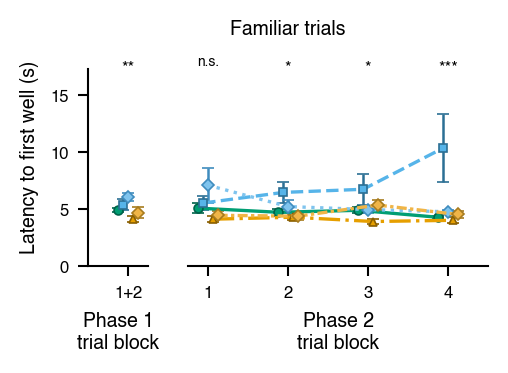

In [39]:
# Preview render: Panel 3F (familiar latency).
# Fixed rect instead of subplots+tight_layout: tight_layout ignores the extra
# axes the P1/Phase-2 split adds and would misalign the two panes.
fig = plt.figure(figsize=(2.5, 1.87 - 0.1))
ax = fig.add_axes([0.15, 0.24, 0.80, 0.62])
panel_accuracy(ax, route='familiar', include_p1=True, group_acc=lat_mean,
               split_p1=True, title='Familiar trials',
               ylabel=LAT_YLABEL, ylim=LAT_YLIM, yticks=LAT_YTICKS, ytick_fmt=None,
               show_legend=False)
panel_f_block_marks(ax)   # per-position one-way-ANOVA marks
plt.show()

Familiar latency (s), median [Q1, Q3] across rats:
                   P1 (1+2)            block 1            block 2            block 3             block 4
group                                                                                                   
PI+VC     4.86 [4.41, 5.18]  4.46 [4.18, 4.78]  4.41 [4.20, 4.90]  4.56 [4.31, 5.33]   4.36 [3.99, 4.53]
PI_PI     5.31 [4.32, 6.23]  5.06 [4.50, 6.60]  6.24 [4.81, 8.39]  6.36 [4.77, 6.59]  7.55 [5.06, 16.94]
PI_PI+VC  5.93 [5.67, 6.22]  5.28 [4.62, 8.70]  4.66 [4.49, 5.12]  4.66 [4.42, 5.58]   4.59 [4.53, 5.06]
VC_VC     4.10 [3.60, 4.63]  4.26 [3.56, 4.62]  4.36 [4.14, 4.70]  3.96 [3.67, 4.27]   3.99 [3.49, 4.29]
VC_PI+VC  4.37 [4.08, 4.73]  4.10 [3.97, 4.53]  4.08 [3.94, 4.62]  5.71 [4.58, 5.96]   4.41 [4.06, 4.69]
marks, mean figure -> median figure: P1 ** -> *, block 1 n.s. -> n.s., block 2 * -> †, block 3 * -> †, block 4 *** -> *


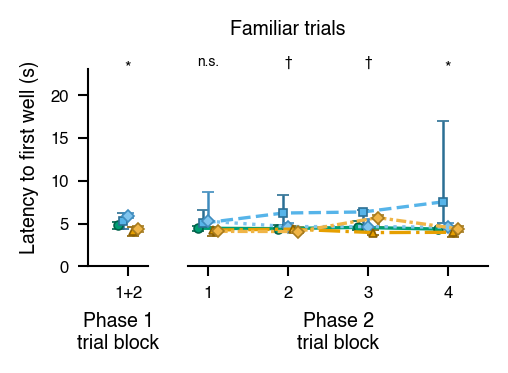

In [40]:
# Median variant of Panel 3F (median figure): median across rats of the per-rat
# familiar latency (lat_med), quartile bars, marks from the Kruskal-Wallis
# companion of each position's one-way ANOVA; y-scale LAT_YLIM_MED.
F_BLOCK_STATS_MED = median_marks(F_BLOCK_STATS)
print('Familiar latency (s), median [Q1, Q3] across rats:')
print(median_table(lat_med, route='familiar').to_string())
print('marks, mean figure -> median figure: ' + marks_summary(F_BLOCK_STATS, F_BLOCK_STATS_MED))
fig = plt.figure(figsize=(2.5, 1.87 - 0.1))
ax = fig.add_axes([0.15, 0.24, 0.80, 0.62])
panel_accuracy(ax, route='familiar', include_p1=True, group_acc=lat_med,
               split_p1=True, title='Familiar trials',
               ylabel=LAT_YLABEL, ylim=LAT_YLIM_MED, yticks=LAT_YTICKS_MED, ytick_fmt=None,
               show_legend=False)
panel_f_block_marks(ax, stats_by_block=F_BLOCK_STATS_MED, ylim=LAT_YLIM_MED)   # rank-based marks
plt.show()


## Statistics — Panel 3G novel-route latency

Assumption checks, then the 4 × 5 mixed ANOVA on novel-route latency (afex Type 3
with Mauchly's test and the `GG_RULE` decision; raw, with log and rank refits — the
group effect only emerges on the log/rank scales), and a grouped training-family
contrast on block-averaged novel
latency (knob `C3G_CONTRAST_GROUPS`, default VC-trained {`VC_VC`, `VC_PI+VC`}
vs the three PI-trained groups). This generalizes the block-1 bracket
statistic (next section) to the whole session.

In [41]:
# Assumption checks for the Panel-3G novel-latency 4x5 mixed ANOVA below.
# Novel blocks hold 4 trials each; complete-case rats are used for the mixed
# ANOVA. Latency is right-skewed: raw within-cell residuals fail Shapiro
# badly, log residuals less so - read conclusions off the log/rank refits.
nov_lat = (rat_lat[(rat_lat['route'] == 'novel') & (rat_lat['x_order'] >= 1)]
           .dropna(subset=['latency_s'])
           [['subject_id', 'group', 'x_order', 'latency_s']].copy())
nov_lat['block'] = nov_lat['x_order'].astype(int)
_nb = nov_lat.groupby('subject_id')['block'].nunique()
_incomplete = _nb[_nb < 4]
nov_lat_c = nov_lat[~nov_lat['subject_id'].isin(_incomplete.index)].copy()
print(f'{nov_lat["subject_id"].nunique()} rats; {len(_incomplete)} dropped for missing '
      f'blocks{": " + str(dict(_incomplete)) if len(_incomplete) else ""}; '
      f'{nov_lat_c["subject_id"].nunique()} complete-case rats')

print('\n=== Normality: Shapiro-Wilk per group x block cell ===')
_rej, _tot = 0, 0
for (_g, _b), _v in nov_lat_c.groupby(['group', 'block'], observed=True)['latency_s']:
    _v = _v.to_numpy(float)
    if len(np.unique(_v)) < 2:
        continue
    _tot += 1
    _rej += stats.shapiro(_v).pvalue < .05
print(f'{_rej}/{_tot} testable cells reject at .05')
_cellm = nov_lat_c.groupby(['group', 'block'], observed=True)['latency_s'].transform('mean')
_sww = stats.shapiro((nov_lat_c['latency_s'] - _cellm).to_numpy())
_lcellm = (nov_lat_c.assign(_l=np.log(nov_lat_c['latency_s']))
           .groupby(['group', 'block'], observed=True)['_l'].transform('mean'))
_swwl = stats.shapiro((np.log(nov_lat_c['latency_s']) - _lcellm).to_numpy())
print(f'within-cell residuals raw: W = {_sww.statistic:.3f}, p = {_sww.pvalue:.4g}; '
      f'log: W = {_swwl.statistic:.3f}, p = {_swwl.pvalue:.4g}')

print('\n=== Homogeneity across groups per block: Brown-Forsythe ===')
for _b in sorted(nov_lat_c['block'].unique()):
    _vals = [nov_lat_c[(nov_lat_c['group'] == _g) & (nov_lat_c['block'] == _b)]
             ['latency_s'].to_numpy(float) for _g in GROUP_ORDER]
    _lv = stats.levene(*_vals, center='median')
    print(f'block {_b}: W = {_lv.statistic:.3f}, p = {_lv.pvalue:.4g}')

41 rats; 0 dropped for missing blocks; 41 complete-case rats

=== Normality: Shapiro-Wilk per group x block cell ===
5/20 testable cells reject at .05
within-cell residuals raw: W = 0.690, p = 3.794e-17; log: W = 0.906, p = 9.855e-09

=== Homogeneity across groups per block: Brown-Forsythe ===
block 1: W = 1.211, p = 0.3231
block 2: W = 2.740, p = 0.04351
block 3: W = 2.754, p = 0.04269
block 4: W = 0.324, p = 0.8601


In [42]:
# Panel 3G: 4x5 mixed ANOVA on novel-route latency (raw + log + rank refits),
# then a grouped training-family contrast on block-averaged novel latency.
# Knob: the contrast groups (their mean vs the mean of the rest).
for _name, _df in [('raw', nov_lat_c.assign(y=nov_lat_c['latency_s'])),
                   ('log', nov_lat_c.assign(y=np.log(nov_lat_c['latency_s']))),
                   ('rank', nov_lat_c.assign(y=nov_lat_c['latency_s'].rank()))]:
    _aovm = mixed_anova_afex(_df, 'y', label=f'3G novel latency [{_name}]')
    print()

C3G_CONTRAST_GROUPS = ['VC_VC', 'VC_PI+VC']   # VC-trained vs the PI-trained rest
avg_nl = nov_lat.groupby(['subject_id', 'group'], observed=True)['latency_s'].mean().reset_index()
print('=== Block-averaged novel latency (s): group descriptives ===')
print(avg_nl.groupby('group', observed=True)['latency_s']
      .agg(['count', 'mean', 'sem', 'median']).round(2).to_string())

_gm = avg_nl.groupby('group', observed=True)['latency_s'].agg(['mean', 'count'])
_dfe = len(avg_nl) - len(_gm)
_mse = sum(((v['latency_s'] - v['latency_s'].mean()) ** 2).sum()
           for _, v in avg_nl.groupby('group', observed=True)) / _dfe
_others = [g for g in _gm.index if g not in C3G_CONTRAST_GROUPS]
_w = {**{g: 1 / len(C3G_CONTRAST_GROUPS) for g in C3G_CONTRAST_GROUPS},
      **{g: -1 / len(_others) for g in _others}}
_psi = sum(wi * _gm.loc[g, 'mean'] for g, wi in _w.items())
_F = _psi ** 2 / (_mse * sum(wi ** 2 / _gm.loc[g, 'count'] for g, wi in _w.items()))
_in = avg_nl['group'].isin(C3G_CONTRAST_GROUPS)
_a = avg_nl.loc[_in, 'latency_s'].to_numpy(float)
_b = avg_nl.loc[~_in, 'latency_s'].to_numpy(float)
_tw = stats.ttest_ind(_a, _b, equal_var=False)
_twl = stats.ttest_ind(np.log(_a), np.log(_b), equal_var=False)
_mw = stats.mannwhitneyu(_a, _b, alternative='two-sided')
_km1 = len(_gm) - 1
print(f'\n=== Grouped contrast: {{{", ".join(C3G_CONTRAST_GROUPS)}}} (n={len(_a)}, '
      f'{_a.mean():.2f} s) vs rest (n={len(_b)}, {_b.mean():.2f} s), '
      f'block-averaged novel latency ===')
print(f'pooled: F(1,{_dfe}) = {_F:.2f}, p = {stats.f.sf(_F, 1, _dfe):.3g}; '
      f'Scheffé p = {stats.f.sf(_F / _km1, _km1, _dfe):.3g}')
print(f'Welch: t({_tw.df:.1f}) = {_tw.statistic:.2f}, p = {_tw.pvalue:.3g}; '
      f'log-Welch p = {_twl.pvalue:.3g}; Mann-Whitney U = {_mw.statistic:.0f}, '
      f'p = {_mw.pvalue:.3g}')
print('NOTE: pooled/Scheffé understate this contrast (pooled MSE is inflated by '
      'the slow, variable PI-trained groups); the Welch/log/rank line is the '
      'faithful one here.')

R callback write-console: Contrasts set to contr.sum for the following variables: group
  


R callback write-console: Contrasts set to contr.sum for the following variables: group
  


=== 3G novel latency [raw]: 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.323, p = 2.199e-07 -> sphericity violated; GG eps = 0.703, HF eps = 0.748
     Source     F df (unc)   p (unc)    df (GG)    p (GG)   np2
      group  2.45    4, 36   0.06385          -         - 0.214
      block 12.23   3, 108 5.958e-07 2.11, 75.9 1.759e-05 0.254
Interaction  1.08  12, 108    0.3807 8.44, 75.9    0.3839 0.108
Reported (GG_RULE = 'mauchly' -> GG df): group F(4, 36) = 2.45, p = .064; block F(2.11, 75.9) = 12.23, p < .001; block × group F(8.44, 75.9) = 1.08, p = .38



R callback write-console: Contrasts set to contr.sum for the following variables: group
  


=== 3G novel latency [log]: 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.666, p = 0.01507 -> sphericity violated; GG eps = 0.796, HF eps = 0.856
     Source     F df (unc)   p (unc)    df (GG)    p (GG)   np2
      group  3.82    4, 36   0.01089          -         - 0.298
      block 25.55   3, 108 1.438e-12 2.39, 86.0 1.862e-10 0.415
Interaction  1.78  12, 108   0.06069 9.55, 86.0   0.07985 0.165
Reported (GG_RULE = 'mauchly' -> GG df): group F(4, 36) = 3.82, p = .011; block F(2.39, 86.0) = 25.55, p < .001; block × group F(9.55, 86.0) = 1.78, p = .080

=== 3G novel latency [rank]: 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.760, p = 0.09051 -> sphericity not rejected; GG eps = 0.834, HF eps = 0.901
     Source     F df (unc)  p (unc)     df (GG)    p (GG)   np2
      group  4.32    4, 36 0.005884           -         - 0.324
      block 28.02   3, 108

## Panel 3G — novel-route latency (per-block marks + preview)

Per-block Welch tests (with log-Welch and Mann–Whitney companions) drive the
significance marks drawn in one row above the blocks: `***`/`**`/`*`
(p < .001/.01/.05), `†` (p < .10), `n.s.`. The old block-1-only vertical
bracket (`panel_g_bracket` + `FIG3G_*` bracket knobs) is superseded but kept
for reverting.

In [43]:
# Block-1 novel latency: PI-trained vs VC-trained (Panel-G bracket statistic).
b1n = (rat_lat[(rat_lat['route'] == 'novel') & (rat_lat['x_order'] == 1)]
       .dropna(subset=['latency_s']).copy())
b1n['group'] = b1n['group'].astype(str)
PI_TRAINED = ['PI+VC', 'PI_PI', 'PI_PI+VC']
VC_TRAINED = ['VC_VC', 'VC_PI+VC']
b1n['training'] = np.where(b1n['group'].isin(PI_TRAINED), 'PI-trained', 'VC-trained')
pi_ = b1n.loc[b1n['training'] == 'PI-trained', 'latency_s'].to_numpy(float)
vc_ = b1n.loc[b1n['training'] == 'VC-trained', 'latency_s'].to_numpy(float)

print('=== Phase-2 block 1, NOVEL route: per-rat latency (s) by group ===')
print(b1n.groupby('group')['latency_s'].agg(['count', 'mean', 'sem', 'median']).reindex(GROUP_ORDER).round(2).to_string())
print('\nby training family:')
print(b1n.groupby('training')['latency_s'].agg(['count', 'mean', 'sem', 'median']).round(2).to_string())

if HAS_PG:
    _aov = pg.anova(data=b1n, dv='latency_s', between='group')
    print(f"\nOne-way ANOVA (5 groups): F({int(_aov['ddof1'].iloc[0])},{int(_aov['ddof2'].iloc[0])}) = "
          f"{float(_aov['F'].iloc[0]):.2f}, p = {float(_aov['p_unc'].iloc[0]):.4g}")
    _tt = pg.ttest(pi_, vc_, correction=True).iloc[0]
    _mw = pg.mwu(pi_, vc_).iloc[0]
    _tl = pg.ttest(np.log(pi_), np.log(vc_), correction=True).iloc[0]
    LAT_B1_STATS = {'t': float(_tt['T']), 'df': float(_tt['dof']), 'p': float(_tt['p_val']),
                    'd': float(_tt['cohen_d']), 'BF10': float(_tt['BF10']),
                    'p_mwu': float(_mw['p_val']), 'p_log': float(_tl['p_val'])}
else:
    from scipy import stats as _stats
    _t = _stats.ttest_ind(pi_, vc_, equal_var=False)
    _mw = _stats.mannwhitneyu(pi_, vc_)
    _tl = _stats.ttest_ind(np.log(pi_), np.log(vc_), equal_var=False)
    _sp = np.sqrt(((len(pi_) - 1) * pi_.var(ddof=1) + (len(vc_) - 1) * vc_.var(ddof=1)) / (len(pi_) + len(vc_) - 2))
    LAT_B1_STATS = {'t': float(_t.statistic), 'df': float(_t.df), 'p': float(_t.pvalue),
                    'd': float((pi_.mean() - vc_.mean()) / _sp), 'BF10': np.nan,
                    'p_mwu': float(_mw.pvalue), 'p_log': float(_tl.pvalue)}
LAT_B1_STATS.update(n_pi=len(pi_), n_vc=len(vc_), mean_pi=float(pi_.mean()), mean_vc=float(vc_.mean()),
                    star=p_to_stars(LAT_B1_STATS['p']))
print(f"\nPlanned contrast, PI-trained (n={LAT_B1_STATS['n_pi']}, {LAT_B1_STATS['mean_pi']:.2f} s) vs "
      f"VC-trained (n={LAT_B1_STATS['n_vc']}, {LAT_B1_STATS['mean_vc']:.2f} s): "
      f"Welch t({LAT_B1_STATS['df']:.1f}) = {LAT_B1_STATS['t']:.2f}, p = {LAT_B1_STATS['p']:.4g}, "
      f"d = {LAT_B1_STATS['d']:.2f}, BF10 = {LAT_B1_STATS['BF10']:.3g} -> bracket '{LAT_B1_STATS['star']}'")
print(f"  Mann-Whitney p = {LAT_B1_STATS['p_mwu']:.4g}; log-latency Welch p = {LAT_B1_STATS['p_log']:.4g}")


# Per-block PI-trained vs VC-trained tests -> the Panel-G per-block marks.
# Welch on raw latency (same test as LAT_B1_STATS) sets the mark; log-Welch
# and Mann-Whitney printed alongside as skew-robust companions.
LAT_BLOCK_STATS = {}
_bn_all = (rat_lat[(rat_lat['route'] == 'novel') & (rat_lat['x_order'] >= 1)]
           .dropna(subset=['latency_s']).copy())
_bn_all['training'] = np.where(_bn_all['group'].astype(str).isin(PI_TRAINED),
                               'PI-trained', 'VC-trained')
print('\n=== Per-block novel latency, PI-trained vs VC-trained ===')
for _b in sorted(_bn_all['x_order'].unique().astype(int)):
    _pi = _bn_all.loc[(_bn_all['x_order'] == _b) & (_bn_all['training'] == 'PI-trained'),
                      'latency_s'].to_numpy(float)
    _vc = _bn_all.loc[(_bn_all['x_order'] == _b) & (_bn_all['training'] == 'VC-trained'),
                      'latency_s'].to_numpy(float)
    _t = stats.ttest_ind(_pi, _vc, equal_var=False)
    _tl = stats.ttest_ind(np.log(_pi), np.log(_vc), equal_var=False)
    _mw = stats.mannwhitneyu(_pi, _vc, alternative='two-sided')
    LAT_BLOCK_STATS[_b] = {'p': float(_t.pvalue), 'p_log': float(_tl.pvalue),
                           'p_mwu': float(_mw.pvalue), 'mark': p_to_marks(float(_t.pvalue)),
                           'mean_pi': float(_pi.mean()), 'mean_vc': float(_vc.mean())}
    _s = LAT_BLOCK_STATS[_b]
    print(f"block {_b}: PI {_s['mean_pi']:5.2f} s vs VC {_s['mean_vc']:5.2f} s | "
          f"Welch p = {_s['p']:.4g} -> '{_s['mark']}' | "
          f"log p = {_s['p_log']:.4g} | MW p = {_s['p_mwu']:.4g}")


def panel_g_bracket(ax, *, lat=lat_mean, block=1,
                    top_groups=PI_TRAINED, bottom_groups=VC_TRAINED,
                    bracket_star=None,
                    bracket_x_pad=0.42, bracket_cap=0.12, bracket_lw=0.8,
                    bracket_star_dx=0.24,
                    main_bar_len=None, little_bar_len=None, bottom_bar_len=None,
                    bracket_y_offset=0.0,
                    little_bar_dx=0.0, little_bar_dy=0.0,
                    bottom_bar_dx=0.0, bottom_bar_dy=0.0,
                    xlim_pad_left=0.4,
                    star_fontsize=STYLE_CFG['star_fontsize']):
    """Mirror image of the Panel-D bracket, hung to the LEFT of `block` with the
    star on the outside (left). Main spine at x = block - bracket_x_pad; the caps
    point right (toward the data). A little bar at the top cap spans the
    PI-trained cluster (top_groups), a little bar at the bottom cap spans the
    VC-trained cluster (bottom_groups); bottom_bar_len=0 gives Panel D's plain cap.
    Lengths are in y-axis units (seconds); None = auto-fit to the block means.
    Star = LAT_B1_STATS (Welch t, PI-trained vs VC-trained)."""
    m = lat[(lat['route'] == 'novel') & (lat['x_order'] == block)].set_index('group')['mean']
    top = m.reindex(list(top_groups)).dropna()
    bot = m.reindex(list(bottom_groups)).dropna()
    y_top = float(top.max())          # top cap: top of the PI cluster
    y_hi_bot = float(top.min())       # bottom of the PI cluster
    y_lo_top = float(bot.max())       # bottom cap: top of the VC cluster
    y_lo_bot = float(bot.min())       # bottom of the VC cluster
    main_len = (y_top - y_lo_top) if main_bar_len is None else main_bar_len
    little_len = (y_top - y_hi_bot) if little_bar_len is None else little_bar_len
    bottom_len = (y_lo_top - y_lo_bot) if bottom_bar_len is None else bottom_bar_len
    y_main_bot = y_top - main_len
    y_top += bracket_y_offset          # slide the whole bracket up (+) / down (-)
    y_main_bot += bracket_y_offset
    xb = block - bracket_x_pad         # main spine (left)
    xc = xb + bracket_cap              # cap ends / little-bar home (toward the data)
    kw = dict(color='0.15', lw=bracket_lw, solid_capstyle='butt', zorder=4, clip_on=False)
    # top cap + little bar (PI cluster); little_bar_dx (+ = right), little_bar_dy (+ = up)
    x_little = xc + little_bar_dx
    yl_top = y_top + little_bar_dy
    yl_bot = yl_top - little_len
    ax.plot([xb, x_little], [y_top, y_top], **kw)                 # top cap
    if little_len > 0:
        ax.plot([x_little, x_little], [yl_bot, yl_top], **kw)     # little bar
        if abs(yl_top - y_top) > 1e-9:
            ax.plot([x_little, x_little], [y_top, yl_top], **kw)  # dy connector
    ax.plot([xb, xb], [y_main_bot, y_top], **kw)                  # main spine
    # bottom cap + bottom bar (VC cluster); bar hangs DOWN from the cap like the top one
    x_bottom = xc + bottom_bar_dx
    yb_top = y_main_bot + bottom_bar_dy
    yb_bot = yb_top - bottom_len
    ax.plot([xb, x_bottom], [y_main_bot, y_main_bot], **kw)       # bottom cap
    if bottom_len > 0:
        ax.plot([x_bottom, x_bottom], [yb_bot, yb_top], **kw)     # bottom bar
        if abs(yb_top - y_main_bot) > 1e-9:
            ax.plot([x_bottom, x_bottom], [y_main_bot, yb_top], **kw)
    star = bracket_star if bracket_star is not None else LAT_B1_STATS['star']
    ax.text(xb - bracket_star_dx, (y_top + y_main_bot) / 2, star, rotation=90,
            ha='center', va='center', fontsize=star_fontsize, zorder=4, clip_on=False)
    # make room on the left (Panel D does the same on the right)
    x0, x1 = ax.get_xlim()
    ax.set_xlim(min(x0, block - 0.5 - xlim_pad_left), x1)
    return ax


# ============================================================================
# Fig 3G significance-bracket knobs (mirror of the Fig 3D set; units = seconds)
#   main bar   -> top of the PI cluster down to the top of the VC cluster (auto ~ 6.1 s)
#   little bar -> PI-cluster spread at the top cap                       (auto ~ 0.5 s)
#   bottom bar -> VC-cluster spread at the bottom cap                    (auto ~ 0.6 s; 0 = plain cap)
# Both little bars hang DOWN from their cap; *_DY = +up shifts them (LEN/2 centres a bar on its cap).
# ============================================================================
FIG3G_MAIN_BAR_LEN = None        # None = auto (PI-cluster top to VC-cluster top)
FIG3G_LITTLE_BAR_LEN = 3.0
FIG3G_BOTTOM_BAR_LEN = 2.0
FIG3G_BAR_YOFFSET = 0.0          # slide the whole bracket up (+) / down (-)
FIG3G_LITTLE_BAR_DX = 0.0        # move the top little bar left (-) / right (+)
FIG3G_LITTLE_BAR_DY = 1.5        # move the top little bar down (-) / up (+); LEN/2 centres it on the cap
FIG3G_BOTTOM_BAR_DX = 0.0
FIG3G_BOTTOM_BAR_DY = 1.0
FIG3G_XPAD_LEFT = 0.0            # bracket x-room; 0 now that per-block marks replace the
                                 # bracket (restore 0.25 if reverting to panel_g_bracket)
FIG3G_BRACKET_CAP = 0.06         # cap length, spine -> little bars (x units; Panel D uses 0.12)
FIG3G_BRACKET_X_PAD = 0.29       # spine distance left of block 1 (x units; Panel D uses 0.42)
FIG3G_STAR_DX = 0.20             # star distance left of the spine (x units; Panel D uses 0.24)

FIG3G_BRACKET_KW = dict(main_bar_len=FIG3G_MAIN_BAR_LEN, little_bar_len=FIG3G_LITTLE_BAR_LEN,
                        bottom_bar_len=FIG3G_BOTTOM_BAR_LEN, bracket_y_offset=FIG3G_BAR_YOFFSET,
                        little_bar_dx=FIG3G_LITTLE_BAR_DX, little_bar_dy=FIG3G_LITTLE_BAR_DY,
                        bottom_bar_dx=FIG3G_BOTTOM_BAR_DX, bottom_bar_dy=FIG3G_BOTTOM_BAR_DY,
                        xlim_pad_left=FIG3G_XPAD_LEFT, bracket_cap=FIG3G_BRACKET_CAP,
                        bracket_x_pad=FIG3G_BRACKET_X_PAD, bracket_star_dx=FIG3G_STAR_DX)



# ============================================================================
# Fig 3G per-block mark knobs (the marks supersede the bracket above)
# ============================================================================
FIG3G_MARK_Y = None              # fixed data-y override (None = MARK_FRAC row)
FIG3G_MARK_FONTSIZE = STYLE_CFG['star_fontsize']
FIG3G_MARK_NS_FONTSIZE = 5       # for 'n.s.' and the dagger


def panel_g_block_marks(ax, *, stats_by_block=None, y=None, ylim=None):
    """One row of per-block significance marks (LAT_BLOCK_STATS: Welch,
    PI-trained vs VC-trained within each block) at MARK_FRAC of the axes
    height (uniform across panels; override with `y` / FIG3G_MARK_Y).
    Supersedes the block-1 `panel_g_bracket`."""
    sb = LAT_BLOCK_STATS if stats_by_block is None else stats_by_block
    y_fix = FIG3G_MARK_Y if y is None else y
    _ylim = LAT_YLIM if ylim is None else ylim   # the median figure passes its own scale
    y_row = mark_row_y(*_ylim) if y_fix is None else y_fix
    for b, s in sb.items():
        is_star = s['mark'] not in ('n.s.', '\u2020')
        draw_mark(ax, b, y_row, s['mark'],
                  FIG3G_MARK_FONTSIZE if is_star else FIG3G_MARK_NS_FONTSIZE)
    trim_left_spine(ax, _ylim)
    return ax

=== Phase-2 block 1, NOVEL route: per-rat latency (s) by group ===
          count   mean   sem  median
group                               
PI+VC        17  13.01  1.35   12.09
PI_PI         6  12.91  2.45   13.27
PI_PI+VC      6  12.52  3.24    9.09
VC_VC         6   6.88  1.75    5.23
VC_PI+VC      6   6.27  0.67    5.82

by training family:
            count   mean  sem  median
training                             
PI-trained     29  12.89  1.1   12.09
VC-trained     12   6.57  0.9    5.35

One-way ANOVA (5 groups): F(4,36) = 2.80, p = 0.04004

Planned contrast, PI-trained (n=29, 12.89 s) vs VC-trained (n=12, 6.57 s): Welch t(36.6) = 4.44, p = 8.046e-05, d = 1.19, BF10 = 273 -> bracket '***'
  Mann-Whitney p = 0.0002314; log-latency Welch p = 5.712e-05

=== Per-block novel latency, PI-trained vs VC-trained ===
block 1: PI 12.89 s vs VC  6.57 s | Welch p = 8.046e-05 -> '***' | log p = 5.712e-05 | MW p = 0.0002314
block 2: PI  7.67 s vs VC  4.68 s | Welch p = 2.449e-05 -> '***' | log

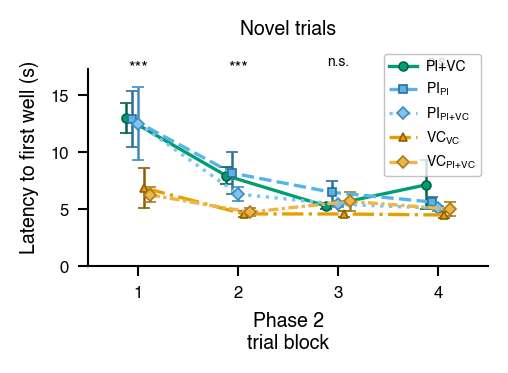

In [44]:
# Preview render: Panel 3G (novel latency) with the per-block marks.
fig = plt.figure(figsize=(2.5, 1.87 - 0.1))
ax = fig.add_axes([0.17, 0.24, 0.80, 0.62])
panel_accuracy(ax, route='novel', include_p1=False, group_acc=lat_mean,
               title='Novel trials', xlabel='Phase 2\ntrial block',
               ylabel=LAT_YLABEL, ylim=LAT_YLIM, yticks=LAT_YTICKS, ytick_fmt=None,
               show_legend=True, legend_loc='upper right', legend_fontsize=5, legend_frameon=True)
panel_g_block_marks(ax)   # per-block PI- vs VC-trained marks (supersedes the bracket)
plt.show()

Novel latency (s), median [Q1, Q3] across rats:
                      block 1            block 2            block 3            block 4
group                                                                                 
PI+VC     12.09 [8.62, 18.09]  7.17 [5.01, 9.88]  4.90 [4.62, 5.75]  4.85 [4.37, 5.63]
PI_PI     13.27 [9.64, 16.15]  6.70 [5.88, 8.19]  5.81 [5.07, 7.66]  5.54 [5.21, 5.83]
PI_PI+VC   9.09 [8.50, 14.20]  5.85 [5.42, 6.49]  5.31 [5.12, 5.46]  5.10 [4.69, 5.53]
VC_VC       5.23 [5.03, 5.38]  4.53 [4.12, 4.89]  4.54 [4.26, 4.58]  4.39 [4.22, 4.89]
VC_PI+VC    5.82 [4.97, 7.27]  4.56 [4.20, 4.72]  4.89 [4.11, 7.12]  4.26 [4.09, 5.38]
marks, mean figure -> median figure: block 1 *** -> ***, block 2 *** -> ***, block 3 n.s. -> †, block 4 n.s. -> †


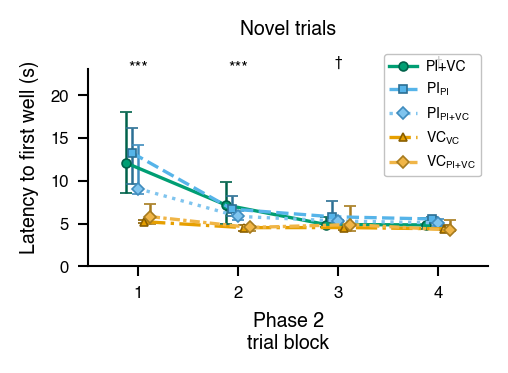

In [45]:
# Median variant of Panel 3G (median figure): median across rats of the per-rat
# novel latency (lat_med), quartile bars, marks from the Mann-Whitney companion
# of the per-block PI-trained vs VC-trained test; y-scale LAT_YLIM_MED.
LAT_BLOCK_STATS_MED = median_marks(LAT_BLOCK_STATS)
print('Novel latency (s), median [Q1, Q3] across rats:')
print(median_table(lat_med, route='novel').to_string())
print('marks, mean figure -> median figure: ' + marks_summary(LAT_BLOCK_STATS, LAT_BLOCK_STATS_MED))
fig = plt.figure(figsize=(2.5, 1.87 - 0.1))
ax = fig.add_axes([0.17, 0.24, 0.80, 0.62])
panel_accuracy(ax, route='novel', include_p1=False, group_acc=lat_med,
               title='Novel trials', xlabel='Phase 2\ntrial block',
               ylabel=LAT_YLABEL, ylim=LAT_YLIM_MED, yticks=LAT_YTICKS_MED, ytick_fmt=None,
               show_legend=True, legend_loc='upper right', legend_fontsize=5, legend_frameon=True)
panel_g_block_marks(ax, stats_by_block=LAT_BLOCK_STATS_MED, ylim=LAT_YLIM_MED)   # rank-based marks
plt.show()


## Statistics — Panel 3H Novel − Familiar latency difference

Per-rat paired difference of the block means behind Panels F and G: novel − familiar latency
to the first well within each rat × Phase-2 block (seconds; positive = slower on the novel
route). Assumption checks first (per-cell normality, mixed-model residuals, Brown–Forsythe per
block), then the 4 × 5 mixed ANOVA on the difference (afex Type 3; Mauchly rejects, so the
reported df are Greenhouse–Geisser corrected under `GG_RULE = 'mauchly'`; raw, with a log-ratio refit —
log novel − log familiar, the skew-robust version of the same comparison — and a rank refit),
and the grouped training-family contrast on the block-averaged difference (knob
`C3H_CONTRAST_GROUPS`, default VC-trained {`VC_VC`, `VC_PI+VC`} vs the three PI-trained groups,
as for Panel G).


In [46]:
# Assumption checks for the Panel-3H novel - familiar latency 4x5 mixed ANOVA below.
# DV = per-rat (novel - familiar) latency per Phase-2 block, from the per-rat
# block means in rat_lat (novel: 4 trials, familiar: 2 trials per block). A rat
# needs both routes in a block for a difference; complete-case rats are used for
# the mixed ANOVA (the completeness check prints who drops). Latency is
# right-skewed, so the raw difference inherits heavy tails: the log-ratio
# (log novel - log familiar) and rank refits in the next cell are the
# robustness companions.
def per_rat_lat_diff(rat_lat: pd.DataFrame) -> pd.DataFrame:
    '''Return per-rat x block: novel - familiar latency (s), plus the log-ratio.'''
    p2 = rat_lat[rat_lat['x_order'] >= 1].copy()
    wide = p2.pivot_table(
        index=['subject_id', 'group', 'x_order'],
        columns='route', values='latency_s', observed=True,
    ).reset_index()
    wide['diff'] = wide['novel'] - wide['familiar']
    wide['log_ratio'] = np.log(wide['novel']) - np.log(wide['familiar'])
    return wide

rat_lat_diff = per_rat_lat_diff(rat_lat).dropna(subset=['diff']).copy()
rat_lat_diff['block'] = rat_lat_diff['x_order'].astype(int)
grp_lat_diff = (
    rat_lat_diff.groupby(['group', 'x_order'], observed=True)['diff']
    .agg(['mean', 'sem', 'count']).reset_index()
    .rename(columns={'count': 'n'})
)
_nb = rat_lat_diff.groupby('subject_id')['block'].nunique()
_incomplete = _nb[_nb < 4]
rat_lat_diff_c = rat_lat_diff[~rat_lat_diff['subject_id'].isin(_incomplete.index)].copy()
print(f'{rat_lat_diff["subject_id"].nunique()} rats; {len(_incomplete)} dropped for missing '
      f'blocks{": " + str(dict(_incomplete)) if len(_incomplete) else ""}; '
      f'{rat_lat_diff_c["subject_id"].nunique()} complete-case rats')

print('\nGroup mean novel − familiar latency (s) per Phase-2 block:')
print(grp_lat_diff.pivot(index='group', columns='x_order', values='mean').round(2).to_string())

print('\n=== Normality: Shapiro-Wilk per group x block cell ===')
_rej, _tot = 0, 0
for (_g, _b), _v in rat_lat_diff_c.groupby(['group', 'block'], observed=True)['diff']:
    _v = _v.to_numpy(float)
    if len(np.unique(_v)) < 2:
        continue
    _tot += 1
    _rej += stats.shapiro(_v).pvalue < .05
print(f'{_rej}/{_tot} testable cells reject at .05')
_cellm = rat_lat_diff_c.groupby(['group', 'block'], observed=True)['diff'].transform('mean')
_sww = stats.shapiro((rat_lat_diff_c['diff'] - _cellm).to_numpy())
_lcellm = rat_lat_diff_c.groupby(['group', 'block'], observed=True)['log_ratio'].transform('mean')
_swwl = stats.shapiro((rat_lat_diff_c['log_ratio'] - _lcellm).to_numpy())
_submeans = rat_lat_diff_c.groupby(['subject_id', 'group'], observed=True)['diff'].mean()
_swb = stats.shapiro(
    (_submeans - _submeans.groupby('group', observed=True).transform('mean')).to_numpy())
print(f'within-cell residuals raw: W = {_sww.statistic:.3f}, p = {_sww.pvalue:.4g}; '
      f'log-ratio: W = {_swwl.statistic:.3f}, p = {_swwl.pvalue:.4g}')
print(f'between-subject residuals: W = {_swb.statistic:.3f}, p = {_swb.pvalue:.4g}')

print('\n=== Homogeneity across groups per block: Brown-Forsythe ===')
for _b in sorted(rat_lat_diff_c['block'].unique()):
    _vals = [rat_lat_diff_c[(rat_lat_diff_c['group'] == _g) & (rat_lat_diff_c['block'] == _b)]
             ['diff'].to_numpy(float) for _g in GROUP_ORDER]
    _lv = stats.levene(*_vals, center='median')
    print(f'block {_b}: W = {_lv.statistic:.3f}, p = {_lv.pvalue:.4g}')


41 rats; 0 dropped for missing blocks; 41 complete-case rats

Group mean novel − familiar latency (s) per Phase-2 block:
x_order      1     2     3     4
group                           
PI+VC     7.90  3.21  0.38  2.84
PI_PI     7.35  1.70 -0.27 -4.73
PI_PI+VC  5.41  1.10  0.47  0.31
VC_PI+VC  1.79  0.35  0.32  0.47
VC_VC     2.74  0.29  0.66  0.46

=== Normality: Shapiro-Wilk per group x block cell ===
5/20 testable cells reject at .05
within-cell residuals raw: W = 0.702, p = 7.832e-17; log-ratio: W = 0.914, p = 2.854e-08
between-subject residuals: W = 0.818, p = 1.342e-05

=== Homogeneity across groups per block: Brown-Forsythe ===
block 1: W = 0.951, p = 0.4458
block 2: W = 3.338, p = 0.02008
block 3: W = 1.722, p = 0.1666
block 4: W = 0.725, p = 0.5808


In [47]:
# Panel 3H: 4x5 mixed ANOVA on the novel - familiar latency difference (raw +
# log-ratio + rank refits), then a grouped training-family contrast on the
# block-averaged difference. Knob: the contrast groups (their mean vs the mean
# of the rest), the same split as Panel G.
# Manuscript test (Results, Panel H), afex Type 3 on the raw difference. Mauchly
# rejects strongly (W = .28, p < .001; eps = .63) -> Greenhouse-Geisser df under
# GG_RULE = 'mauchly': block F(1.90, 68.4) = 12.46, p < .001; group F(4, 36) = 2.65,
# p = .049; block x group F(7.60, 68.4) = 1.72, p = .11 (not significant after
# correction; the per-block Welch comparisons below are separate planned tests).
for _name, _df in [('raw', rat_lat_diff_c.assign(y=rat_lat_diff_c['diff'])),
                   ('log-ratio', rat_lat_diff_c.assign(y=rat_lat_diff_c['log_ratio'])),
                   ('rank', rat_lat_diff_c.assign(y=rat_lat_diff_c['diff'].rank()))]:
    _aovm = mixed_anova_afex(_df, 'y', label=f'3H novel − familiar latency [{_name}]')
    print()

C3H_CONTRAST_GROUPS = ['VC_VC', 'VC_PI+VC']   # VC-trained vs the PI-trained rest
avg_ld = (rat_lat_diff.groupby(['subject_id', 'group'], observed=True)[['diff', 'log_ratio']]
          .mean().reset_index())
print('=== Block-averaged novel − familiar latency (s): group descriptives ===')
print(avg_ld.groupby('group', observed=True)['diff']
      .agg(['count', 'mean', 'sem', 'median']).round(2).to_string())

_gm = avg_ld.groupby('group', observed=True)['diff'].agg(['mean', 'count'])
_dfe = len(avg_ld) - len(_gm)
_mse = sum(((v['diff'] - v['diff'].mean()) ** 2).sum()
           for _, v in avg_ld.groupby('group', observed=True)) / _dfe
_others = [g for g in _gm.index if g not in C3H_CONTRAST_GROUPS]
_w = {**{g: 1 / len(C3H_CONTRAST_GROUPS) for g in C3H_CONTRAST_GROUPS},
      **{g: -1 / len(_others) for g in _others}}
_psi = sum(wi * _gm.loc[g, 'mean'] for g, wi in _w.items())
_F = _psi ** 2 / (_mse * sum(wi ** 2 / _gm.loc[g, 'count'] for g, wi in _w.items()))
_in = avg_ld['group'].isin(C3H_CONTRAST_GROUPS)
_a = avg_ld.loc[_in, 'diff'].to_numpy(float)
_b = avg_ld.loc[~_in, 'diff'].to_numpy(float)
_tw = stats.ttest_ind(_a, _b, equal_var=False)
_twl = stats.ttest_ind(avg_ld.loc[_in, 'log_ratio'].to_numpy(float),
                       avg_ld.loc[~_in, 'log_ratio'].to_numpy(float), equal_var=False)
_mw = stats.mannwhitneyu(_a, _b, alternative='two-sided')
_km1 = len(_gm) - 1
print(f'\n=== Grouped contrast: {{{", ".join(C3H_CONTRAST_GROUPS)}}} (n={len(_a)}, '
      f'{_a.mean():+.2f} s) vs rest (n={len(_b)}, {_b.mean():+.2f} s), '
      f'block-averaged novel − familiar latency ===')
print(f'pooled: F(1,{_dfe}) = {_F:.2f}, p = {stats.f.sf(_F, 1, _dfe):.3g}; '
      f'Scheffé p = {stats.f.sf(_F / _km1, _km1, _dfe):.3g}')
print(f'Welch: t({_tw.df:.1f}) = {_tw.statistic:.2f}, p = {_tw.pvalue:.3g}; '
      f'log-ratio Welch p = {_twl.pvalue:.3g}; Mann-Whitney U = {_mw.statistic:.0f}, '
      f'p = {_mw.pvalue:.3g}')
print('NOTE: pooled/Scheffé understate this contrast (pooled MSE is inflated by '
      'the variable PI-trained groups, PI+VC in particular); the Welch/log-ratio/'
      'Mann-Whitney line is the faithful one here, as for Panel G.')


R callback write-console: Contrasts set to contr.sum for the following variables: group
  


=== 3H novel − familiar latency [raw]: 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.278, p = 1.961e-08 -> sphericity violated; GG eps = 0.634, HF eps = 0.668
     Source     F df (unc)   p (unc)    df (GG)    p (GG)   np2
      group  2.65    4, 36   0.04919          -         - 0.227
      block 12.47   3, 108 4.586e-07 1.90, 68.4 3.294e-05 0.257
Interaction  1.72  12, 108   0.07173 7.60, 68.4    0.1125 0.161
Reported (GG_RULE = 'mauchly' -> GG df): group F(4, 36) = 2.65, p = .049; block F(1.90, 68.4) = 12.47, p < .001; block × group F(7.60, 68.4) = 1.72, p = .11



R callback write-console: Contrasts set to contr.sum for the following variables: group
  


R callback write-console: Contrasts set to contr.sum for the following variables: group
  


R callback write-console: In addition:   


R callback write-console: Warning message:
  


R callback write-console: In summary.Anova.mlm(object$Anova, multivariate = FALSE) :  


R callback write-console: 
   


R callback write-console:  HF eps > 1 treated as 1
  


=== 3H novel − familiar latency [log-ratio]: 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.773, p = 0.1122 -> sphericity not rejected; GG eps = 0.869, HF eps = 0.943
     Source     F df (unc)   p (unc)     df (GG)    p (GG)   np2
      group  4.19    4, 36  0.006907           -         - 0.318
      block 23.21   3, 108 1.135e-11  2.61, 93.9 1.959e-10 0.392
Interaction  2.29  12, 108   0.01241 10.43, 93.9   0.01758 0.203
Reported (GG_RULE = 'mauchly' -> uncorrected df): group F(4, 36) = 4.19, p = .007; block F(3, 108) = 23.21, p < .001; block × group F(12, 108) = 2.29, p = .012

=== 3H novel − familiar latency [rank]: 4 x 5 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.887, p = 0.5276 -> sphericity not rejected; GG eps = 0.921, HF eps = 1.006
     Source     F df (unc)   p (unc)     df (GG)    p (GG)   np2
      group  4.15    4, 36  0.007279           -     

## Panel 3H — Novel − Familiar latency difference (per-block marks + preview)

Positive values = slower to the first well on novel than on familiar trials. Errorbars = SEM
of the per-rat paired difference (`novel − familiar` within each rat × block). Per-block Welch
tests, VC-trained (VC_VC, VC_PI+VC) vs PI-trained (PI+VC, PI_PI, PI_PI+VC), drive one row of
significance marks above the blocks (`***`/`**`/`*`/`†`/`n.s.`), with log-ratio Welch and
Mann–Whitney companions printed — the same test family as Panel G's marks. Drawn with Panel D's
`panel_d_difference` (dotted line = 0 s, no difference); knobs `FIG3H_*`.


In [48]:
# Per-block VC-trained vs PI-trained tests on the novel - familiar latency
# difference -> the Panel-H per-block marks. Welch on the raw difference sets
# the mark (same test as Panel G's LAT_BLOCK_STATS); the log-ratio Welch and
# Mann-Whitney are the skew-robust companions.
LAT_DIFF_BLOCK_STATS = {}
_in_vc = rat_lat_diff['group'].astype(str).isin(C3H_CONTRAST_GROUPS)
print('=== Per-block novel − familiar latency, PI-trained vs VC-trained ===')
for _b in sorted(rat_lat_diff['block'].unique()):
    _m = rat_lat_diff['block'] == _b
    _pi = rat_lat_diff.loc[_m & ~_in_vc, 'diff'].to_numpy(float)
    _vc = rat_lat_diff.loc[_m & _in_vc, 'diff'].to_numpy(float)
    _t = stats.ttest_ind(_pi, _vc, equal_var=False)
    _tl = stats.ttest_ind(rat_lat_diff.loc[_m & ~_in_vc, 'log_ratio'].to_numpy(float),
                          rat_lat_diff.loc[_m & _in_vc, 'log_ratio'].to_numpy(float),
                          equal_var=False)
    _mw = stats.mannwhitneyu(_pi, _vc, alternative='two-sided')
    LAT_DIFF_BLOCK_STATS[int(_b)] = {
        't': float(_t.statistic), 'df': float(_t.df), 'p': float(_t.pvalue),
        'p_log': float(_tl.pvalue), 'p_mwu': float(_mw.pvalue),
        'mark': p_to_marks(float(_t.pvalue)),
        'mean_pi': float(_pi.mean()), 'mean_vc': float(_vc.mean())}
    _s = LAT_DIFF_BLOCK_STATS[int(_b)]
    print(f"block {int(_b)}: PI {_s['mean_pi']:+5.2f} s vs VC {_s['mean_vc']:+5.2f} s | "
          f"Welch t({_s['df']:.1f}) = {_s['t']:.2f}, p = {_s['p']:.4g} -> '{_s['mark']}' | "
          f"log-ratio p = {_s['p_log']:.4g} | MW p = {_s['p_mwu']:.4g}")


# ============================================================================
# Fig 3H knobs (y-scale in seconds; one marks row above the blocks, like D/G)
# ============================================================================
FIG3H_YTICKS = (-10, -5, 0, 5, 10)      # 5 s tick step, as on the F/G latency axis
FIG3H_YLIM = ylim_for(-10, 10)          # top tick 10 s at TOP_TICK_FRAC (uniform); ymin clears PI_PI's block-4 error bar
FIG3H_YLABEL = 'Novel − familiar (s)'   # one line: the shared left pad (0.44 in) clears a single-line y-label only
FIG3H_YLABEL_PAD = 0.5                  # pt; sits the label ~4.8 pt from the "−5"/"5"/"10" numbers (ignoring the wider "−10" row), as D does against its "−.75" rows
FIG3H_SHOW_ZERO = True                  # dotted line at 0 s (novel = familiar), like the chance lines in C/E
FIG3H_MARK_Y = None                     # fixed data-y override (None = MARK_FRAC row)
FIG3H_MARK_FONTSIZE = STYLE_CFG['star_fontsize']
FIG3H_MARK_NS_FONTSIZE = 5


def panel_h_latency_difference(ax, *, grp_diff=None, ylim=None, yticks=FIG3H_YTICKS,
                               ylabel=FIG3H_YLABEL, ylabel_pad=FIG3H_YLABEL_PAD,
                               show_zero=FIG3H_SHOW_ZERO,
                               axhline_lw=STYLE_CFG['axhline_lw'], **kw):
    """Panel H: novel - familiar latency to the first well per Phase-2 block,
    group mean ± SEM of the per-rat paired difference (Panel D's drawing code
    on grp_lat_diff; dotted line = 0 s, no difference)."""
    if ylim is None:
        ylim = FIG3H_YLIM
    if show_zero:
        ax.axhline(0.0, lw=axhline_lw, ls=':', color='0.5', zorder=0)
    return panel_d_difference(ax, grp_diff=grp_lat_diff if grp_diff is None else grp_diff,
                              ylim=ylim, yticks=yticks, ytick_fmt=None,
                              ylabel=ylabel, ylabel_pad=ylabel_pad, **kw)


def panel_h_block_marks(ax, *, stats_by_block=None, y=None, ylim=None):
    """One row of per-block significance marks (LAT_DIFF_BLOCK_STATS: Welch,
    PI-trained vs VC-trained on the novel - familiar latency difference within
    each block) at MARK_FRAC of the axes height (uniform across panels;
    override with `y` / FIG3H_MARK_Y)."""
    sb = LAT_DIFF_BLOCK_STATS if stats_by_block is None else stats_by_block
    y_fix = FIG3H_MARK_Y if y is None else y
    _ylim = FIG3H_YLIM if ylim is None else ylim   # the median figure passes its own scale
    y_row = mark_row_y(*_ylim) if y_fix is None else y_fix
    for b, s in sb.items():
        is_star = s['mark'] not in ('n.s.', '\u2020')
        draw_mark(ax, b, y_row, s['mark'],
                  FIG3H_MARK_FONTSIZE if is_star else FIG3H_MARK_NS_FONTSIZE)
    trim_left_spine(ax, _ylim)
    return ax


=== Per-block novel − familiar latency, PI-trained vs VC-trained ===
block 1: PI +7.27 s vs VC +2.26 s | Welch t(33.8) = 3.98, p = 0.0003417 -> '***' | log-ratio p = 0.001663 | MW p = 0.0005549
block 2: PI +2.46 s vs VC +0.32 s | Welch t(30.1) = 4.01, p = 0.0003644 -> '***' | log-ratio p = 0.0002493 | MW p = 0.002751
block 3: PI +0.26 s vs VC +0.49 s | Welch t(27.1) = -0.48, p = 0.6385 -> 'n.s.' | log-ratio p = 0.7616 | MW p = 0.8298
block 4: PI +0.75 s vs VC +0.46 s | Welch t(30.4) = 0.20, p = 0.8464 -> 'n.s.' | log-ratio p = 0.9501 | MW p = 0.3091


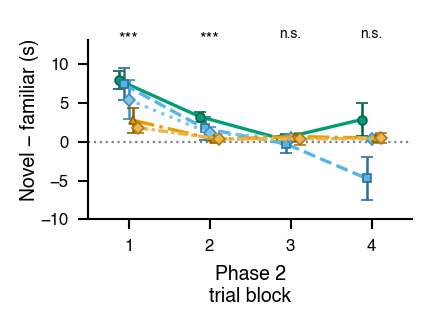

In [49]:
# Preview render: Panel 3H (novel − familiar latency), same rect as the Panel D preview
fig, ax = plt.subplots(figsize=(2.2, 1.87 - 0.2))
panel_h_latency_difference(ax)
panel_h_block_marks(ax)   # per-block PI- vs VC-trained marks
fig.tight_layout()
plt.show()


Novel − familiar latency (s), median [Q1, Q3] across rats:
                     block 1             block 2             block 3               block 4
group                                                                                     
PI+VC     6.68 [3.79, 12.11]   2.85 [0.62, 5.28]   0.53 [0.23, 0.92]     0.39 [0.34, 0.93]
PI_PI      8.02 [4.62, 9.98]  0.42 [-0.63, 3.08]  0.09 [-1.14, 0.63]  -2.25 [-9.73, -0.20]
PI_PI+VC   3.58 [2.58, 4.45]   0.80 [0.63, 1.85]  0.50 [-0.27, 0.63]    0.29 [-0.12, 0.75]
VC_VC      1.29 [0.80, 1.84]   0.40 [0.07, 0.50]   0.62 [0.27, 0.91]     0.22 [0.15, 0.40]
VC_PI+VC   1.47 [0.81, 2.03]   0.38 [0.23, 0.50]  0.15 [-1.04, 1.58]    0.04 [-0.12, 0.15]
marks, mean figure -> median figure: block 1 *** -> ***, block 2 *** -> **, block 3 n.s. -> n.s., block 4 n.s. -> n.s.


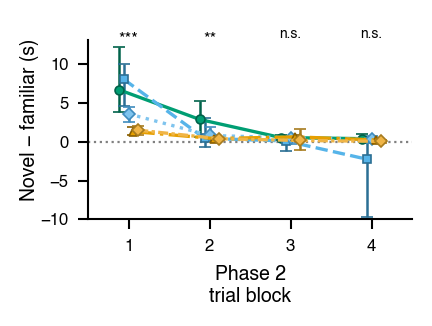

In [50]:
# Median variant of Panel 3H (median figure): median across rats of the per-rat
# novel - familiar latency difference, quartile bars, marks from the
# Mann-Whitney companion of the per-block PI-trained vs VC-trained test.
grp_lat_diff_med = median_quartiles(rat_lat_diff, 'diff', keys=('group', 'x_order'))
LAT_DIFF_BLOCK_STATS_MED = median_marks(LAT_DIFF_BLOCK_STATS)
print('Novel − familiar latency (s), median [Q1, Q3] across rats:')
print(median_table(grp_lat_diff_med).to_string())
print('marks, mean figure -> median figure: ' + marks_summary(LAT_DIFF_BLOCK_STATS, LAT_DIFF_BLOCK_STATS_MED))
fig, ax = plt.subplots(figsize=(2.2, 1.87 - 0.2))
panel_h_latency_difference(ax, grp_diff=grp_lat_diff_med)
panel_h_block_marks(ax, stats_by_block=LAT_DIFF_BLOCK_STATS_MED)   # rank-based marks
fig.tight_layout()
plt.show()


## Compose Figure 3 — two rows, 7.5 × 3.74 in, uniform block spacing

Row 1 = A | B | C | D, row 2 = E | F | G | H. Panel A keeps one third of the page width on row 1
(`A_W`; the schematic is now height-limited by its row, so it renders a little smaller than in
the single-row figure) and E sits beneath it at its own width, centred under the A column (`E_X`: the centred value by
default; None = its right edge the same gap from F as F | G | H are from each other, 0.0 = flush left,
or a page fraction to place it by hand).
Right of the A/E column, B | C | D and F | G | H share the strip. **Block spacing is identical
in every panel**: one `UNIT` (inches per data x-unit, set by the tighter row filling the
right-hand strip) sizes each panel box as its x-span × `UNIT` plus the shared pads; row slack
becomes equal inter-panel gaps, and F/G/H fall directly under B/C/D because the x-spans match.
Vertical pads are in page fractions of the 3.74 in page (the single-row values / `N_ROWS`).
Panel A is rasterized inline and replaced by the vector schematic in the exported SVG (next cell).

`compose_extended(V)` draws either variant with this one layout: `VARIANT_MEAN` (group mean ± SEM,
the parametric marks) → `figure3`, `VARIANT_MEDIAN` (group median [Q1, Q3], the
rank-based marks, latency scale `LAT_YLIM_MED`) → `figure3_median`. A variant
names each data panel's aggregate (`data`), the stats dict whose `mark` field is drawn (`marks`),
its y-limits (`ylim`; F/G also `yticks`) and the output stem. Every layout knob is shared, so the
two SVGs differ only in data, marks and the latency y-scale.


block spacing: 0.252 in per x-unit in every panel


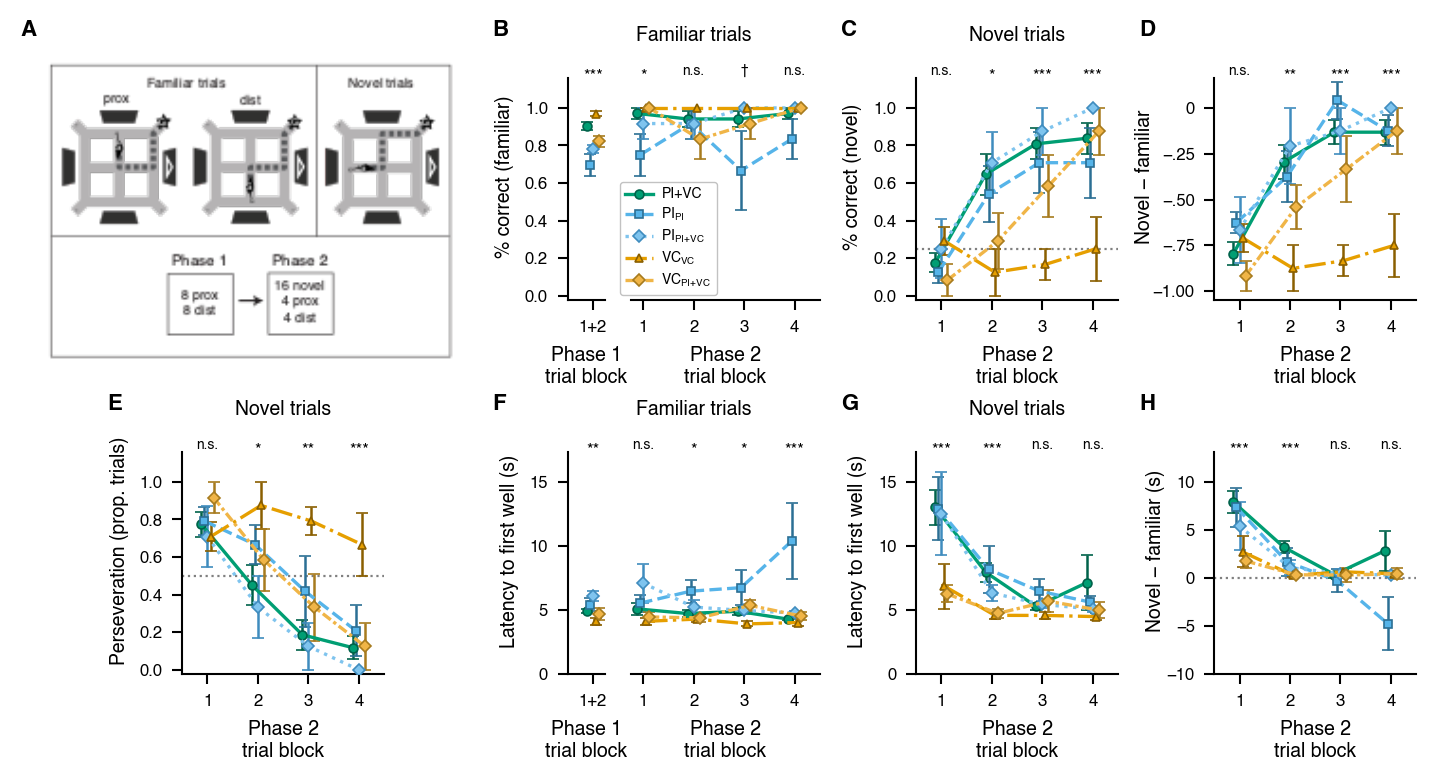

In [51]:
# Compose the two-row figure; export_composed_svg (next cell) splices the vector Panel A into the SVG.
import matplotlib.image as mpimg

page_w = 180 / 25.4   # Wiley full-page canvas: 180 mm = 7.087 in (was 7.5 in = 190.5 mm)
row_h = 1.87                      # one row = figure2 row height
N_ROWS = 2                        # row 1: A B C D; row 2: E F G H (E under A)
page_h = row_h * N_ROWS
ROW = 1.0 / N_ROWS

# Panel rectangles in figure fractions: [left, bottom, width, height]
# --- Uniform block spacing across every plot panel ---------------------------
# Panel A keeps its previous width (A_W) on row 1 and Panel E takes the column
# beneath it. The plot panels share one UNIT (page fraction per data x-unit), so
# a trial block is the same width in inches everywhere. Panel box widths follow
# their x-spans (data units, including any bracket x-room):
X_SPAN = {
    'B': 5.0, 'F': 5.0,                    # P1 pane + break + blocks 1-4 (xlim -0.5..4.5)
    'C': 4.0, 'E': 4.0, 'H': 4.0,          # blocks 1-4 (xlim 0.5..4.5)
    'D': 4.0,                              # bracket x-room removed (per-block marks now)
    'G': 4.0 + FIG3G_XPAD_LEFT,            # + left x-room for the Panel-G bracket (0 with marks)
}
PAD_L, PAD_R = 0.058, 0.01                 # horizontal pads, page fractions (0.44 / 0.075 in)
A_W = 1.0 / 3.0                            # Panel A / E column width (one third)
PANEL_ROWS = [(['B', 'C', 'D'], 1 * ROW),  # top row, right of A
              (['F', 'G', 'H'], 0 * ROW)]  # bottom row, right of E
_avail = 1.0 - A_W
UNIT = min((_avail - len(r) * (PAD_L + PAD_R)) / sum(X_SPAN[k] for k in r)
           for r, _ in PANEL_ROWS)         # the tighter row fills its strip exactly

def _w(k):
    return X_SPAN[k] * UNIT + PAD_L + PAD_R

positions = {'A': [0.0, 1 * ROW, A_W, ROW]}          # row 1, left column
ROW_GAP = {}                                          # row y -> box gap between its strip panels
for _names, _y in PANEL_ROWS:
    _gap = (_avail - sum(_w(k) for k in _names)) / (len(_names) - 1)   # row slack -> equal gaps
    ROW_GAP[_y] = _gap
    _x = A_W
    for _k in _names:
        positions[_k] = [_x, _y, _w(_k), ROW]
        _x += _w(_k) + _gap

# Panel E goes under A at its own x-span width (4 x UNIT + pads; size unchanged).
# E_X = left edge of the E box (page fraction). Only E moves; A and the
# B-D / F-H strip are placed above and never read E_X. Options:
#   (A_W - _w('E')) / 2  = E box centred under the A column
#   None                 = the box ends the same gap before F that F | G | H
#                          leave between each other (row-2 ROW_GAP)
#   0.0                  = flush left under A (letters A/E aligned)
#   any page fraction    = placed by hand
E_X = (A_W - _w('E')) / 2
_e_x = (A_W - ROW_GAP[0 * ROW] - _w('E')) if E_X is None else E_X
positions['E'] = [_e_x, 0 * ROW, _w('E'), ROW]      # row 2, centred under A
print(f'block spacing: {UNIT * page_w:.3f} in per x-unit in every panel')

# Pads in page fractions. Horizontal pads are PAD_L/PAD_R (already inside the
# panel-box widths above); vertical values are figure3's single-row values /
# N_ROWS because the page is N_ROWS times as tall, so the padding in inches is
# identical. B-H share one pad set, so axes width = X_SPAN x UNIT exactly.
PLOT_PAD = {'left': PAD_L, 'right': PAD_R, 'top': 0.10 / N_ROWS, 'bottom': 0.24 / N_ROWS}   # left 0.058 (0.44 in) clears D's "Novel − familiar" y-label at the page edge
panel_pad = {
    'A':  {'left': 0.005, 'right': 0.005, 'top': 0.08 / N_ROWS, 'bottom': 0.03 / N_ROWS},   # top: keeps the panel letter above the overlay's white cover
    'B':  dict(PLOT_PAD), 'C': dict(PLOT_PAD), 'D': dict(PLOT_PAD), 'E': dict(PLOT_PAD),
    'F':  dict(PLOT_PAD), 'G': dict(PLOT_PAD), 'H': dict(PLOT_PAD),
}

# Horizontal nudge per panel (figure fractions, + = right), applied AFTER the pads.
# None needed with equal columns; kept as a knob.
panel_dx = {}

def axes_rect(name):
    pl, pb, pw, ph = positions[name]
    pad = panel_pad[name]
    return [pl + pad['left'] + panel_dx.get(name, 0.0),
            pb + pad['bottom'],
            pw - pad['left'] - pad['right'],
            ph - pad['top'] - pad['bottom']]

# Panel-label placement
label_fontsize = 8
label_x_offset = 0.005
label_y_offset = 0.005

panel_a_path = PROJECT_ROOT / 'figures' / 'images' / 'fig_3a.svg'
panel_a_dpi = 600
panel_a_interpolation = 'bilinear'

show_a = True
show_b = True
show_c = True
show_d = True
show_e = True
show_f = True
show_g = True
show_h = True

# --- Figure variants: mean ± SEM (the figure) and median [Q1, Q3] ------------
# compose_extended(V) draws one variant with the layout above. Per data panel a
# variant names the group aggregate (`data`), the per-block stats dict whose
# `mark` field is drawn above the blocks (`marks`) and the y-limits (`ylim`;
# the latency panels F/G also `yticks`), plus the output file stem. The median
# variant swaps in the median aggregates, the rank-based marks (MEDIAN_ERR /
# MEDIAN_MARKS knobs in the median-aggregation cell) and the median latency
# scale; every layout knob above is shared.
VARIANT_MEAN = {
    'stem': 'figure3',
    'B': dict(data=group_acc,    marks=B_BLOCK_STATS,        ylim=FIG3B_YLIM),
    'C': dict(data=group_acc,    marks=C_BLOCK_STATS,        ylim=FIG3C_YLIM),
    'D': dict(data=grp_diff,     marks=D_BLOCK_STATS,        ylim=FIG3D_YLIM),
    'E': dict(data=pers_mean,    marks=PERS_BLOCK_STATS,     ylim=FIG3E_YLIM),
    'F': dict(data=lat_mean,     marks=F_BLOCK_STATS,        ylim=LAT_YLIM, yticks=LAT_YTICKS),
    'G': dict(data=lat_mean,     marks=LAT_BLOCK_STATS,      ylim=LAT_YLIM, yticks=LAT_YTICKS),
    'H': dict(data=grp_lat_diff, marks=LAT_DIFF_BLOCK_STATS, ylim=FIG3H_YLIM),
}
VARIANT_MEDIAN = {
    'stem': 'figure3_median',
    'B': dict(data=group_acc_med,    marks=B_BLOCK_STATS_MED,        ylim=FIG3B_YLIM),
    'C': dict(data=group_acc_med,    marks=C_BLOCK_STATS_MED,        ylim=FIG3C_YLIM),
    'D': dict(data=grp_diff_med,     marks=D_BLOCK_STATS_MED,        ylim=FIG3D_YLIM),
    'E': dict(data=pers_med,         marks=PERS_BLOCK_STATS_MED,     ylim=FIG3E_YLIM),
    'F': dict(data=lat_med,          marks=F_BLOCK_STATS_MED,        ylim=LAT_YLIM_MED, yticks=LAT_YTICKS_MED),
    'G': dict(data=lat_med,          marks=LAT_BLOCK_STATS_MED,      ylim=LAT_YLIM_MED, yticks=LAT_YTICKS_MED),
    'H': dict(data=grp_lat_diff_med, marks=LAT_DIFF_BLOCK_STATS_MED, ylim=FIG3H_YLIM),
}


def compose_extended(V):
    """Draw one variant (VARIANT_MEAN / VARIANT_MEDIAN) of the two-row figure
    with the layout above and return it; export_composed_svg (next cell) saves
    figures/images/<stem>.svg with the vector Panel A spliced in."""
    fig = plt.figure(figsize=(page_w, page_h))

    # Panel A — image (rasterized inline; vector overlay applied to saved PDF below)
    if show_a:
        ax_a = fig.add_axes(axes_rect('A'))
        if panel_a_path.exists():
            import cairosvg, io
            from PIL import Image
            png_data = cairosvg.svg2png(url=str(panel_a_path), dpi=panel_a_dpi)
            img = np.array(Image.open(io.BytesIO(png_data)))
            im_a = ax_a.imshow(img, aspect='equal', interpolation=panel_a_interpolation)
            im_a.set_clip_on(False)
        else:
            ax_a.text(0.5, 0.5, 'A\n(SVG missing — drop fig_3a.svg into figures/images/)',
                      ha='center', va='center', fontsize=8, color='gray',
                      transform=ax_a.transAxes)
        ax_a.set_axis_off()

    if show_b:
        ax_b = fig.add_axes(axes_rect('B'))
        panel_accuracy(ax_b, route='familiar', include_p1=True, group_acc=V['B']['data'],
                       split_p1=True, split_gap=0.5,           # Phase 1 | blocks 1-4, gap = half a tick spacing
                       split_xlabels=('Phase 1\ntrial block', 'Phase 2\ntrial block'),
                       title='Familiar trials',                # centred over both panes
                       ylabel='% correct (familiar)', ylim=V['B']['ylim'],
                       show_legend=True, legend_loc='lower center',
                       legend_x=0.2,  # right-pane axes-frac of data x=1.5 (between blocks 1 & 2); was 0.4 on the unsplit axes
                       legend_top_y=0.0,           # legend bottom anchored on the x-axis line (was 0.03 = ~2.7 pt up)
                       legend_borderaxespad=0.4,   # gap axis line -> legend frame: 0.4 x 5 pt font = 2 pt (default 0.5 = 2.5 pt)
                       legend_labelspacing=0.33,   # row gap 0.33 x 5 pt = 1.65 pt (default 0.5): pulls the frame top down so it clears the
                                                   # PI_PI block-1 error-bar cap (mean figure) by the same ink gap as the frame bottom has to the axis
                       legend_fontsize=5, legend_frameon=True)
        panel_b_block_marks(ax_b, stats_by_block=V['B']['marks'], ylim=V['B']['ylim'])   # per-position one-way-ANOVA marks

    if show_c:
        ax_c = fig.add_axes(axes_rect('C'))
        panel_accuracy(ax_c, route='novel', include_p1=False, group_acc=V['C']['data'],
                       title='Novel trials',                   # centred over the axes, matches Panel B
                       xlabel='Phase 2\ntrial block', show_ylabel=True,
                       ylabel='% correct (novel)',
                       show_chance=True, chance_y=0.25, ylim=V['C']['ylim'],
                       show_legend=False)
        panel_c_block_marks(ax_c, stats_by_block=V['C']['marks'], ylim=V['C']['ylim'])   # per-block VC_VC-vs-rest marks above each block

    if show_d:
        ax_d = fig.add_axes(axes_rect('D'))
        panel_d_difference(ax_d, grp_diff=V['D']['data'], ylim=V['D']['ylim'], show_legend=False)
        panel_d_block_marks(ax_d, stats_by_block=V['D']['marks'], ylim=V['D']['ylim'])   # per-block VC_VC-vs-rest marks above each block

    if show_e:
        ax_e = fig.add_axes(axes_rect('E'))
        panel_e_perseveration(ax_e, group_acc=V['E']['data'], ylim=V['E']['ylim'],
                              title='Novel trials', show_legend=False)   # key carried by Panel B
        panel_e_block_marks(ax_e, stats_by_block=V['E']['marks'], ylim=V['E']['ylim'])   # per-block VC_VC-vs-rest marks above each block

    if show_f:
        ax_f = fig.add_axes(axes_rect('F'))
        panel_accuracy(ax_f, route='familiar', include_p1=True, group_acc=V['F']['data'],
                       split_p1=True, split_gap=0.5,
                       split_xlabels=('Phase 1\ntrial block', 'Phase 2\ntrial block'),
                       title='Familiar trials',
                       ylabel=LAT_YLABEL, ylim=V['F']['ylim'], yticks=V['F']['yticks'], ytick_fmt=None,
                       show_legend=False)                     # key carried by Panel B
        panel_f_block_marks(ax_f, stats_by_block=V['F']['marks'], ylim=V['F']['ylim'])   # per-position one-way-ANOVA marks

    if show_g:
        ax_g = fig.add_axes(axes_rect('G'))
        panel_accuracy(ax_g, route='novel', include_p1=False, group_acc=V['G']['data'],
                       title='Novel trials',
                       xlabel='Phase 2\ntrial block', show_ylabel=True,
                       ylabel=LAT_YLABEL, ylim=V['G']['ylim'], yticks=V['G']['yticks'], ytick_fmt=None,
                       show_legend=False)
        panel_g_block_marks(ax_g, stats_by_block=V['G']['marks'], ylim=V['G']['ylim'])   # per-block PI-trained vs VC-trained marks above each block

    if show_h:
        ax_h = fig.add_axes(axes_rect('H'))
        panel_h_latency_difference(ax_h, grp_diff=V['H']['data'], ylim=V['H']['ylim'], show_legend=False)   # key carried by Panel B
        panel_h_block_marks(ax_h, stats_by_block=V['H']['marks'], ylim=V['H']['ylim'])   # per-block PI-trained vs VC-trained marks above each block

    # Panel labels (top-left of each panel box)
    show_panels = {'A': show_a, 'B': show_b, 'C': show_c, 'D': show_d, 'E': show_e, 'F': show_f, 'G': show_g, 'H': show_h}
    panel_labels = {n: n for n in 'ABCDEFGH'}
    for name, rect in positions.items():
        if not show_panels.get(name, False):
            continue
        text = panel_labels.get(name)
        if text is None:
            continue
        lx = rect[0] + label_x_offset
        ly = rect[1] + rect[3] - label_y_offset
        fig.text(lx, ly, text, fontsize=label_fontsize, fontweight='bold',
                 va='top', ha='left')

    # panel axes by letter (A-H) for interactive tweaks; the split panels' right pane is ax.right_pane
    fig.panel_axes = {k[3:].upper(): v for k, v in locals().items() if k.startswith('ax_')}
    return fig


fig = compose_extended(VARIANT_MEAN)   # the figure: mean ± SEM
plt.show()


In [52]:
# Export the composed figure as a fully-vector SVG.
#
# We build the SVG directly instead of converting the finished PDF with
# `pdftocairo -svg`: the PDF's schematic panels are pikepdf `add_overlay` Form
# XObjects (nested transform + BBox clip), and pdftocairo's SVG backend can
# mis-apply that nesting and scramble the clipped/dashed artwork (this broke
# figure3's Panel A). Instead we save matplotlib's own SVG (vector plot panels +
# labels; schematic panels rasterized) and splice each pristine source SVG in
# over its panel as a nested <svg>, so the schematics stay pixel-perfect vector.
#
# Each Illustrator export carries a global <style> (.st0..) and element ids
# (clippath..). SVG CSS/ids are document-global, so inlining more than one would
# collide (this scrambled figure2's two schematics). `_isolate` prefixes every
# class token and id (and their url(#..)/href references) per panel first.
#
# Hatching: matplotlib writes bar hatches as SVG <pattern> fills, and Adobe
# Illustrator (30.2) silently drops those on import - figure2's
# composed SVG lost every hatched bar the first time it was opened and re-saved
# in AI (the PDF's native pattern fills were fine). `_expand_hatches` therefore
# rewrites each `fill: url(#h..)` as the same drawing done explicitly - face
# fill, copies of the tile's hatch strokes (each clipped to its 72x72 tile, all
# clipped to the shape), then the shape's edge on top - i.e. what AI's own
# Object > Expand produces; plain paths + clipPaths survive every renderer.
# Same cell in figure2/3/4; figure5 reuses
# the helpers.
import math
import re
import xml.etree.ElementTree as ET

_NS = 'http://www.w3.org/2000/svg'
_IMG = f'{{{_NS}}}image'
ET.register_namespace('', _NS)
ET.register_namespace('xlink', 'http://www.w3.org/1999/xlink')

# (panel-rect key, source SVG) for every rasterized schematic panel.
_schematics = []
if show_a and panel_a_path.exists():
    _schematics.append(('A', panel_a_path))

def _isolate(root, prefix):
    """Prefix this SVG's class tokens and ids (+ their references) so its global
    styles/ids cannot collide with another inlined SVG's."""
    ids, classes = set(), set()
    for el in root.iter():
        if el.get('id'):
            ids.add(el.get('id'))
        if el.get('class'):
            classes.update(el.get('class').split())
    for st in root.iter(f'{{{_NS}}}style'):
        classes.update(re.findall(r'\.([A-Za-z_][\w-]*)', st.text or ''))

    def _fix(v):
        return re.sub(r'url\(#([^)]+)\)',
                      lambda m: f'url(#{prefix}{m.group(1)})' if m.group(1) in ids
                      else m.group(0), v)
    for el in root.iter():
        if el.get('id') in ids:
            el.set('id', prefix + el.get('id'))
        if el.get('class'):
            el.set('class', ' '.join(prefix + t for t in el.get('class').split()))
        for k, v in list(el.attrib.items()):
            if 'url(#' in v:
                el.set(k, _fix(v))
            if (k == 'href' or k.endswith('}href')) and v.startswith('#') and v[1:] in ids:
                el.set(k, '#' + prefix + v[1:])
    for st in root.iter(f'{{{_NS}}}style'):
        css = st.text or ''
        for t in sorted(classes, key=len, reverse=True):
            css = re.sub(r'\.' + re.escape(t) + r'\b', f'.{prefix}{t}', css)
        st.text = _fix(css)
    return root


def _translate_d(d, dx, dy):
    """Shift an absolute-command path (M/L/Q/C/Z, as matplotlib writes) by (dx, dy)."""
    out, i = [], 0
    for t in re.findall(r'[A-Za-z]|-?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?', d):
        if t.isalpha():
            if t not in 'MLQCZz':
                raise ValueError(f'unsupported path command {t!r}')
            out.append(t)
            i = 0
        else:
            out.append(f'{float(t) + (dx if i % 2 == 0 else dy):g}')
            i += 1
    return ' '.join(out)


def _expand_hatches(root):
    """Replace every `fill: url(#..)` that points at a matplotlib hatch <pattern>
    (a userSpaceOnUse tile in the document's own <defs>) with the same drawing done
    explicitly: the face fill (if the tile has one), then copies of the tile's
    hatch strokes - each clipped to its tile, all clipped to the shape - then the
    shape's own edge stroke on top. The now-unused <pattern> defs are removed.
    Returns the number of shapes expanded."""
    defs = root.findall(f'{{{_NS}}}defs')
    patterns = {p.get('id'): (d, p) for d in defs for p in d.findall(f'{{{_NS}}}pattern')
                if p.get('patternUnits') == 'userSpaceOnUse' and p.get('width') and p.get('height')}
    if not patterns:
        return 0
    parent = {c: p for p in root.iter() for c in p}
    num = r'-?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?'
    n_shape = n_tile = 0
    for el in list(root.iter()):
        st = el.get('style') or ''
        m = re.search(r'fill:\s*url\(#([^)]+)\)', st)
        if not m or m.group(1) not in patterns or el.tag != f'{{{_NS}}}path' or not el.get('d'):
            continue
        pat = patterns[m.group(1)][1]
        tw, th = float(pat.get('width')), float(pat.get('height'))
        px, py = float(pat.get('x', 0)), float(pat.get('y', 0))
        shape_d = el.get('d')
        nums = [float(v) for v in re.findall(num, shape_d)]
        x0, x1, y0, y1 = min(nums[0::2]), max(nums[0::2]), min(nums[1::2]), max(nums[1::2])
        # matplotlib's tile = a background rect (the face colour; 'none' for a
        # hatch-only overlay) + the hatch strokes. A shape drawn with an edge keeps
        # its stroke-* properties next to the pattern fill in the same style string.
        rect = pat.find(f'{{{_NS}}}rect')
        face = rect.get('fill', 'none') if rect is not None else 'none'
        content = list(pat.iter(f'{{{_NS}}}path'))
        props = [p.strip() for p in st.split(';') if p.strip() and not p.strip().startswith('fill:')]
        stroke = [p for p in props if p.startswith('stroke')]
        other = [p for p in props if not p.startswith('stroke')]      # opacity, fill-opacity
        n_shape += 1
        cid = f'hatchshape{n_shape}'
        cp = ET.SubElement(defs[0], f'{{{_NS}}}clipPath', {'id': cid})
        ET.SubElement(cp, f'{{{_NS}}}path', {'d': shape_d})
        outer = ET.Element(f'{{{_NS}}}g')
        for k, v in el.attrib.items():          # keep the shape's clip-path / id / transform
            if k not in ('d', 'style'):
                outer.set(k, v)
        if other:
            outer.set('style', '; '.join(other))
        if face != 'none':                                             # 1) face fill
            ET.SubElement(outer, f'{{{_NS}}}path', {'d': shape_d, 'style': f'fill: {face}; stroke: none'})
        shape_g = ET.SubElement(outer, f'{{{_NS}}}g', {'clip-path': f'url(#{cid})'})   # 2) hatch
        for i in range(math.floor((x0 - px) / tw), math.ceil((x1 - px) / tw)):
            for j in range(math.floor((y0 - py) / th), math.ceil((y1 - py) / th)):
                dx, dy = px + i * tw, py + j * th
                n_tile += 1
                tid = f'hatchtile{n_tile}'
                tcp = ET.SubElement(defs[0], f'{{{_NS}}}clipPath', {'id': tid})
                ET.SubElement(tcp, f'{{{_NS}}}rect', {'x': f'{dx:g}', 'y': f'{dy:g}',
                                                      'width': f'{tw:g}', 'height': f'{th:g}'})
                tg = ET.SubElement(shape_g, f'{{{_NS}}}g', {'clip-path': f'url(#{tid})'})
                for c in content:
                    try:
                        ET.SubElement(tg, f'{{{_NS}}}path',
                                      {'d': _translate_d(c.get('d'), dx, dy), 'style': c.get('style', '')})
                    except ValueError:      # relative/arc commands: shift by transform instead
                        ET.SubElement(tg, f'{{{_NS}}}path',
                                      {'d': c.get('d'), 'style': c.get('style', ''),
                                       'transform': f'translate({dx:g} {dy:g})'})
        if any(re.match(r'stroke:\s*(?!none)', p) for p in stroke):       # 3) edge on top
            ET.SubElement(outer, f'{{{_NS}}}path', {'d': shape_d, 'style': 'fill: none; ' + '; '.join(stroke)})
        p = parent[el]
        p.insert(list(p).index(el), outer)
        p.remove(el)
    for d, pat in patterns.values():
        d.remove(pat)
    for d in defs:                              # matplotlib's trailing hatch-only <defs>
        if len(d) == 0 and d in parent:
            parent[d].remove(d)
    return n_shape


def export_composed_svg(fig, stem):
    """Save figures/images/<stem>.svg from a composed figure (compose_extended),
    splicing the vector schematic(s) in over their raster panels and expanding
    the hatch patterns to plain strokes."""
    _svg = FIG_OUT / f'{stem}.svg'
    fig.savefig(_svg)  # vector plot panels + labels; schematic panels are raster <image>

    _tree = ET.parse(_svg)
    _root = _tree.getroot()
    _n_hatch = _expand_hatches(_root)
    _n_spliced = 0

    if _schematics:
        _fig_g = _root.find(f'{{{_NS}}}g')  # matplotlib wraps everything in <g id="figure_1">

        # In these figures the only <image> elements are the schematic panels we are
        # about to replace; assert the count so an unexpected raster can't be
        # silently dropped (leave the schematics rasterized if it is off).
        _img_parents = [(p, ch) for p in _root.iter() for ch in list(p) if ch.tag == _IMG]
        if len(_img_parents) == len(_schematics):
            # Insert the vector schematics where the first raster panel sat, so the
            # bold panel labels (added last -> drawn on top) stay visible.
            _insert_at = min(i for i, ch in enumerate(list(_fig_g))
                             if any(e.tag == _IMG for e in ch.iter()))
            for _p, _img in _img_parents:
                _p.remove(_img)
            # SVG user units = inches*72 with y pointing down, so flip the
            # bottom-origin fraction to a top y. 'meet' == imshow aspect='equal'.
            _doc_w, _doc_h = page_w * 72.0, page_h * 72.0
            for _k, (_name, _path) in enumerate(_schematics):
                _ax_l, _ax_b, _ax_w, _ax_h = axes_rect(_name)
                _a_root = _isolate(ET.parse(_path).getroot(), f'p{_k}_')
                # Strip the schematic's <metadata> and any Adobe-namespace elements
                # (Illustrator's private <aipgf> editing payload). Nested inside a
                # foreign document that blob makes Illustrator try - and fail - to
                # restore the original file instead of reading the SVG, so the
                # composed export would not open in AI. Metadata only; rendering
                # is unaffected (the pristine source SVG keeps its payload).
                _AI = '{http://ns.adobe.com/AdobeIllustrator/10.0/}'
                for _parent in list(_a_root.iter()):
                    for _ch in [c for c in list(_parent)
                                if c.tag == f'{{{_NS}}}metadata' or str(c.tag).startswith(_AI)]:
                        _parent.remove(_ch)
                _nested = ET.Element(f'{{{_NS}}}svg')
                _nested.set('x', f'{_ax_l * _doc_w:.4f}')
                _nested.set('y', f'{(1.0 - _ax_b - _ax_h) * _doc_h:.4f}')
                _nested.set('width', f'{_ax_w * _doc_w:.4f}')
                _nested.set('height', f'{_ax_h * _doc_h:.4f}')
                _nested.set('viewBox', _a_root.get('viewBox'))
                _nested.set('preserveAspectRatio', 'xMidYMid meet')
                for _child in list(_a_root):
                    _nested.append(_child)
                _fig_g.insert(_insert_at, _nested)
            _n_spliced = len(_schematics)
        else:
            print(f'WARNING: found {len(_img_parents)} <image> element(s), expected '
                  f'{len(_schematics)}; schematics left rasterized: {_svg}')

    _tree.write(_svg, xml_declaration=True, encoding='utf-8')
    print(f'Saved SVG: {_svg} ({_n_spliced} schematic panel(s) spliced in as vector; '
          f'{_n_hatch} hatched shape(s) expanded to plain strokes)')
    return _svg


export_composed_svg(fig, VARIANT_MEAN['stem'])

Saved SVG: figures/images/figure3.svg (1 schematic panel(s) spliced in as vector; 0 hatched shape(s) expanded to plain strokes)


PosixPath('figures/images/figure3.svg')

## Compose the median figure — `figure3_median`

Same layout and knobs as the figure above; `VARIANT_MEDIAN` swaps in the group medians with
quartile bars (`MEDIAN_ERR`), the rank-based marks (`MEDIAN_MARKS`) and the median latency
scale (`LAT_YLIM_MED`, top tick 20 s). Outputs `figures/images/figure3_median.svg`.


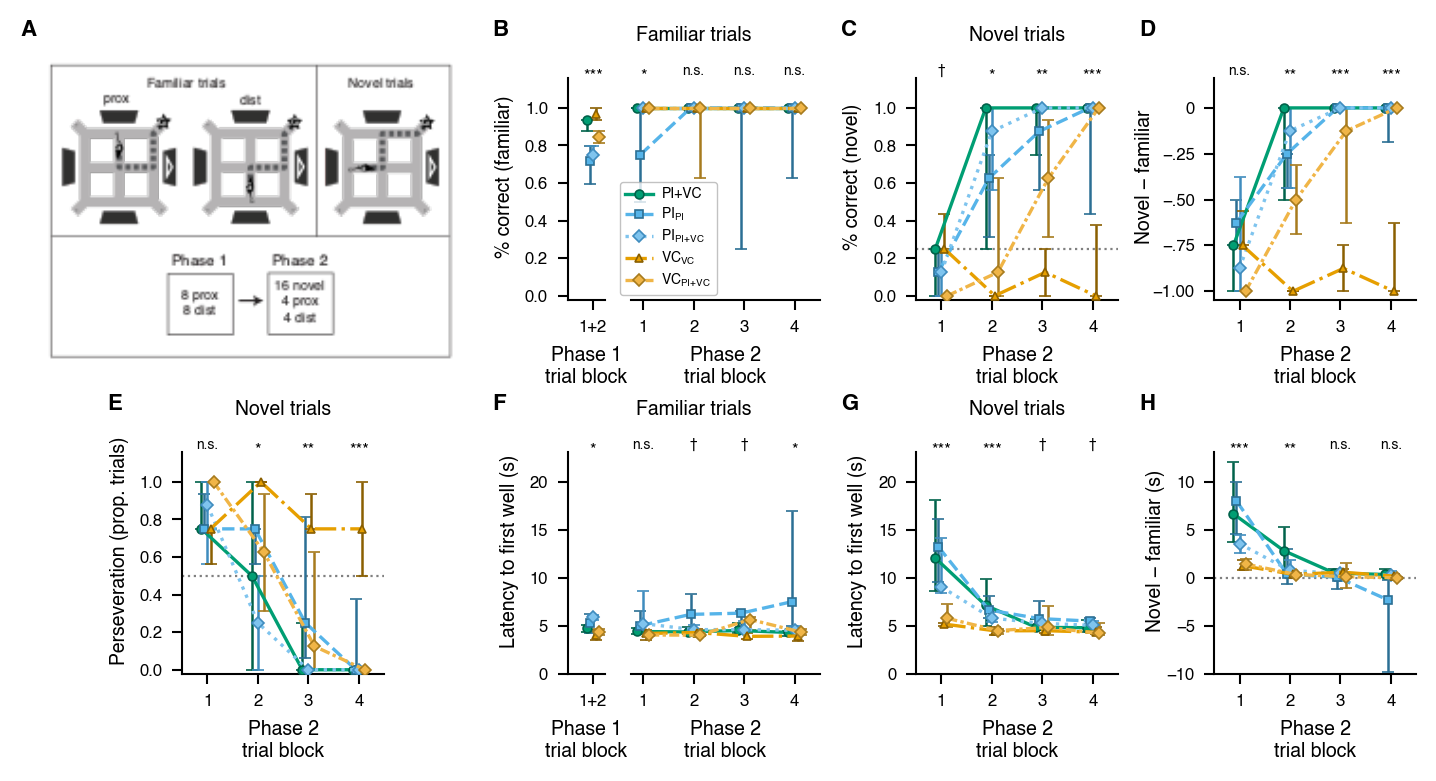

In [53]:
fig_med = compose_extended(VARIANT_MEDIAN)   # median [Q1, Q3] variant
plt.show()


In [54]:
export_composed_svg(fig_med, VARIANT_MEDIAN['stem'])


Saved SVG: figures/images/figure3_median.svg (1 schematic panel(s) spliced in as vector; 0 hatched shape(s) expanded to plain strokes)


PosixPath('figures/images/figure3_median.svg')